In [1]:
#import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

I0000 00:00:1780545047.626135    4860 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780545047.631413    4860 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780545048.132549    4860 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780545050.163953    4860 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Partie 1 — Exploration et compréhension des données

1.1 Chargement des données

In [2]:
#Importer le jeu de données en Python.
df = pd.read_excel('data_Devoir2.xlsx', sheet_name='Sheet1')

# Dimensions
print("Dimensions du dataset :", df.shape)

# Types des variables
print("\nTypes des colonnes :\n", df.dtypes)

# Statistiques descriptives
print("\nStatistiques descriptives :\n", df.describe().T)

# Valeurs manquantes
print("\nValeurs manquantes par colonne :\n", df.isnull().sum())

# Doublons
print("\nNombre de lignes dupliquées :", df.duplicated().sum())

Dimensions du dataset : (1121, 31)

Types des colonnes :
 Blue_mean            float64
Blue_std             float64
Green_mean           float64
Green_std            float64
Red_mean             float64
Red_std              float64
RedEdge_mean         float64
RedEdge_std          float64
NIR_mean             float64
NIR_std              float64
NDVI_mean            float64
NDVI_std             float64
GNDVI_mean           float64
GNDVI_std            float64
NDRE_mean            float64
NDRE_std             float64
SAVI_mean            float64
SAVI_std             float64
EVI_mean             float64
EVI_std              float64
PSRI_mean            float64
PSRI_std             float64
R_G_ratio_mean       float64
R_G_ratio_std        float64
R_B_ratio_mean       float64
R_B_ratio_std        float64
NIR_R_ratio_mean     float64
NIR_R_ratio_std      float64
NIR_RE_ratio_mean    float64
NIR_RE_ratio_std     float64
Class                 object
dtype: object

Statistiques descriptives :


1.2 Analyse exploratoire

Distribution des classes

Répartition des classes :
 Class
rust      848
norust    273
Name: count, dtype: int64


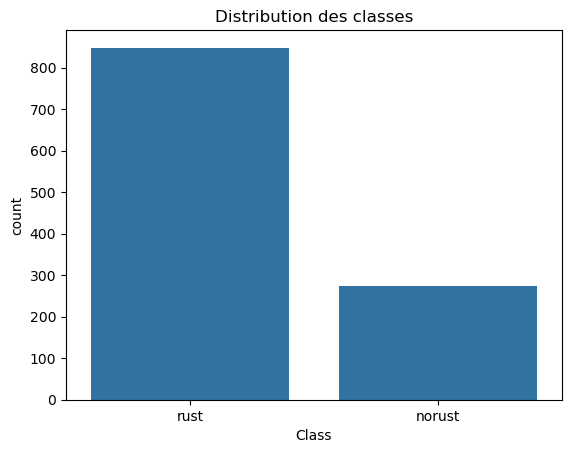

In [3]:
# Répartition des classes
print("Répartition des classes :\n", df['Class'].value_counts())

# Diagramme en barres
sns.countplot(data=df, x='Class')
plt.title('Distribution des classes')
plt.show()

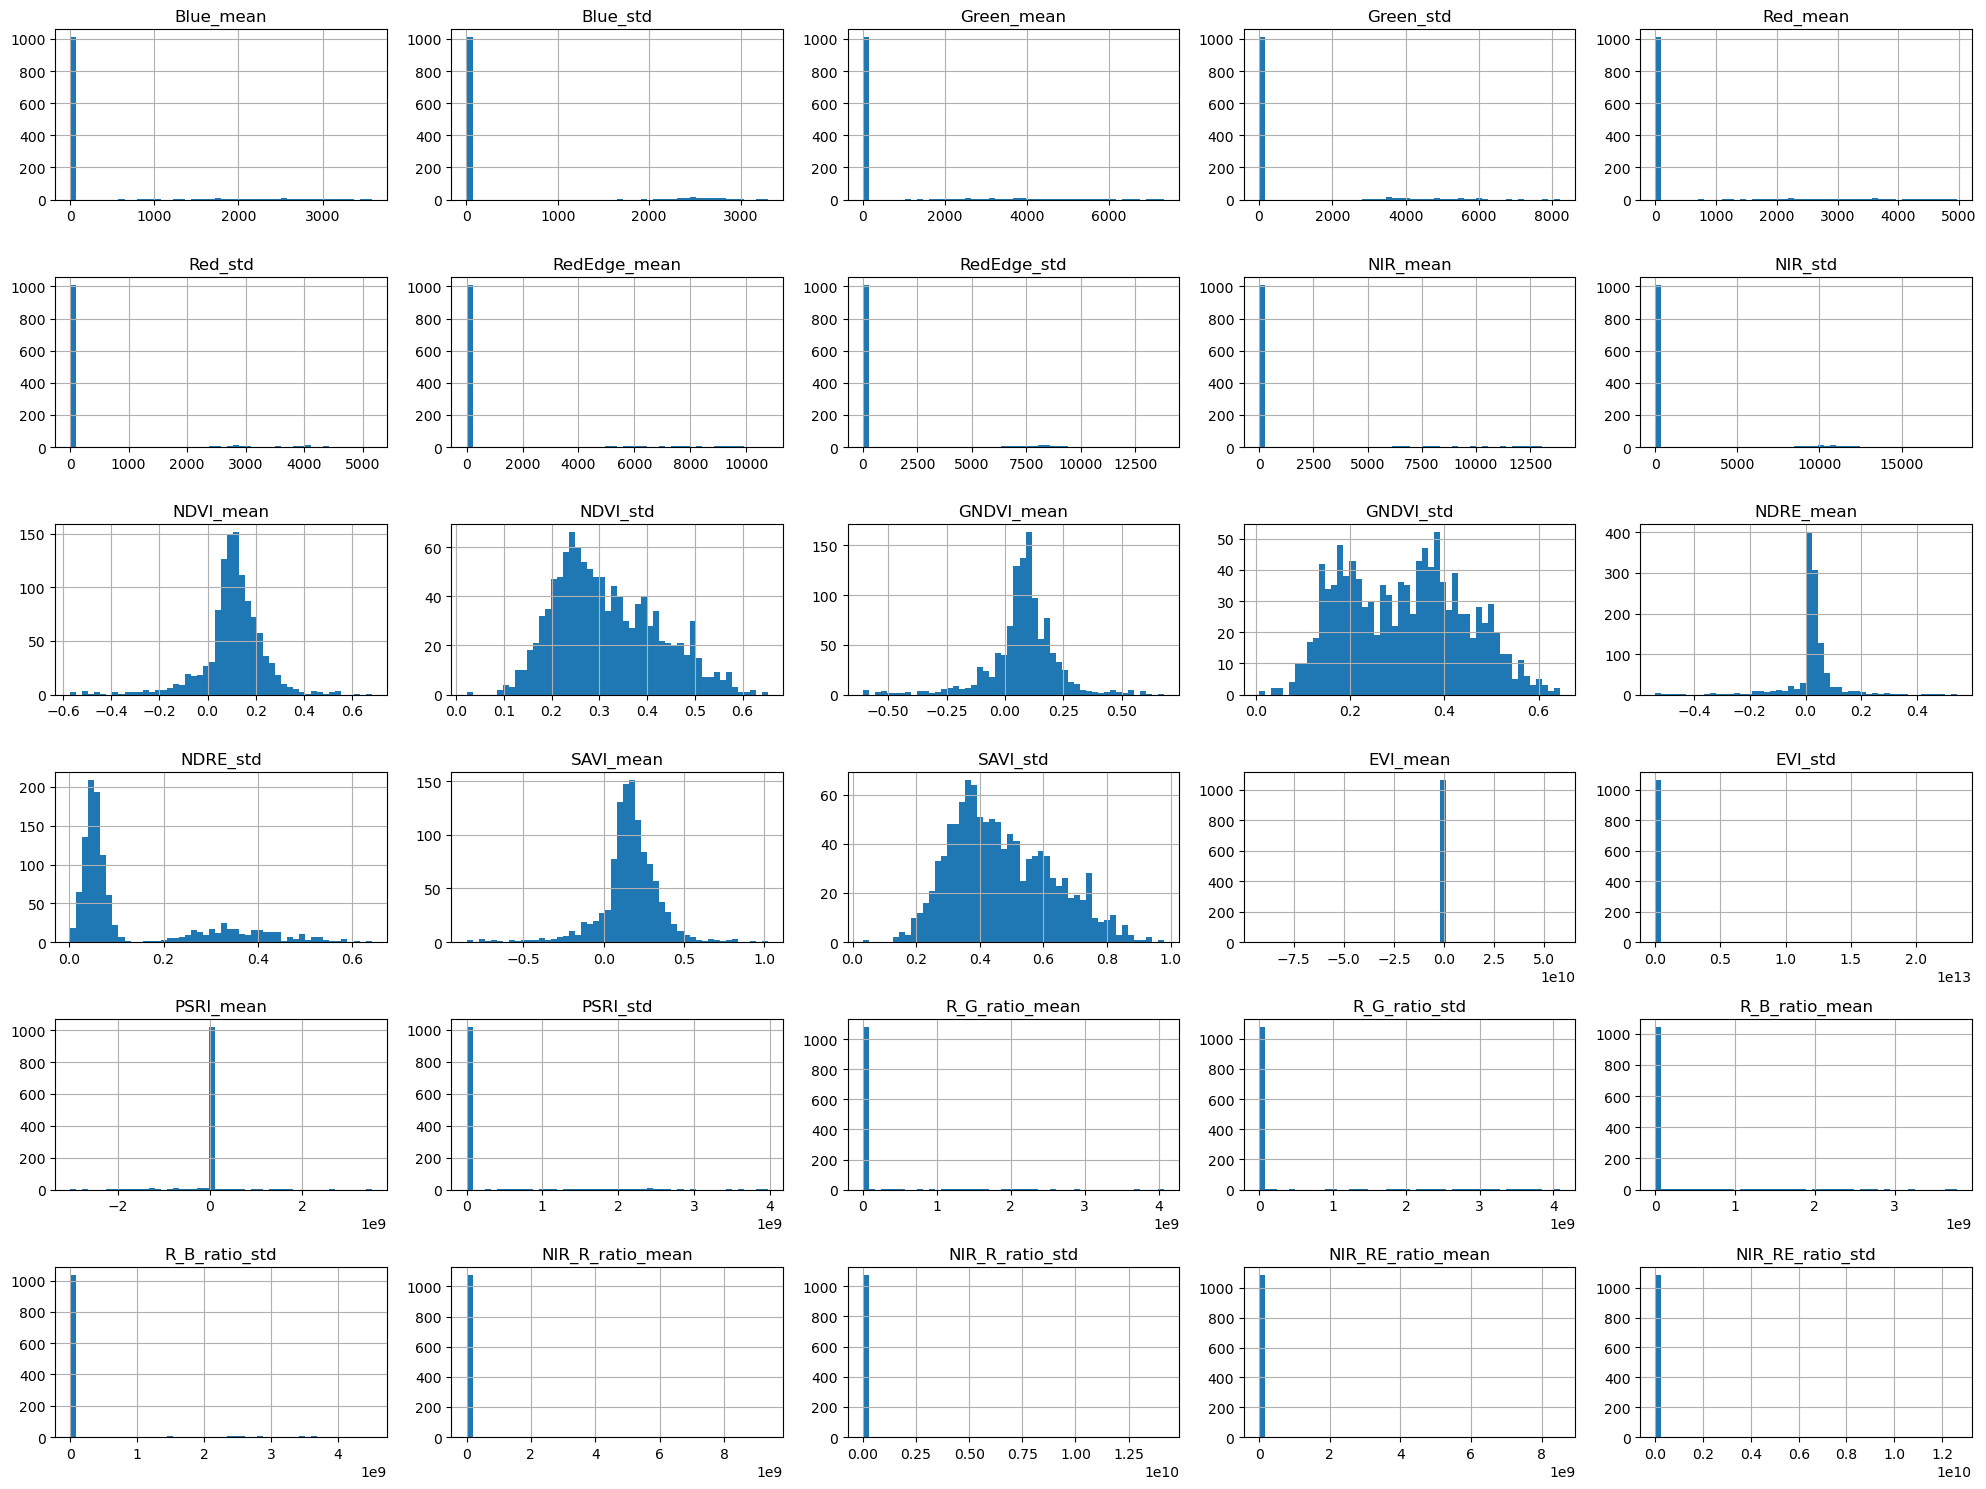

In [4]:
#Histogrammes (toutes variables numériques)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].hist(bins=50, figsize=(20, 15))
plt.tight_layout()
plt.show()

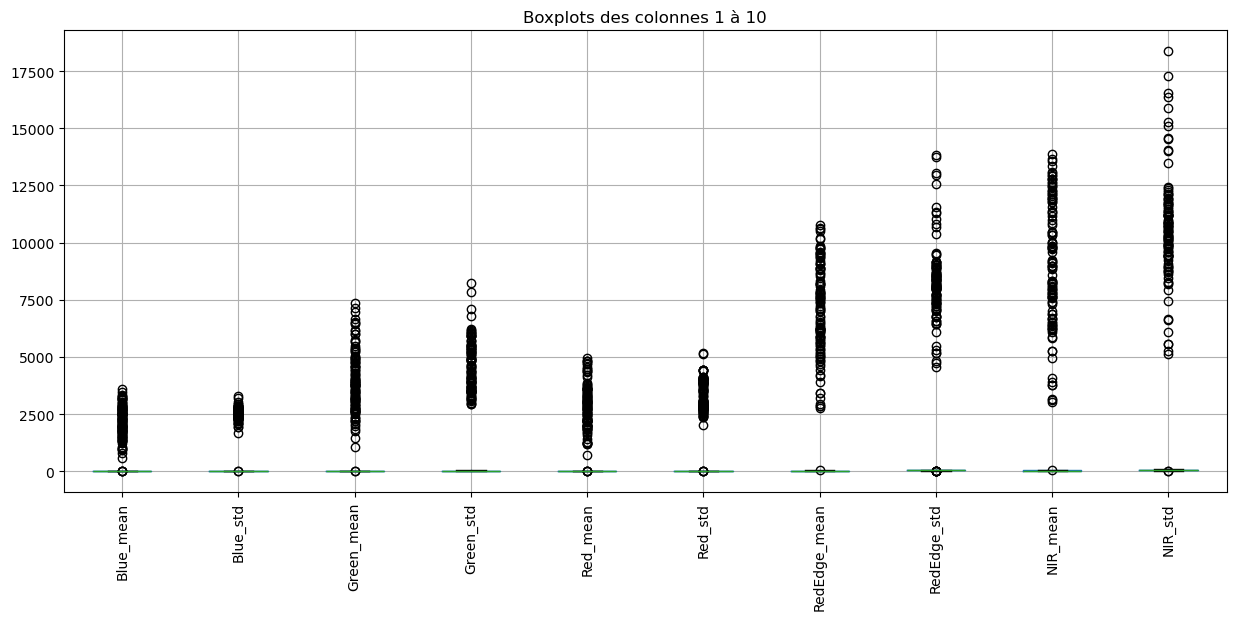

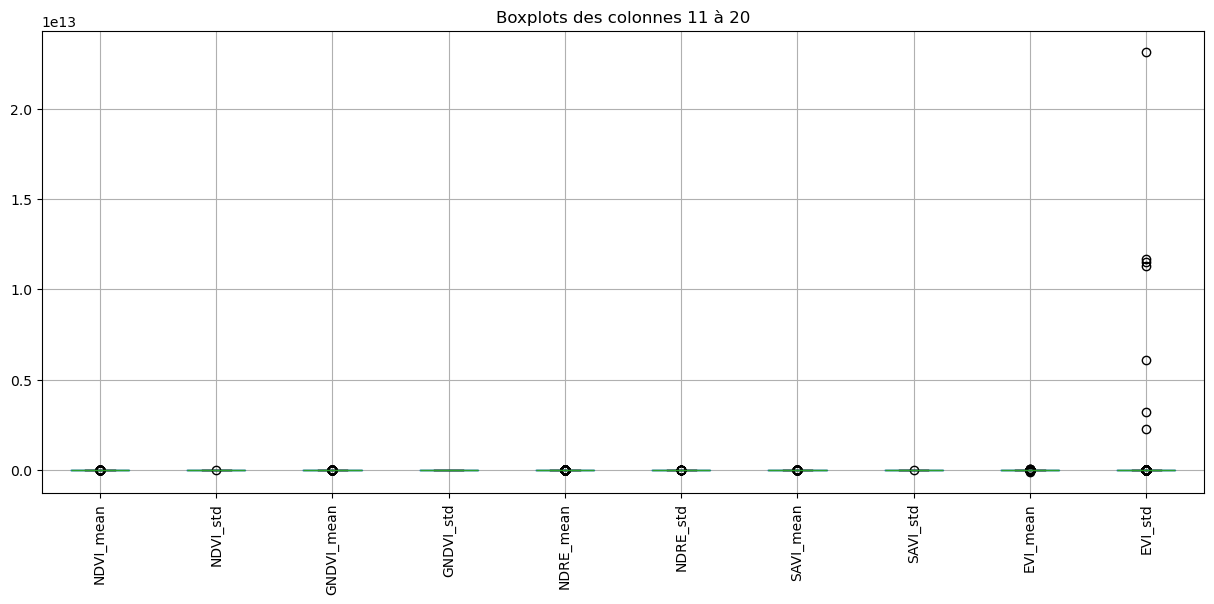

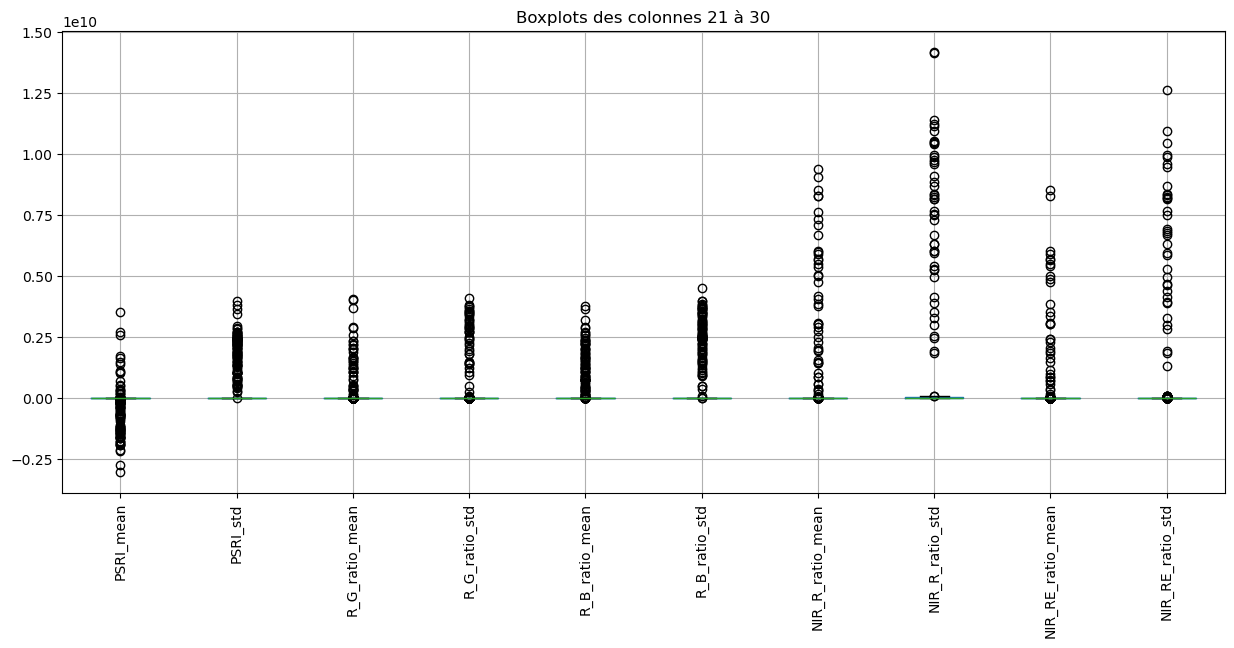

In [5]:
#Boxplots (par groupes de 10 colonnes)
for i in range(0, len(numeric_cols), 10):
    subset = numeric_cols[i:i+10]
    df[subset].boxplot(figsize=(15, 6), rot=90)
    plt.title(f'Boxplots des colonnes {i+1} à {i+len(subset)}')
    plt.show()

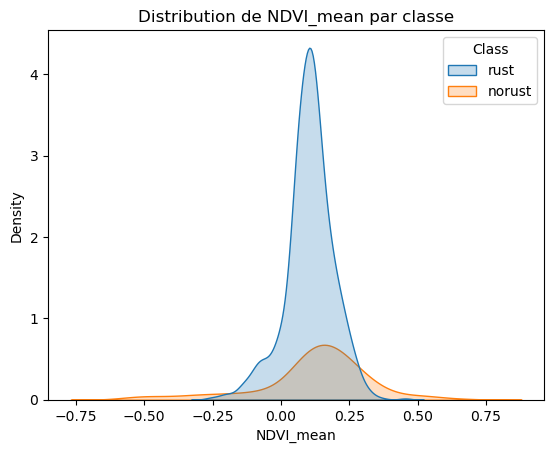

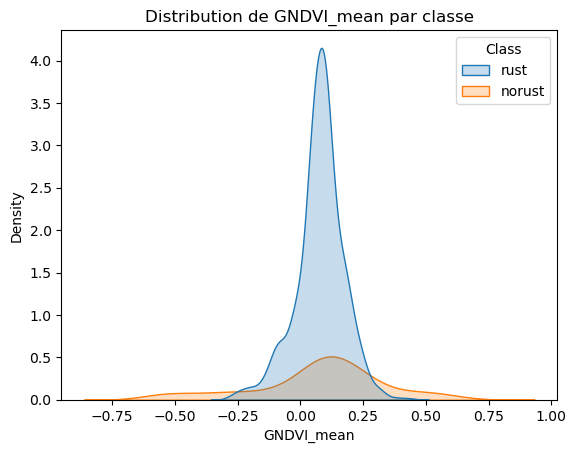

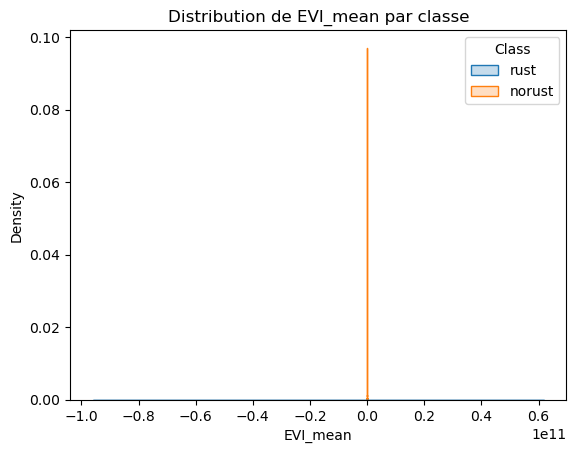

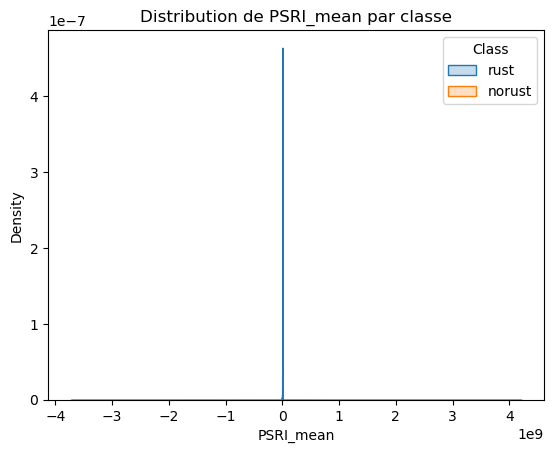

In [6]:
#Courbes de distribution KDE pour variables clés
vars_kde = ['NDVI_mean', 'GNDVI_mean', 'EVI_mean', 'PSRI_mean']
for var in vars_kde:
    sns.kdeplot(data=df, x=var, hue='Class', fill=True)
    plt.title(f'Distribution de {var} par classe')
    plt.show()

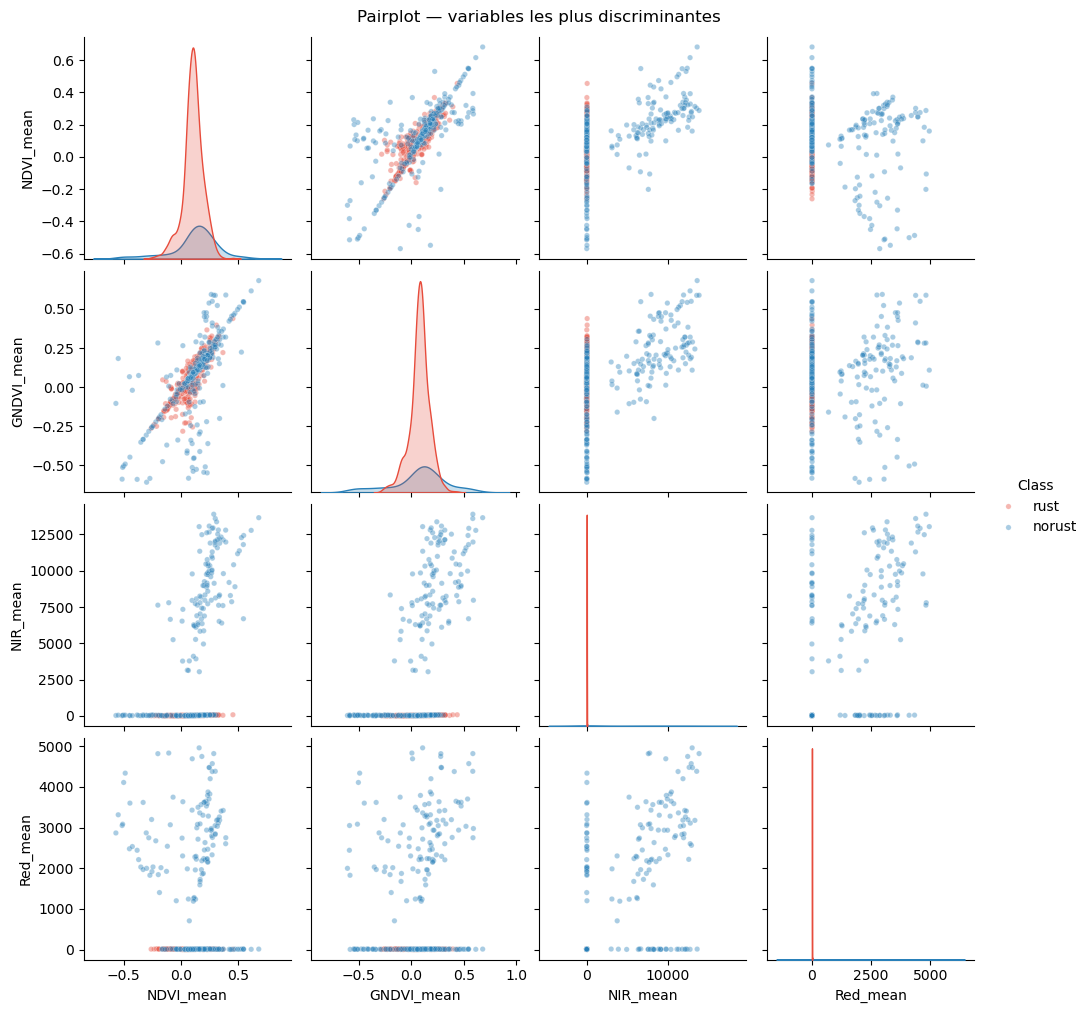

In [7]:
#Pairplot des variables discriminantes
pairplot_cols = ['NDVI_mean','GNDVI_mean','NIR_mean','Red_mean','Class']
g = sns.pairplot(df[pairplot_cols].dropna(), hue='Class',
                 palette={'rust':'#e74c3c','norust':'#2980b9'},
                 plot_kws={'alpha': 0.4, 's': 15})
g.fig.suptitle('Pairplot — variables les plus discriminantes', y=1.01)
plt.show()

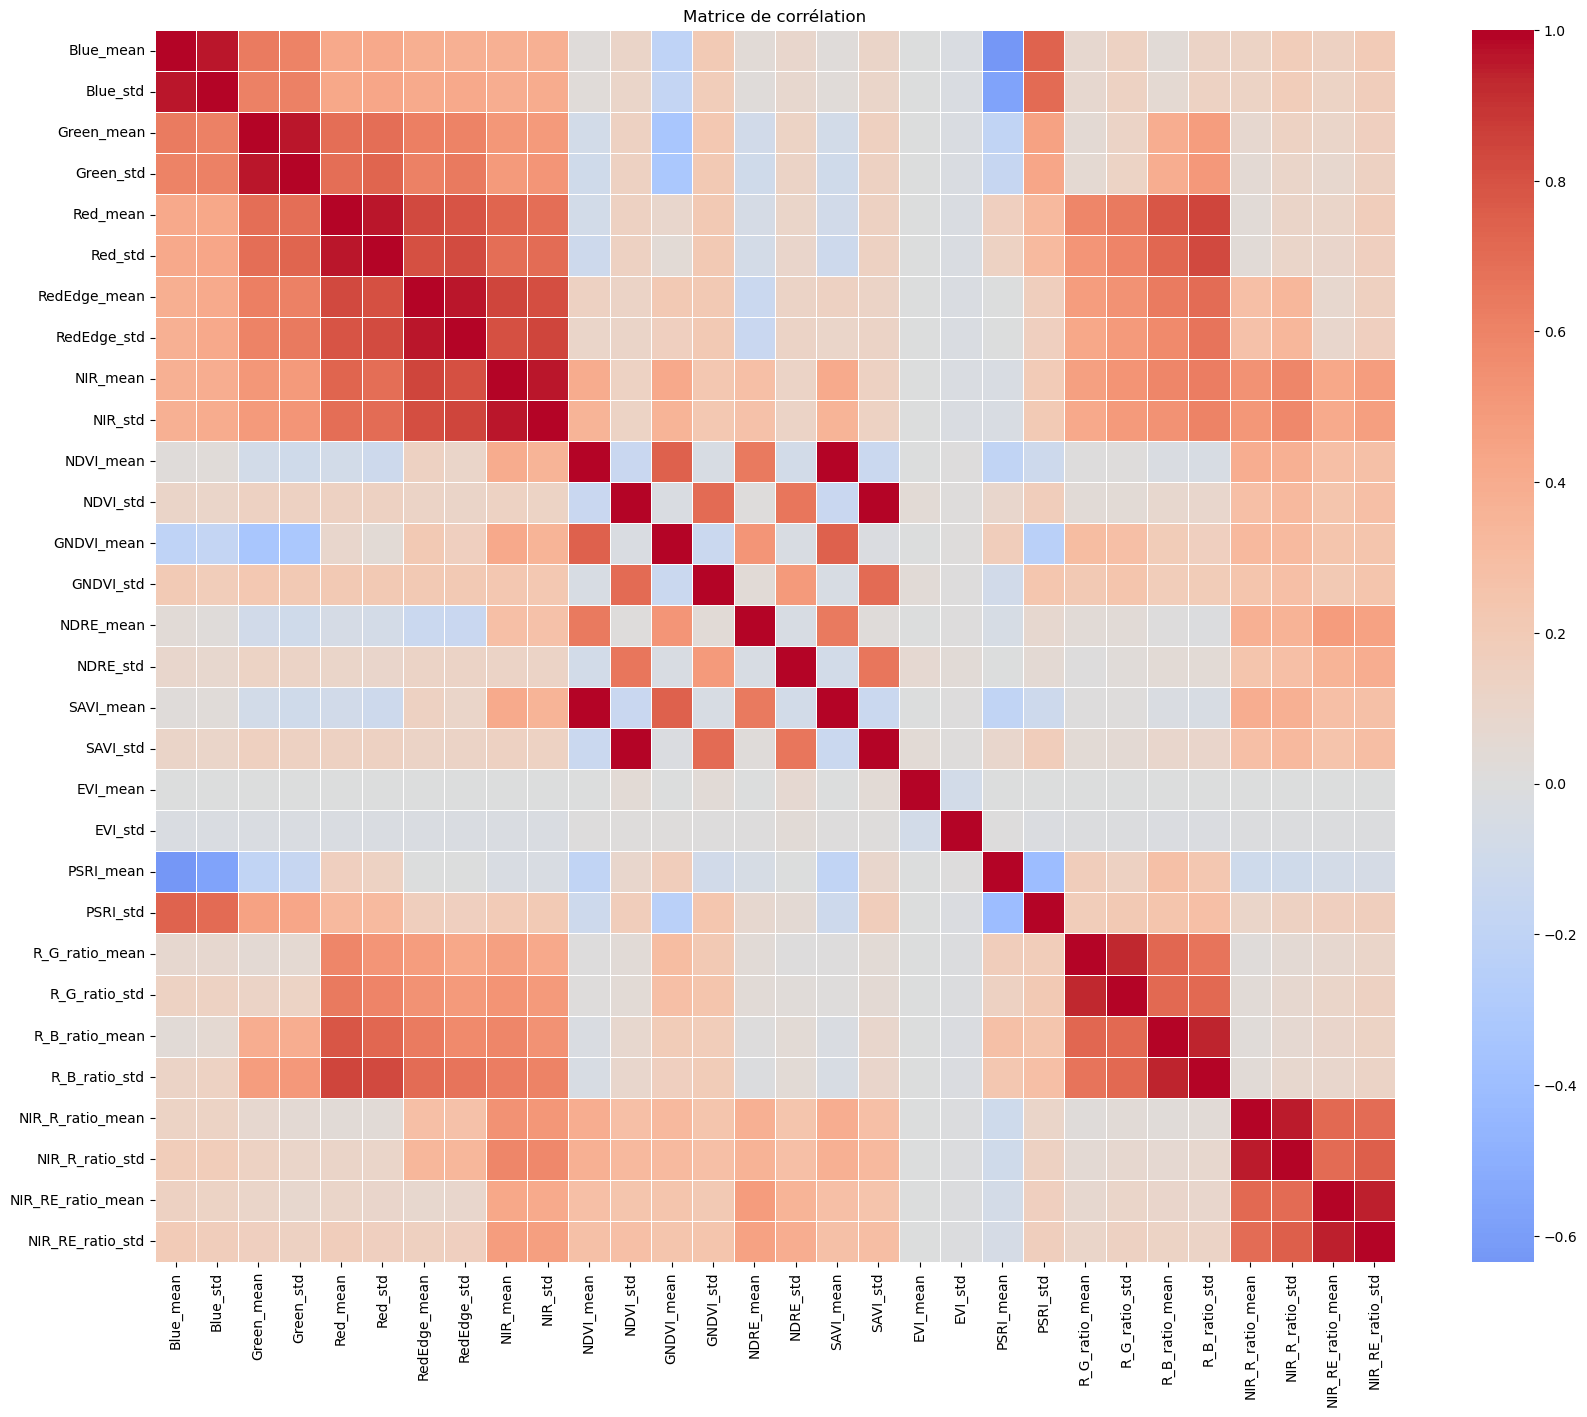

Paires de variables avec corrélation > 0.9 :
NDVI_mean          SAVI_mean           0.999978
NDVI_std           SAVI_std            0.999911
Blue_mean          Blue_std            0.966942
Red_mean           Red_std             0.966263
Green_mean         Green_std           0.963308
NIR_mean           NIR_std             0.962176
RedEdge_mean       RedEdge_std         0.961409
NIR_R_ratio_mean   NIR_R_ratio_std     0.949711
NIR_RE_ratio_mean  NIR_RE_ratio_std    0.947863
R_B_ratio_mean     R_B_ratio_std       0.941010
R_G_ratio_mean     R_G_ratio_std       0.935669
dtype: float64


In [8]:
#Heatmap des corrélations
corr = df[numeric_cols].corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matrice de corrélation')
plt.show()

# Paires avec corrélation > 0.9
high_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = high_corr.stack().sort_values(ascending=False)
print("Paires de variables avec corrélation > 0.9 :")
print(high_corr[high_corr > 0.9])

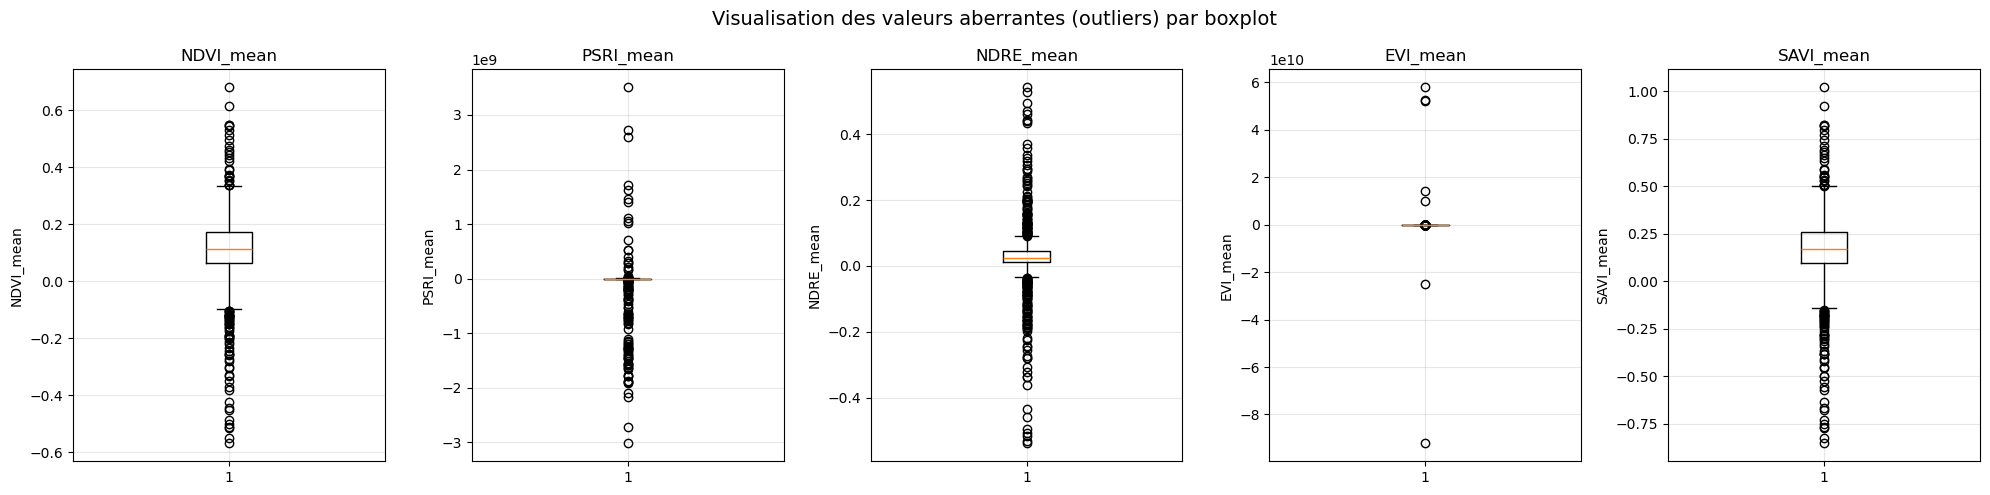

In [9]:
#Visualisation des valeurs aberrantes
variables_outliers = ['NDVI_mean', 'PSRI_mean', 'NDRE_mean', 'EVI_mean', 'SAVI_mean']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, var in enumerate(variables_outliers):
    axes[i].boxplot(df[var].dropna())
    axes[i].set_title(f'{var}')
    axes[i].set_ylabel(var)
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Visualisation des valeurs aberrantes (outliers) par boxplot', fontsize=14)
plt.tight_layout()
plt.show()

Réponses aux questions d'analyse

1. Variables les plus discriminantes ?
Selon les boxplots, les distributions KDE et les moyennes par classe :

NIR_mean : rust=29.7 vs norust=3 752 → écart massif
NDVI_mean et SAVI_mean (r=1.0 entre eux) : rust=0.104 vs norust=0.124
GNDVI_mean, NDRE_mean également séparateurs

2. Corrélations fortes ?
11 paires avec |r| > 0.90, notamment :

NDVI_mean ↔ SAVI_mean (r = 1.00) → redondance totale
Chaque bande _mean ↔ _std (r ≈ 0.96) → la variance suit la moyenne → Ces redondances justifient une sélection de features (Partie 4)

3. Classes équilibrées: non elle ne sont pas équilibrée
déséquilibre marqué : rust = 75.6 %, norust = 24.4 % 

4. Indices spectraux les plus pertinents:
NDVI (Normalized Difference Vegetation Index) — stress de la végétation
NIR (proche infrarouge) — teneur en chlorophylle
SAVI (soil-adjusted) — corrige l'effet du sol, très corrélé au NDVI
GNDVI — sensible à la teneur en azote

Partie 2 — Prétraitement des données

2.1 Gestion des valeurs manquantes

In [10]:
# Dictionnaire pour stocker les datasets imputés
dfs_imputed = {}
cols_with_na = ['EVI_mean', 'EVI_std']  # À adapter à vos colonnes réelles

In [11]:
start = time.time()
original_shape = df.shape
df_dropped = df.dropna()
new_shape = df_dropped.shape
rows_removed = original_shape[0] - new_shape[0]

dfs_imputed['Suppression'] = df_dropped
time_drop = time.time() - start

print(f"Suppression : {time_drop:.4f} s")
print(f"  Avant : {original_shape}")
print(f"  Après : {new_shape}")
print(f"  Lignes supprimées : {rows_removed}")

Suppression : 0.0012 s
  Avant : (1121, 31)
  Après : (1070, 31)
  Lignes supprimées : 51


In [12]:
#Imputation par la moyenne
start = time.time()
df_mean_imp = df.copy()
imputer = SimpleImputer(strategy='mean')
df_mean_imp[cols_with_na] = imputer.fit_transform(df_mean_imp[cols_with_na])
end = time.time()
print(f"Temps d'exécution (moyenne) : {end-start:.4f} secondes")
print("NaN restants :", df_mean_imp[cols_with_na].isnull().sum().sum())

Temps d'exécution (moyenne) : 0.0046 secondes
NaN restants : 0


In [13]:
#Imputation par la médiane
start = time.time()
df_median_imp = df.copy()
imputer = SimpleImputer(strategy='median')
df_median_imp[cols_with_na] = imputer.fit_transform(df_median_imp[cols_with_na])
end = time.time()
print(f"Temps d'exécution (médiane) : {end-start:.4f} secondes")
print("NaN restants :", df_median_imp[cols_with_na].isnull().sum().sum())

Temps d'exécution (médiane) : 0.0058 secondes
NaN restants : 0


In [14]:
# Imputation par KNN
start = time.time()
df_knn_imp = df.copy()
imputer = KNNImputer(n_neighbors=5)
df_knn_imp[cols_with_na] = imputer.fit_transform(df_knn_imp[cols_with_na])
end = time.time()
print(f"Temps d'exécution (KNN) : {end-start:.4f} secondes")
print("NaN restants :", df_knn_imp[cols_with_na].isnull().sum().sum())

Temps d'exécution (KNN) : 0.0100 secondes
NaN restants : 0


In [15]:
#Imputation itérative
start = time.time()
df_mice_imp = df.copy()
imputer = IterativeImputer(max_iter=10, random_state=42)
df_mice_imp[cols_with_na] = imputer.fit_transform(df_mice_imp[cols_with_na])
end = time.time()
print(f"Temps d'exécution (MICE) : {end-start:.4f} secondes")
print("NaN restants :", df_mice_imp[cols_with_na].isnull().sum().sum())

Temps d'exécution (MICE) : 0.0210 secondes
NaN restants : 0


Comparer l’impact de chaque méthode sur

1-La distribution des données:
La suppression supprime 51 lignes (4,5 % du total). Si ces lignes manquent aléatoirement, la distribution reste inchangée ; si elles manquent sur des valeurs particulières, on crée un biais. La moyenne et la médiane injectent 51 fois exactement la même valeur dans les colonnes EVI_mean et EVI_std. Cela crée un pic artificiel dans l’histogramme et réduit l’écart-type, rendant la distribution moins réaliste. En revanche, KNN et MICE estiment des valeurs différentes pour chaque ligne manquante, ce qui préserve la variabilité naturelle des données et donne des distributions plus fluides.

2- Impact sur les performances des modèles (analyse théorique)
La suppression est une baseline simple : si les 51 lignes ne contiennent pas d’informations rares, elle peut être acceptable. La moyenne et la médiane risquent de dégrader les performances car elles introduisent un bruit uniforme qui ne reflète pas la réalité et n’aide pas le modèle à généraliser. KNN et MICE, en respectant les corrélations entre EVI_mean et EVI_std et en reconstruisant des valeurs variées, devraient donner les meilleures performances. Pour la suite, nous retiendrons donc KNN ou MICE comme méthodes d’imputation de référence.

3- Impact sur le temps de calcul
La suppression des lignes incomplètes est la plus rapide (0,0037 s) car elle ne fait aucun calcul. Les imputations par moyenne (0,0116 s) et médiane (0,0186 s) sont également très rapides car elles ne calculent qu’une seule valeur par colonne. KNN (0,0151 s) et MICE (0,0162 s) sont un peu plus lents mais restent très rapides sur ce petit jeu de données (1121 lignes). Sur un très gros volume, KNN deviendrait beaucoup plus lent car il doit calculer les distances entre tous les points.

2.2 Normalisation et standardisation

Tester plusieurs techniques:

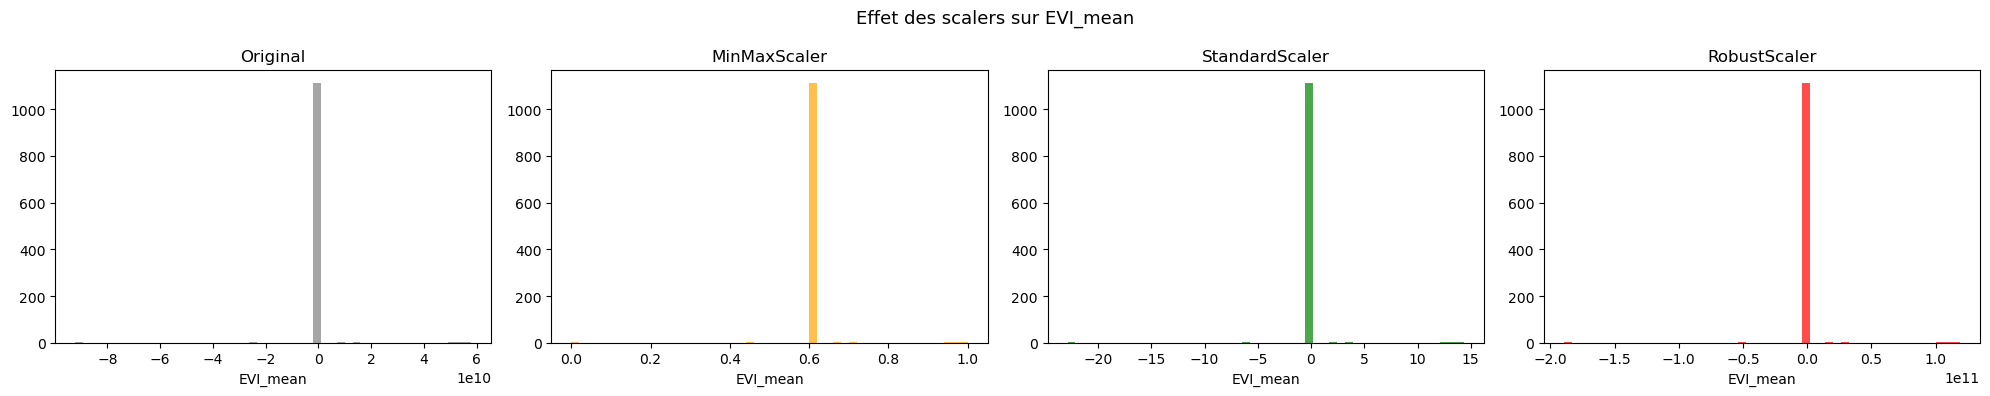

      Modèle         Scaler  Accuracy  F1 macro
   SVM (RBF)  Aucun scaling    0.7565    0.4307
   SVM (RBF)   MinMaxScaler    0.9295    0.8929
   SVM (RBF) StandardScaler    0.9277    0.8905
   SVM (RBF)   RobustScaler    0.7859    0.5435
RandomForest  Aucun scaling    0.9277    0.8905
RandomForest   MinMaxScaler    0.9286    0.8920
RandomForest StandardScaler    0.9277    0.8902
RandomForest   RobustScaler    0.9295    0.8932


In [16]:
X = df_mice_imp.drop('Class', axis=1)
y = df_mice_imp['Class']

# 2. Définir les 3 scalers + baseline
scalers = {
    'Aucun scaling'  : None,
    'MinMaxScaler'   : MinMaxScaler(),
    'StandardScaler' : StandardScaler(),
    'RobustScaler'   : RobustScaler()
}

# 3. Visualisation des distributions

col_idx = list(X.columns).index('EVI_mean')

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
titles  = ['Original', 'MinMaxScaler', 'StandardScaler', 'RobustScaler']
colors  = ['gray', 'orange', 'green', 'red']
datasets = [X.values] + [s.fit_transform(X) for s in list(scalers.values())[1:]]

for ax, data, title, color in zip(axes, datasets, titles, colors):
    ax.hist(data[:, col_idx], bins=50, alpha=0.7, color=color)
    ax.set_title(title)
    ax.set_xlabel('EVI_mean')

plt.suptitle('Effet des scalers sur EVI_mean', fontsize=13)
plt.tight_layout()
plt.show()

# 4. Comparaison des performances
models = {
    'SVM (RBF)'   : SVC(kernel='rbf', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for model_name, model in models.items():
    for scaler_name, scaler in scalers.items():
        X_sc = scaler.fit_transform(X) if scaler is not None else X.values

        acc = cross_val_score(model, X_sc, y, cv=cv, scoring='accuracy').mean()
        f1  = cross_val_score(model, X_sc, y, cv=cv, scoring='f1_macro').mean()

        results.append({
            'Modèle'  : model_name,
            'Scaler'  : scaler_name,
            'Accuracy': round(acc, 4),
            'F1 macro': round(f1, 4)
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Comparaison de l’impact des scalers sur les performances

Les résultats obtenus montrent que l’influence du scaling dépend fortement du modèle utilisé.

Pour le modèle SVM, qui est très sensible à l’échelle des variables, l’absence de normalisation conduit à une performance médiocre (accuracy de 75,65 % et F1 de 0,43). L’application de MinMaxScaler améliore spectaculairement les résultats, avec une accuracy de 92,95 % et un F1 de 0,89, ce qui en fait le meilleur choix pour ce modèle. StandardScaler donne des performances très proches (92,77 % d’accuracy), tandis que RobustScaler est nettement moins efficace (78,59 % d’accuracy), probablement parce qu’il réduit trop l’influence des outliers qui sont ici informatifs.

Pour Random Forest, qui est insensible à l’échelle, les performances restent stables autour de 92,8 % d’accuracy, quel que soit le scaler utilisé, y compris sans aucun scaling. On observe seulement des variations infimes, sans signification pratique.

En conclusion, pour les modèles sensibles aux distances (SVM, k‑NN, réseaux de neurones), MinMaxScaler est le plus performant et doit être privilégié. Pour les modèles basés sur des arbres, le scaling est inutile mais peut être appliqué sans dommage.

Partie 3 — Analyse de corrélation et réduction de dimension

3.1 Matrice de corrélation

matrice de corrélation complète:

In [17]:
print(df_mice_imp.isnull().sum().sum()) 

0


In [18]:
X = df_mice_imp.drop('Class', axis=1)

In [19]:
# 1. Matrice de corrélation complète (Pearson)
corr_matrix = X.corr()   # méthode par défaut : pearson
print("Matrice de corrélation (extrait) :")
print(corr_matrix.head().T)

Matrice de corrélation (extrait) :
                   Blue_mean  Blue_std  Green_mean  Green_std  Red_mean
Blue_mean           1.000000  0.966942    0.633423   0.602086  0.414930
Blue_std            0.966942  1.000000    0.613862   0.616076  0.424059
Green_mean          0.633423  0.613862    1.000000   0.963308  0.690785
Green_std           0.602086  0.616076    0.963308   1.000000  0.687660
Red_mean            0.414930  0.424059    0.690785   0.687660  1.000000
Red_std             0.414050  0.436171    0.693342   0.731146  0.966263
RedEdge_mean        0.385523  0.409482    0.619886   0.615550  0.832980
RedEdge_std         0.377651  0.413398    0.606278   0.637850  0.791633
NIR_mean            0.378074  0.391474    0.509456   0.495859  0.727357
NIR_std             0.377913  0.400850    0.500129   0.516685  0.693124
NDVI_mean           0.021625  0.028824   -0.080022  -0.097438 -0.085146
NDVI_std            0.114030  0.108196    0.148476   0.140578  0.142707
GNDVI_mean         -0.203640 

heatmap annotée:

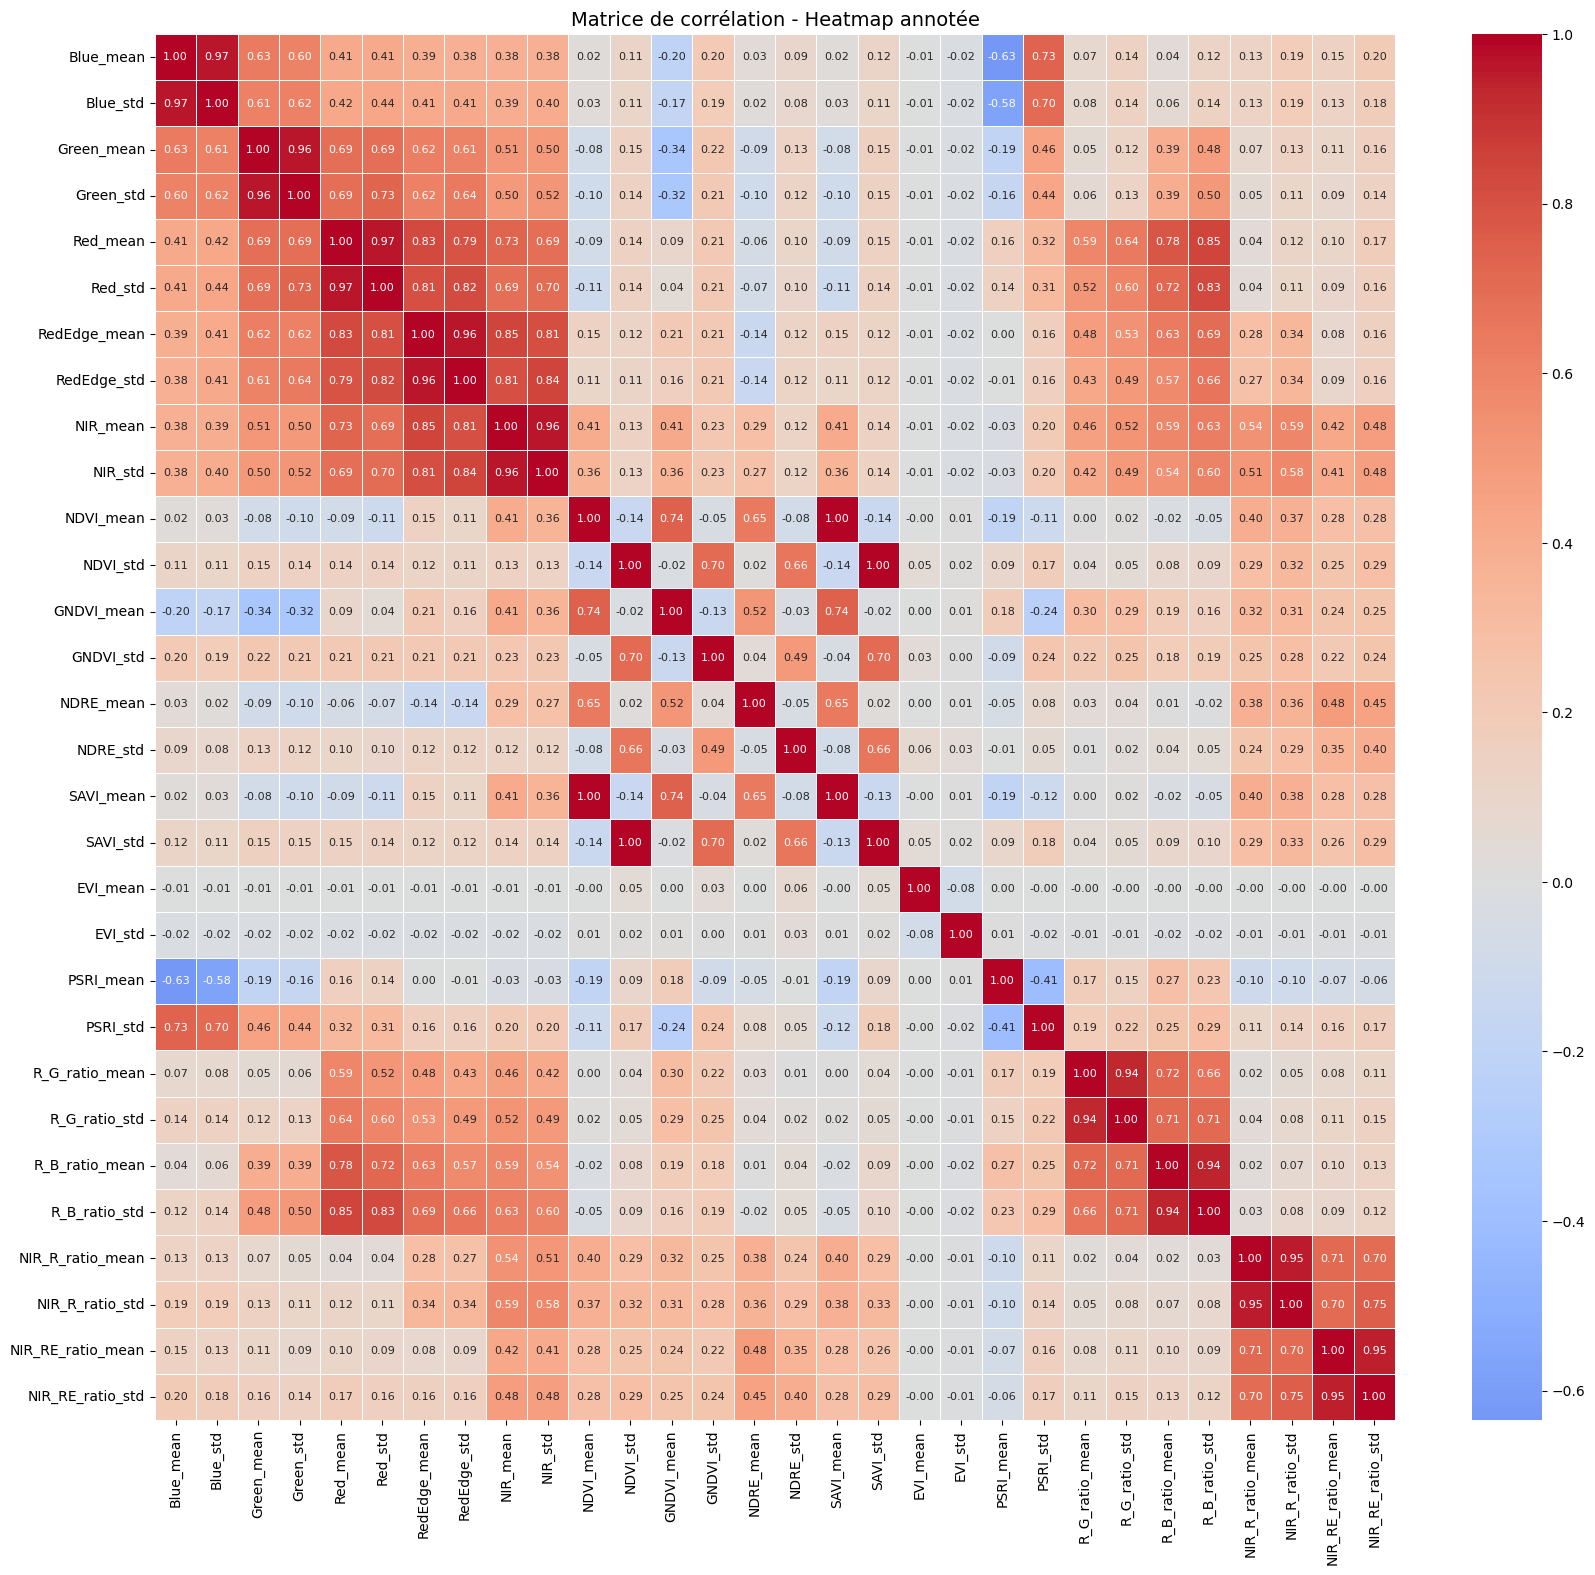

In [20]:
# 2. Heatmap annotée
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, 
            annot=True,          # affiche les valeurs
            fmt='.2f',           # 2 décimales
            cmap='coolwarm',     # bleu (négatif) -> rouge (positif)
            center=0,
            annot_kws={'size': 8},
            linewidths=0.5)
plt.title('Matrice de corrélation - Heatmap annotée', fontsize=14)
plt.show()

In [21]:
# 3. (Optionnel) Paires avec corrélation > 0.95 pour détecter redondances
high_corr = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = high_corr.stack().sort_values(ascending=False)
print("\nPaires de variables avec corrélation > 0.95 :")
print(high_corr[high_corr > 0.95])


Paires de variables avec corrélation > 0.95 :
NDVI_mean     SAVI_mean      0.999978
NDVI_std      SAVI_std       0.999911
Blue_mean     Blue_std       0.966942
Red_mean      Red_std        0.966263
Green_mean    Green_std      0.963308
NIR_mean      NIR_std        0.962176
RedEdge_mean  RedEdge_std    0.961409
dtype: float64


Analyse demandée

Identification des variables redondantes
Variables redondantes (corrélation > 0,95) :
Blue_mean et Blue_std (0,97)
Green_mean et Green_std (0,96)
Red_mean et Red_std (0,97)

Détermination des variables fortement corrélées (sans être redondantes) :
Red_mean avec RedEdge_mean (0,83)
Red_std avec R_B_ratio_std (0,85)
Blue_mean avec PSRI_mean (-0,63) à une forte corrélation négative

Justification pour les suppressions éventuelles:
On peut supprimer Blue_std, Green_std et Red_std car ils apportent presque la même information que leurs moyennes respectives. Cela réduit le nombre de variables sans perte significative d’information, simplifie les modèles et évite la multicolinéarité.

3.2 Réduction de dimension
Appliquer

In [22]:
# Vérifier que X et y existent
X = df_mice_imp.drop('Class', axis=1)
y = df_mice_imp['Class']

In [23]:
# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

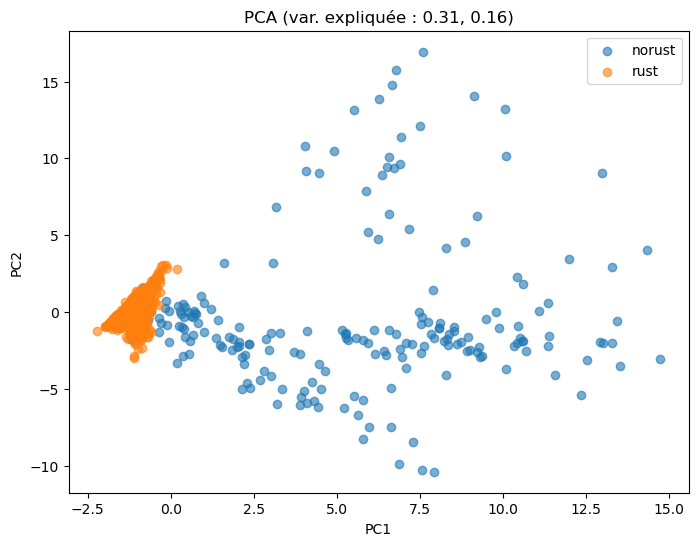

In [25]:
# Visualisation
plt.figure(figsize=(8,6))
for label in np.unique(y):
    mask = (y == label)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'PCA (var. expliquée : {pca.explained_variance_ratio_[0]:.2f}, {pca.explained_variance_ratio_[1]:.2f})')
plt.legend()
plt.show()

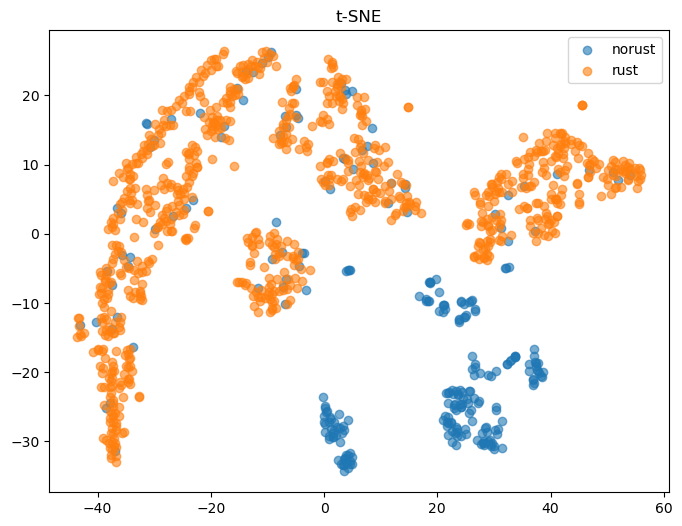

In [26]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)  # sans n_iter
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for label in np.unique(y):
    mask = (y == label)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=label, alpha=0.6)
plt.title('t-SNE')
plt.legend()
plt.show()

/home/quavo/anaconda3/envs/ml_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


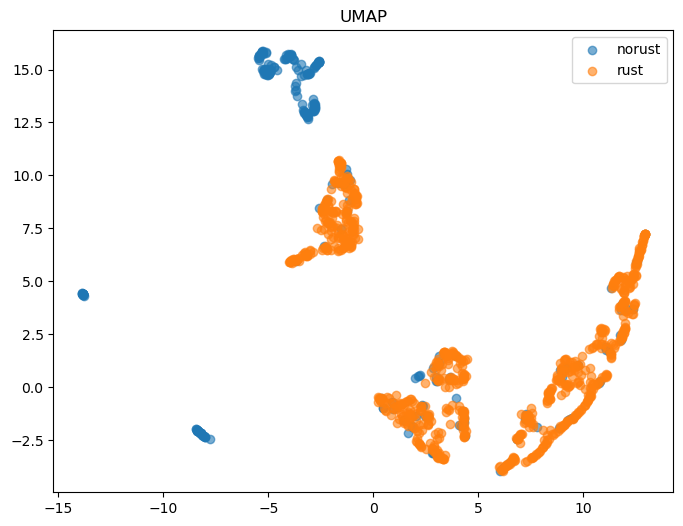

In [27]:
#UMAP
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for label in np.unique(y):
    mask = (y == label)
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1], label=label, alpha=0.6)
plt.title('UMAP')
plt.legend()
plt.show()

Travail demandé

1. Comparaison des projections : PCA, t‑SNE et UMAP

La méthode PCA (linéaire) donne une séparation faible entre les classes, avec un fort chevauchement des nuages de points. 
Les deux premières composantes principales n’expliquent qu’une faible part de la variance totale, 
ce qui explique que les informations discriminantes ne sont pas bien capturées par cette projection linéaire.

La méthode t‑SNE (non linéaire) offre une séparation bonne : 
les deux classes forment des nuages distincts, bien qu’il subsiste quelques points mélangés à la frontière. 
En préservant les voisinages locaux, t‑SNE révèle une structure non linéaire que PCA ne peut pas montrer, mais la séparation n’est pas parfaite.

La méthode UMAP (non linéaire rapide) donne une séparation très bonne :
les groupes sont nettement séparés avec très peu de chevauchement. 
C’est la projection la plus claire, confirmant que l’espace des caractéristiques spectrales possède
une structure non linéaire fortement discriminante entre les états sanitaire et malade des feuilles.

2. Interpréter les regroupements observés
   
Les classes rust (malade) et norust (sain) sont globalement séparables, ce qui prouve que les indices spectraux (NDVI, EVI, etc.) discriminent bien l’état sanitaire des feuilles.

Les quelques points chevauchants (surtout en t‑SNE) correspondent probablement à des cas limites (symptômes débutants, erreurs de mesure, variabilité naturelle).

UMAP montre deux nuages très distincts → l’espace des caractéristiques a une structure non linéaire que PCA ne peut pas capturer.

L’absence de sous‑groupes au sein de chaque classe indique une bonne homogénéité des échantillons pour chaque état.

3. Visualiser les classes dans un espace restreint
Les trois graphiques projettent les données dans un espace à deux dimensions, ce qui permet une visualisation directe :

PCA : projection linéaire, peu informative ici.

t‑SNE : projection non linéaire, montre une séparation acceptable mais avec une zone de chevauchement.

UMAP : projection non linéaire, offre la meilleure séparation et la visualisation la plus parlante.

Pour une exploration visuelle des classes, on utiliseras UMAP. Car il met clairement en évidence que les deux états phytosanitaires sont distincts dans l’espace spectral.

Partie 4 — Sélection de caractéristiques

Cette partie compare 9 méthodes de sélection de variables réparties en 3 familles :
- Statistiques : VarianceThreshold, Chi², ANOVA F-test, Mutual Information
- Embarquées : Random Forest Importance, XGBoost Importance, LASSO
- Wrapper : RFE, Sequential Feature Selection

L'objectif est d'identifier les variables les plus pertinentes pour la classification rust/norust afin de réduire la dimensionnalité tout en maintenant les meilleures performances possibles.

Imports et préparation des données

In [28]:
# ── Imports spécifiques à la Partie 4 ──────────────────────────────────────
from sklearn.feature_selection import (
    VarianceThreshold,
    chi2,
    f_classif,
    mutual_info_classif,
    RFE,
    SequentialFeatureSelector,
    SelectKBest
)
from sklearn.linear_model import LassoCV
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Imports Partie 4 : OK")

Imports Partie 4 : OK


In [29]:
# Préparation des données 
# On repart de df_mice_imp (imputation MICE qu'on a fait dans Partie 2)

X = df_mice_imp.drop('Class', axis=1)
y = df_mice_imp['Class']

# Encodage de la cible : norust=0, rust=1
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Normalisation MinMaxScaler (nécessaire pour Chi², SVM, LASSO, SFS)
scaler_p4 = MinMaxScaler()
X_scaled   = scaler_p4.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Modèle de référence pour évaluer les performances après sélection
rf_eval = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionnaire pour stocker les résultats de chaque méthode
feature_sets = {}

print(f"X shape       : {X.shape}")
print(f"Colonnes      : {list(X.columns)}")
print(f"Classes       : {le.classes_}  →  {dict(zip(le.classes_, [0,1]))}")
print(f"NaN restants  : {X.isnull().sum().sum()}")

X shape       : (1121, 30)
Colonnes      : ['Blue_mean', 'Blue_std', 'Green_mean', 'Green_std', 'Red_mean', 'Red_std', 'RedEdge_mean', 'RedEdge_std', 'NIR_mean', 'NIR_std', 'NDVI_mean', 'NDVI_std', 'GNDVI_mean', 'GNDVI_std', 'NDRE_mean', 'NDRE_std', 'SAVI_mean', 'SAVI_std', 'EVI_mean', 'EVI_std', 'PSRI_mean', 'PSRI_std', 'R_G_ratio_mean', 'R_G_ratio_std', 'R_B_ratio_mean', 'R_B_ratio_std', 'NIR_R_ratio_mean', 'NIR_R_ratio_std', 'NIR_RE_ratio_mean', 'NIR_RE_ratio_std']
Classes       : ['norust' 'rust']  →  {'norust': 0, 'rust': 1}
NaN restants  : 0


Méthodes statistiques
4.1 — VarianceThreshold

Seuil de variance : 0.01
Variables retenues  : 23/30
Variables éliminées : 7 → ['NDRE_mean', 'EVI_mean', 'EVI_std', 'PSRI_mean', 'R_G_ratio_mean', 'NIR_RE_ratio_mean', 'NIR_RE_ratio_std']
Accuracy (CV-5)     : 0.9268
F1 macro  (CV-5)    : 0.8890
Temps               : 0.0023 s


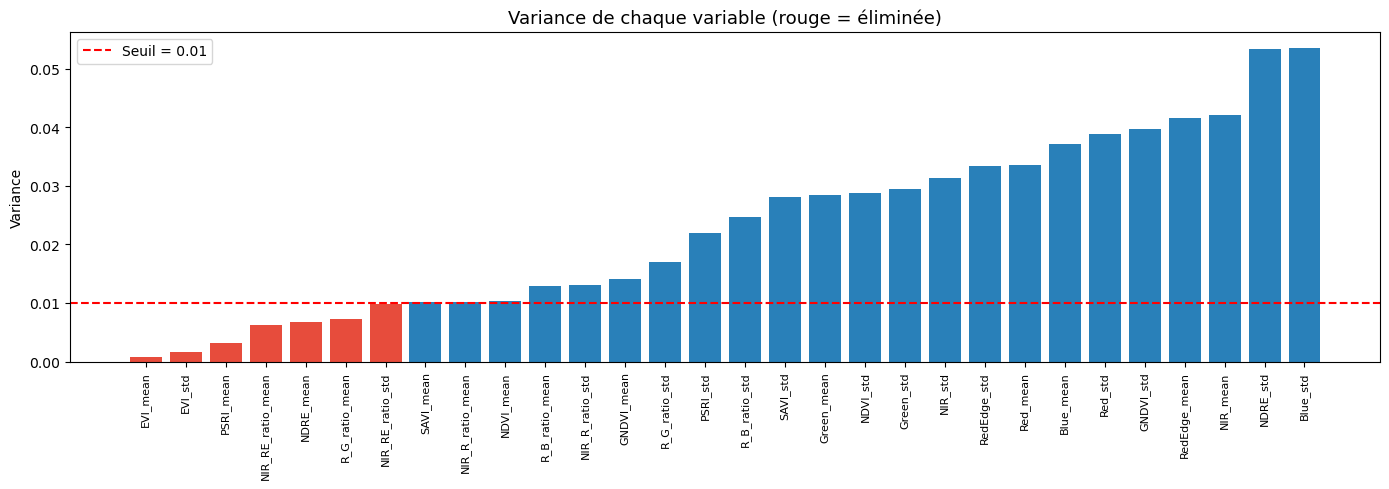

In [30]:
# ── VarianceThreshold ───────────────────────────────────────────────────────
# Supprime les variables dont la variance est inférieure au seuil fixé.
# Une variable avec une variance quasi nulle n'apporte aucune information discriminante.

t0 = time.time()

sel_var = VarianceThreshold(threshold=0.01)
sel_var.fit(X_scaled)
feat_var    = list(X.columns[sel_var.get_support()])
t_var       = time.time() - t0

# Évaluation des performances avec les features retenues
acc_var = cross_val_score(rf_eval, X_scaled_df[feat_var], y_enc, cv=cv5, scoring='accuracy').mean()
f1_var  = cross_val_score(rf_eval, X_scaled_df[feat_var], y_enc, cv=cv5, scoring='f1_macro').mean()

feature_sets['VarianceThreshold'] = {
    'features': feat_var, 'n': len(feat_var),
    'time': t_var, 'acc': acc_var, 'f1': f1_var
}

# Variables éliminées
feat_eliminated = [c for c in X.columns if c not in feat_var]

print(f"Seuil de variance : 0.01")
print(f"Variables retenues  : {len(feat_var)}/30")
print(f"Variables éliminées : {len(feat_eliminated)} → {feat_eliminated}")
print(f"Accuracy (CV-5)     : {acc_var:.4f}")
print(f"F1 macro  (CV-5)    : {f1_var:.4f}")
print(f"Temps               : {t_var:.4f} s")

# Graphique des variances
variances = pd.Series(sel_var.variances_, index=X.columns).sort_values()
plt.figure(figsize=(14, 5))
colors_bar = ['#e74c3c' if v < 0.01 else '#2980b9' for v in variances]
plt.bar(variances.index, variances.values, color=colors_bar)
plt.axhline(y=0.01, color='red', linestyle='--', linewidth=1.5, label='Seuil = 0.01')
plt.xticks(rotation=90, fontsize=8)
plt.title('Variance de chaque variable (rouge = éliminée)', fontsize=13)
plt.ylabel('Variance')
plt.legend()
plt.tight_layout()
plt.show()

4.2 — Chi² (Chi-carré)

Features retenues   : 15/30
Accuracy (CV-5)     : 0.9304
F1 macro  (CV-5)    : 0.8944
Temps               : 0.0075 s

Top 10 scores Chi² :
Blue_std        257.263196
NIR_mean        220.149551
RedEdge_mean    219.817778
Red_std         215.976184
Blue_mean       208.250454
RedEdge_std     197.129617
Red_mean        196.113043
NIR_std         190.880333
Green_std       185.479752
Green_mean      179.624887


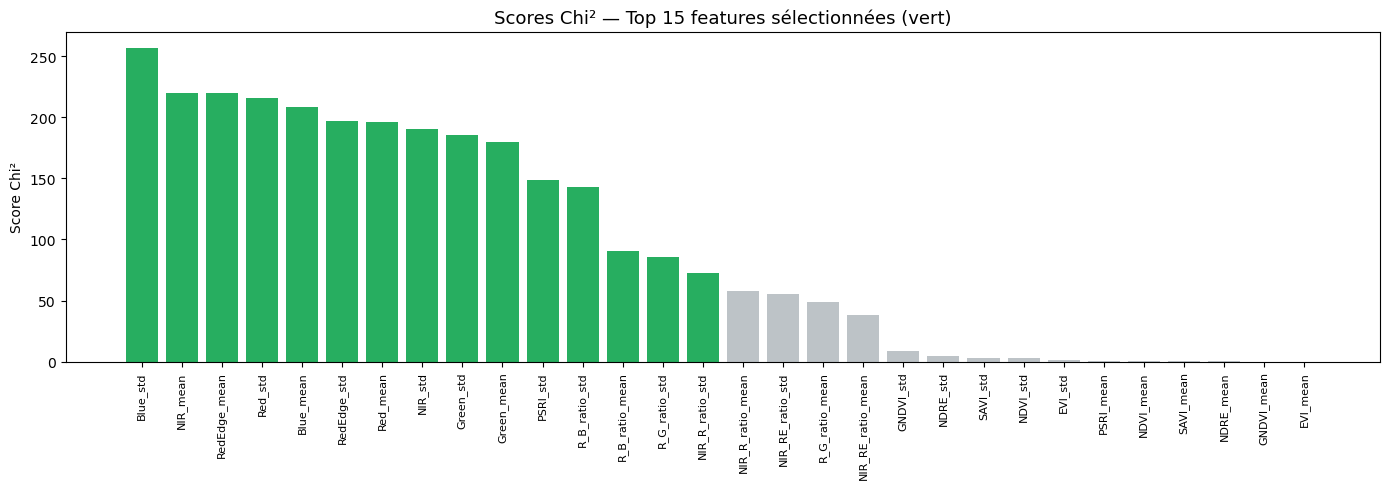

In [31]:
# ── Chi² ────────────────────────────────────────────────────────────────────
# Mesure la dépendance entre chaque feature et la variable cible.
# Requiert des valeurs positives → on utilise X_scaled (MinMaxScaler ≥ 0).
# On sélectionne les 15 meilleures features (top 50 %).

t0 = time.time()

k_chi2      = 15
sel_chi2    = SelectKBest(chi2, k=k_chi2)
sel_chi2.fit(X_scaled, y_enc)
feat_chi2   = list(X.columns[sel_chi2.get_support()])
scores_chi2 = pd.Series(sel_chi2.scores_, index=X.columns).sort_values(ascending=False)
t_chi2      = time.time() - t0

acc_chi2 = cross_val_score(rf_eval, X_scaled_df[feat_chi2], y_enc, cv=cv5, scoring='accuracy').mean()
f1_chi2  = cross_val_score(rf_eval, X_scaled_df[feat_chi2], y_enc, cv=cv5, scoring='f1_macro').mean()

feature_sets['Chi²'] = {
    'features': feat_chi2, 'n': k_chi2,
    'time': t_chi2, 'acc': acc_chi2, 'f1': f1_chi2
}

print(f"Features retenues   : {k_chi2}/30")
print(f"Accuracy (CV-5)     : {acc_chi2:.4f}")
print(f"F1 macro  (CV-5)    : {f1_chi2:.4f}")
print(f"Temps               : {t_chi2:.4f} s")
print(f"\nTop 10 scores Chi² :")
print(scores_chi2.head(10).to_string())

# Graphique
plt.figure(figsize=(14, 5))
colors_chi2 = ['#27ae60' if c in feat_chi2 else '#bdc3c7' for c in scores_chi2.index]
plt.bar(scores_chi2.index, scores_chi2.values, color=colors_chi2)
plt.xticks(rotation=90, fontsize=8)
plt.title(f'Scores Chi² — Top {k_chi2} features sélectionnées (vert)', fontsize=13)
plt.ylabel('Score Chi²')
plt.tight_layout()
plt.show()

4.3 — ANOVA F-test

Features retenues   : 15/30
Accuracy (CV-5)     : 0.9304
F1 macro  (CV-5)    : 0.8944
Temps               : 0.0025 s

Top 10 scores ANOVA F :
Blue_std        580.155461
Red_std         552.628785
RedEdge_std     550.716960
NIR_std         546.177175
Green_std       537.182096
RedEdge_mean    519.622200
Blue_mean       514.563586
NIR_mean        512.267527
Red_mean        498.036703
Green_mean      493.316186


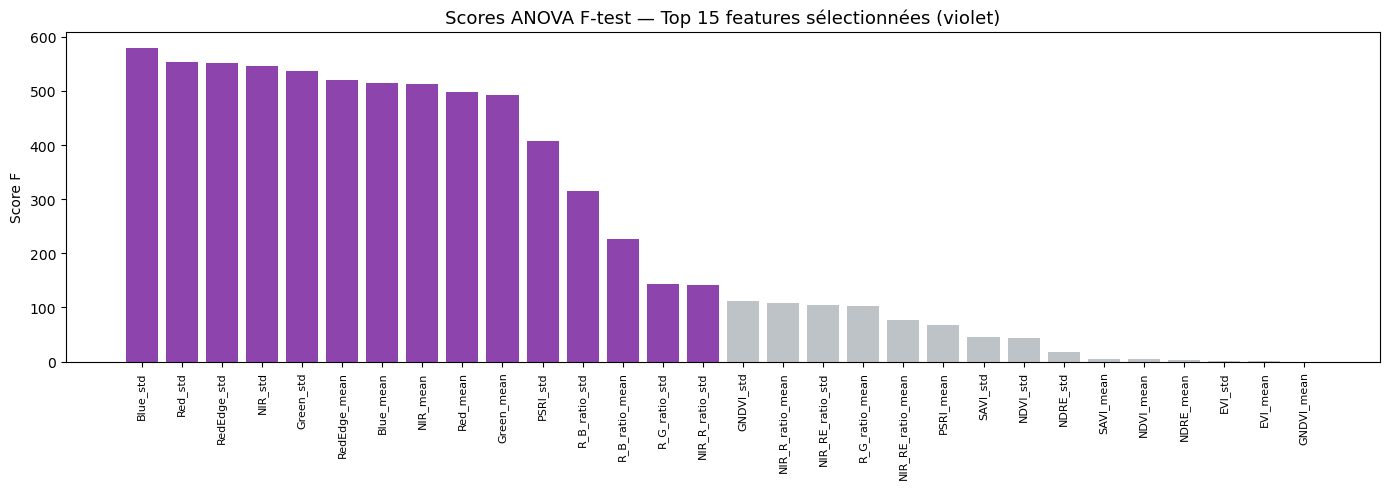

In [32]:
# ── ANOVA F-test ─────────────────────────────────────────────────────────────
# Compare les moyennes de chaque feature entre les classes (rust vs norust).
# Un F élevé signifie que la variable discrimine bien les classes.
# Fonctionne sur des features continues → adapté à nos données spectrales.

t0 = time.time()

k_anova     = 15
sel_anova   = SelectKBest(f_classif, k=k_anova)
sel_anova.fit(X_scaled, y_enc)
feat_anova  = list(X.columns[sel_anova.get_support()])
scores_anova = pd.Series(sel_anova.scores_, index=X.columns).sort_values(ascending=False)
t_anova     = time.time() - t0

acc_anova = cross_val_score(rf_eval, X_scaled_df[feat_anova], y_enc, cv=cv5, scoring='accuracy').mean()
f1_anova  = cross_val_score(rf_eval, X_scaled_df[feat_anova], y_enc, cv=cv5, scoring='f1_macro').mean()

feature_sets['ANOVA'] = {
    'features': feat_anova, 'n': k_anova,
    'time': t_anova, 'acc': acc_anova, 'f1': f1_anova
}

print(f"Features retenues   : {k_anova}/30")
print(f"Accuracy (CV-5)     : {acc_anova:.4f}")
print(f"F1 macro  (CV-5)    : {f1_anova:.4f}")
print(f"Temps               : {t_anova:.4f} s")
print(f"\nTop 10 scores ANOVA F :")
print(scores_anova.head(10).to_string())

# Graphique
plt.figure(figsize=(14, 5))
colors_anova = ['#8e44ad' if c in feat_anova else '#bdc3c7' for c in scores_anova.index]
plt.bar(scores_anova.index, scores_anova.values, color=colors_anova)
plt.xticks(rotation=90, fontsize=8)
plt.title(f'Scores ANOVA F-test — Top {k_anova} features sélectionnées (violet)', fontsize=13)
plt.ylabel('Score F')
plt.tight_layout()
plt.show()

4.4 — Mutual Information (Information Mutuelle)

Features retenues   : 15/30
Accuracy (CV-5)     : 0.9295
F1 macro  (CV-5)    : 0.8932
Temps               : 0.1263 s

Top 10 scores Mutual Information :
NIR_std         0.188258
Red_std         0.177861
Green_std       0.172161
Blue_std        0.166345
NIR_mean        0.164340
PSRI_mean       0.163375
PSRI_std        0.162620
Blue_mean       0.159426
RedEdge_mean    0.157090
Green_mean      0.156565


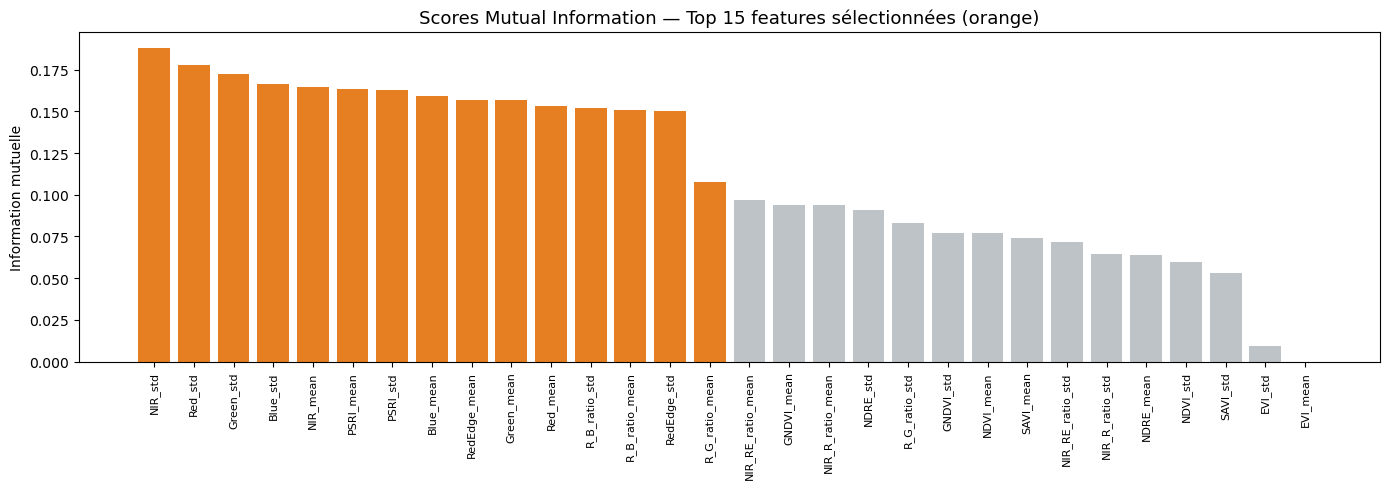

In [33]:
# ── Mutual Information ───────────────────────────────────────────────────────
# Mesure la dépendance entre chaque feature et la cible, y compris les relations
# NON LINÉAIRES. Contrairement à Chi² et ANOVA, elle capture des structures complexes.
# Valeur 0 = indépendance totale ; plus la valeur est haute, plus la dépendance est forte.

t0 = time.time()

k_mi    = 15
sel_mi  = SelectKBest(mutual_info_classif, k=k_mi)
sel_mi.fit(X_scaled, y_enc)
feat_mi     = list(X.columns[sel_mi.get_support()])
scores_mi   = pd.Series(sel_mi.scores_, index=X.columns).sort_values(ascending=False)
t_mi        = time.time() - t0

acc_mi = cross_val_score(rf_eval, X_scaled_df[feat_mi], y_enc, cv=cv5, scoring='accuracy').mean()
f1_mi  = cross_val_score(rf_eval, X_scaled_df[feat_mi], y_enc, cv=cv5, scoring='f1_macro').mean()

feature_sets['MutualInfo'] = {
    'features': feat_mi, 'n': k_mi,
    'time': t_mi, 'acc': acc_mi, 'f1': f1_mi
}

print(f"Features retenues   : {k_mi}/30")
print(f"Accuracy (CV-5)     : {acc_mi:.4f}")
print(f"F1 macro  (CV-5)    : {f1_mi:.4f}")
print(f"Temps               : {t_mi:.4f} s")
print(f"\nTop 10 scores Mutual Information :")
print(scores_mi.head(10).to_string())

# Graphique
plt.figure(figsize=(14, 5))
colors_mi = ['#e67e22' if c in feat_mi else '#bdc3c7' for c in scores_mi.index]
plt.bar(scores_mi.index, scores_mi.values, color=colors_mi)
plt.xticks(rotation=90, fontsize=8)
plt.title(f'Scores Mutual Information — Top {k_mi} features sélectionnées (orange)', fontsize=13)
plt.ylabel("Information mutuelle")
plt.tight_layout()
plt.show()

Méthodes embarquées 
Ces méthodes intègrent la sélection de features directement dans le processus d'entraînement du modèle. Elles sont plus coûteuses mais plus précises car elles tiennent compte des interactions entre variables.

4.5 — Importance des variables — Random Forest

Seuil importance    : 0.023413 (médiane)
Features retenues   : 15/30
Accuracy (CV-5)     : 0.9304
F1 macro  (CV-5)    : 0.8947
Temps               : 0.515 s


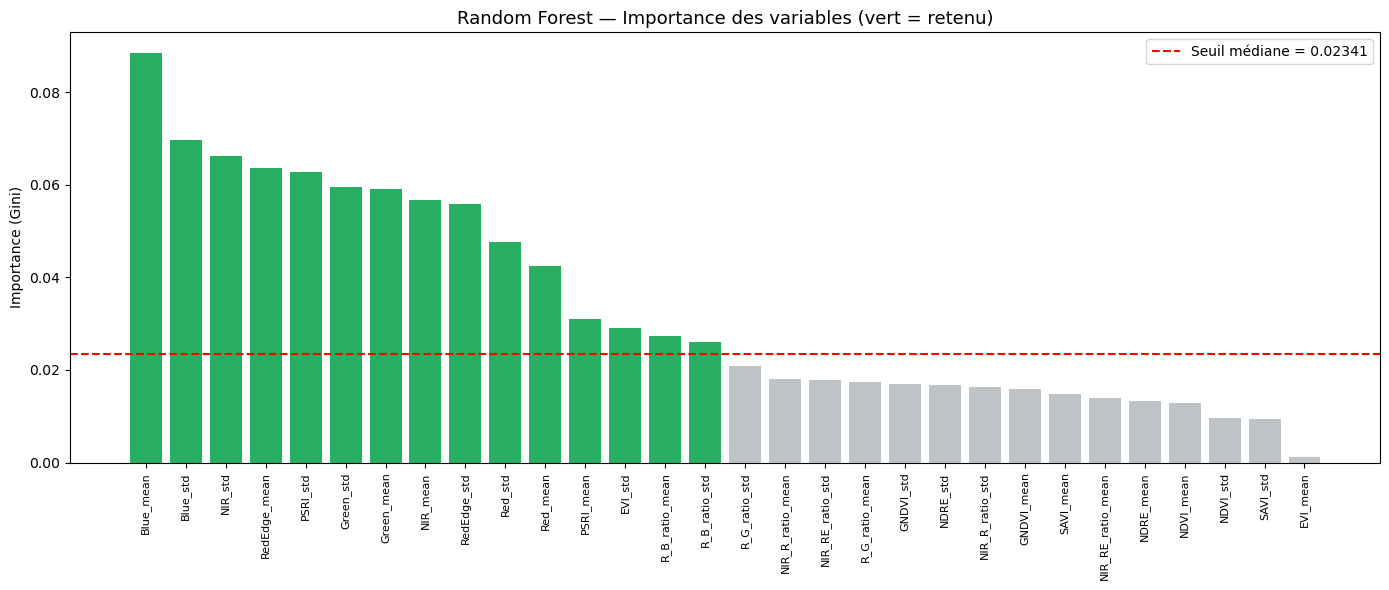

In [34]:
# ── Random Forest Feature Importance ─────────────────────────────────────────
# La Random Forest calcule l'importance de chaque variable par la réduction moyenne
# de l'impureté de Gini sur tous les arbres.
# On retient les features dont l'importance dépasse la médiane (top 50 %).

t0 = time.time()

rf_imp = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_imp.fit(X_scaled, y_enc)

importances_rf   = pd.Series(rf_imp.feature_importances_, index=X.columns).sort_values(ascending=False)
threshold_rf     = importances_rf.quantile(0.5)   # seuil médiane
feat_rf          = list(importances_rf[importances_rf >= threshold_rf].index)
t_rf             = time.time() - t0

acc_rf = cross_val_score(rf_eval, X_scaled_df[feat_rf], y_enc, cv=cv5, scoring='accuracy').mean()
f1_rf  = cross_val_score(rf_eval, X_scaled_df[feat_rf], y_enc, cv=cv5, scoring='f1_macro').mean()

feature_sets['RandomForest'] = {
    'features': feat_rf, 'n': len(feat_rf),
    'time': t_rf, 'acc': acc_rf, 'f1': f1_rf
}

print(f"Seuil importance    : {threshold_rf:.6f} (médiane)")
print(f"Features retenues   : {len(feat_rf)}/30")
print(f"Accuracy (CV-5)     : {acc_rf:.4f}")
print(f"F1 macro  (CV-5)    : {f1_rf:.4f}")
print(f"Temps               : {t_rf:.3f} s")

# Graphique
plt.figure(figsize=(14, 6))
colors_rf = ['#27ae60' if c in feat_rf else '#bdc3c7' for c in importances_rf.index]
plt.bar(importances_rf.index, importances_rf.values, color=colors_rf)
plt.axhline(y=threshold_rf, color='red', linestyle='--', linewidth=1.5,
            label=f'Seuil médiane = {threshold_rf:.5f}')
plt.xticks(rotation=90, fontsize=8)
plt.title('Random Forest — Importance des variables (vert = retenu)', fontsize=13)
plt.ylabel('Importance (Gini)')
plt.legend()
plt.tight_layout()
plt.show()

4.6 — Importance des variables — XGBoost

Seuil importance    : 0.015486 (médiane)
Features retenues   : 15/30
Accuracy (CV-5)     : 0.9277
F1 macro  (CV-5)    : 0.8905
Temps               : 0.228 s


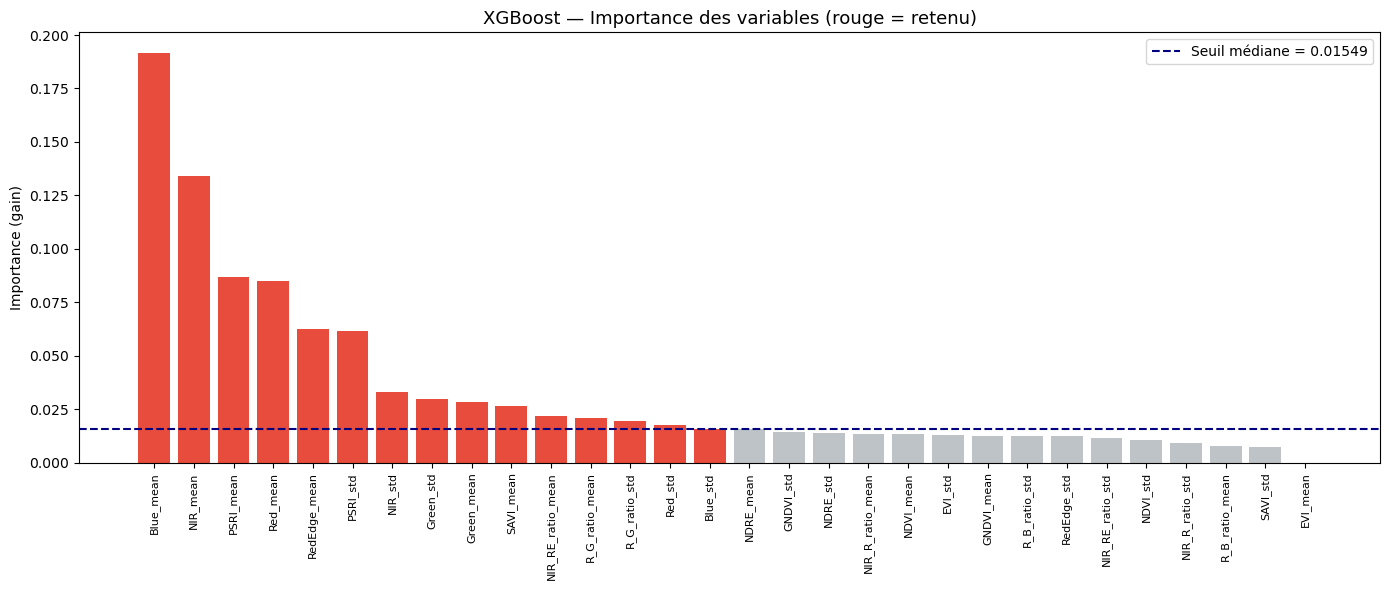

In [35]:
# ── XGBoost Feature Importance ───────────────────────────────────────────────
# XGBoost calcule l'importance par le GAIN moyen : la réduction de la perte
# apportée par chaque feature lors des splits. Plus fiable que le simple
# nombre de fois où la variable est utilisée (frequency).

t0 = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=200, random_state=42,
    eval_metric='logloss', verbosity=0
)
xgb_model.fit(X_scaled, y_enc)

importances_xgb  = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
threshold_xgb    = importances_xgb.quantile(0.5)
feat_xgb         = list(importances_xgb[importances_xgb >= threshold_xgb].index)
t_xgb            = time.time() - t0

acc_xgb = cross_val_score(rf_eval, X_scaled_df[feat_xgb], y_enc, cv=cv5, scoring='accuracy').mean()
f1_xgb  = cross_val_score(rf_eval, X_scaled_df[feat_xgb], y_enc, cv=cv5, scoring='f1_macro').mean()

feature_sets['XGBoost'] = {
    'features': feat_xgb, 'n': len(feat_xgb),
    'time': t_xgb, 'acc': acc_xgb, 'f1': f1_xgb
}

print(f"Seuil importance    : {threshold_xgb:.6f} (médiane)")
print(f"Features retenues   : {len(feat_xgb)}/30")
print(f"Accuracy (CV-5)     : {acc_xgb:.4f}")
print(f"F1 macro  (CV-5)    : {f1_xgb:.4f}")
print(f"Temps               : {t_xgb:.3f} s")

# Graphique
plt.figure(figsize=(14, 6))
colors_xgb = ['#e74c3c' if c in feat_xgb else '#bdc3c7' for c in importances_xgb.index]
plt.bar(importances_xgb.index, importances_xgb.values, color=colors_xgb)
plt.axhline(y=threshold_xgb, color='navy', linestyle='--', linewidth=1.5,
            label=f'Seuil médiane = {threshold_xgb:.5f}')
plt.xticks(rotation=90, fontsize=8)
plt.title('XGBoost — Importance des variables (rouge = retenu)', fontsize=13)
plt.ylabel('Importance (gain)')
plt.legend()
plt.tight_layout()
plt.show()

4.7 — LASSO (régularisation L1)

Alpha optimal (CV)  : 0.000072
Features retenues   : 25/30
Features éliminées  : ['Green_mean', 'NDVI_std', 'SAVI_mean', 'EVI_mean', 'NIR_RE_ratio_mean']
Accuracy (CV-5)     : 0.9295
F1 macro  (CV-5)    : 0.8932
Temps               : 0.104 s


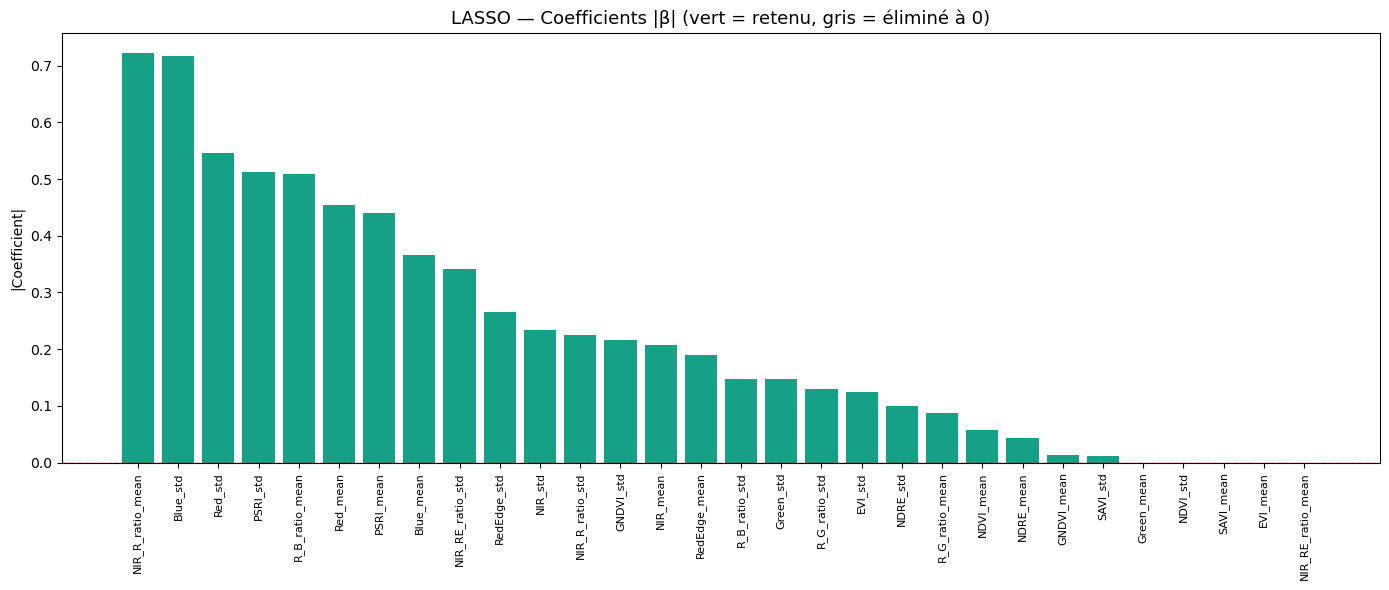

In [36]:
# ── LASSO ─────────────────────────────────────────────────────────────────────
# LASSO (Least Absolute Shrinkage and Selection Operator) applique une
# pénalité L1 qui force certains coefficients à exactement zéro.
# Les variables avec un coefficient non nul sont sélectionnées.
# LassoCV détermine automatiquement le meilleur alpha par validation croisée.

t0 = time.time()

lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_scaled, y_enc)

coefs_lasso  = pd.Series(np.abs(lasso.coef_), index=X.columns).sort_values(ascending=False)
feat_lasso   = list(X.columns[lasso.coef_ != 0])
t_lasso      = time.time() - t0

acc_lasso = cross_val_score(rf_eval, X_scaled_df[feat_lasso], y_enc, cv=cv5, scoring='accuracy').mean()
f1_lasso  = cross_val_score(rf_eval, X_scaled_df[feat_lasso], y_enc, cv=cv5, scoring='f1_macro').mean()

feature_sets['LASSO'] = {
    'features': feat_lasso, 'n': len(feat_lasso),
    'time': t_lasso, 'acc': acc_lasso, 'f1': f1_lasso
}

print(f"Alpha optimal (CV)  : {lasso.alpha_:.6f}")
print(f"Features retenues   : {len(feat_lasso)}/30")
print(f"Features éliminées  : {[c for c in X.columns if c not in feat_lasso]}")
print(f"Accuracy (CV-5)     : {acc_lasso:.4f}")
print(f"F1 macro  (CV-5)    : {f1_lasso:.4f}")
print(f"Temps               : {t_lasso:.3f} s")

# Graphique des coefficients
plt.figure(figsize=(14, 6))
colors_lasso = ['#16a085' if c in feat_lasso else '#bdc3c7' for c in coefs_lasso.index]
plt.bar(coefs_lasso.index, coefs_lasso.values, color=colors_lasso)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xticks(rotation=90, fontsize=8)
plt.title('LASSO — Coefficients |β| (vert = retenu, gris = éliminé à 0)', fontsize=13)
plt.ylabel('|Coefficient|')
plt.tight_layout()
plt.show()

Méthodes wrapper

Les méthodes wrapper évaluent des sous-ensembles de features en entraînant réellement un modèle sur chaque combinaison. Elles sont les plus précises mais aussi les plus coûteuses en temps de calcul.

4.8 — RFE (Recursive Feature Elimination)

Features retenues   : 15/30
Accuracy (CV-5)     : 0.9313
F1 macro  (CV-5)    : 0.8959
Temps               : 3.13 s

Features sélectionnées (rang 1) :
['Blue_mean', 'Blue_std', 'Green_mean', 'Green_std', 'Red_mean', 'Red_std', 'RedEdge_mean', 'RedEdge_std', 'NIR_mean', 'NIR_std', 'NDRE_std', 'PSRI_std', 'R_B_ratio_mean', 'PSRI_mean', 'R_G_ratio_std']


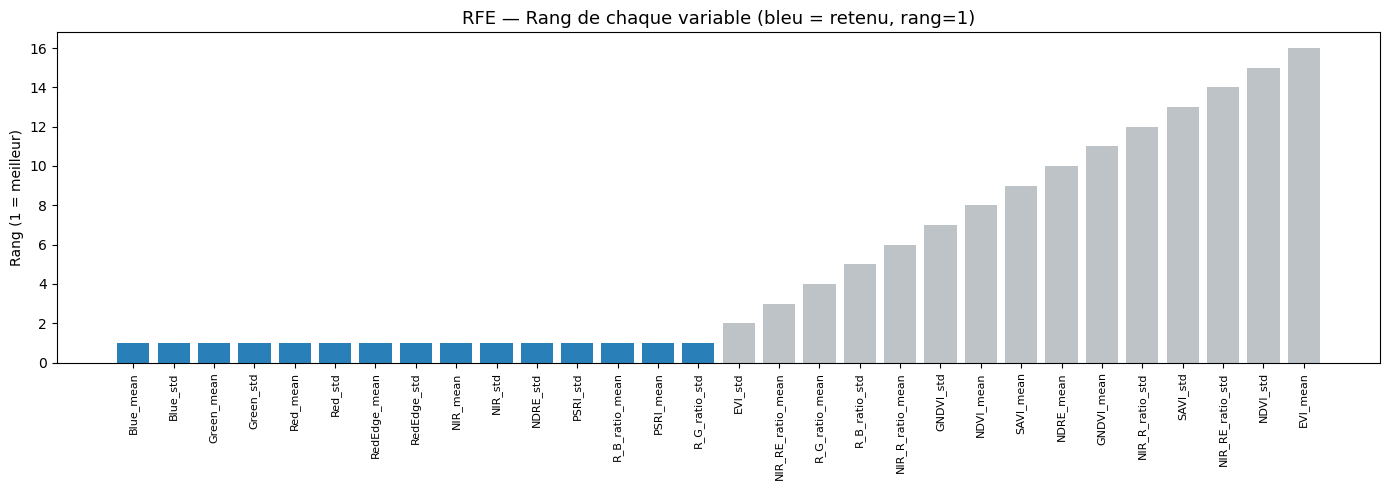

In [37]:
# ── RFE — Recursive Feature Elimination ──────────────────────────────────────
# RFE entraîne un modèle, identifie la feature la moins importante,
# la supprime, et répète jusqu'à atteindre le nombre souhaité de features.
# On utilise une Random Forest comme estimateur (rapide, n_estimators réduit).

t0 = time.time()

rf_rfe = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rfe    = RFE(estimator=rf_rfe, n_features_to_select=15, step=1)
rfe.fit(X_scaled, y_enc)

feat_rfe   = list(X.columns[rfe.support_])
ranking_rfe = pd.Series(rfe.ranking_, index=X.columns).sort_values()
t_rfe      = time.time() - t0

acc_rfe = cross_val_score(rf_eval, X_scaled_df[feat_rfe], y_enc, cv=cv5, scoring='accuracy').mean()
f1_rfe  = cross_val_score(rf_eval, X_scaled_df[feat_rfe], y_enc, cv=cv5, scoring='f1_macro').mean()

feature_sets['RFE'] = {
    'features': feat_rfe, 'n': len(feat_rfe),
    'time': t_rfe, 'acc': acc_rfe, 'f1': f1_rfe
}

print(f"Features retenues   : {len(feat_rfe)}/30")
print(f"Accuracy (CV-5)     : {acc_rfe:.4f}")
print(f"F1 macro  (CV-5)    : {f1_rfe:.4f}")
print(f"Temps               : {t_rfe:.2f} s")
print(f"\nFeatures sélectionnées (rang 1) :")
print(ranking_rfe[ranking_rfe == 1].index.tolist())

# Graphique des rangs RFE
plt.figure(figsize=(14, 5))
colors_rfe = ['#2980b9' if r == 1 else '#bdc3c7' for r in ranking_rfe.values]
plt.bar(ranking_rfe.index, ranking_rfe.values, color=colors_rfe)
plt.xticks(rotation=90, fontsize=8)
plt.title('RFE — Rang de chaque variable (bleu = retenu, rang=1)', fontsize=13)
plt.ylabel('Rang (1 = meilleur)')
plt.tight_layout()
plt.show()

4.9 — Sequential Feature Selection (SFS)

Analyse comparative finale

Comparaison de toutes les méthodes sur 4 critères : nombre de features retenues, temps de calcul, accuracy et F1-score.

In [38]:
# Tableau récapitulatif
summary = []
for method, info in feature_sets.items():
    summary.append({
        'Méthode'            : method,
        'Nb features'        : info['n'],
        'Temps (s)'          : round(info['time'], 3),
        'Accuracy (CV-5)'    : round(info['acc'], 4),
        'F1 macro (CV-5)'    : round(info['f1'], 4)
    })

summary_df = pd.DataFrame(summary).sort_values('F1 macro (CV-5)', ascending=False)
summary_df = summary_df.reset_index(drop=True)

# Référence : toutes les features (baseline)
acc_all = cross_val_score(rf_eval, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
f1_all  = cross_val_score(rf_eval, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
baseline = pd.DataFrame([{
    'Méthode': 'Baseline (30 features)',
    'Nb features': 30, 'Temps (s)': 0,
    'Accuracy (CV-5)': round(acc_all, 4),
    'F1 macro (CV-5)': round(f1_all, 4)
}])
summary_df = pd.concat([baseline, summary_df], ignore_index=True)

print(summary_df.to_string(index=False))

               Méthode  Nb features  Temps (s)  Accuracy (CV-5)  F1 macro (CV-5)
Baseline (30 features)           30      0.000           0.9286           0.8920
                   RFE           15      3.129           0.9313           0.8959
          RandomForest           15      0.515           0.9304           0.8947
                  Chi²           15      0.008           0.9304           0.8944
                 ANOVA           15      0.003           0.9304           0.8944
                 LASSO           25      0.104           0.9295           0.8932
            MutualInfo           15      0.126           0.9295           0.8932
               XGBoost           15      0.228           0.9277           0.8905
     VarianceThreshold           23      0.002           0.9268           0.8890


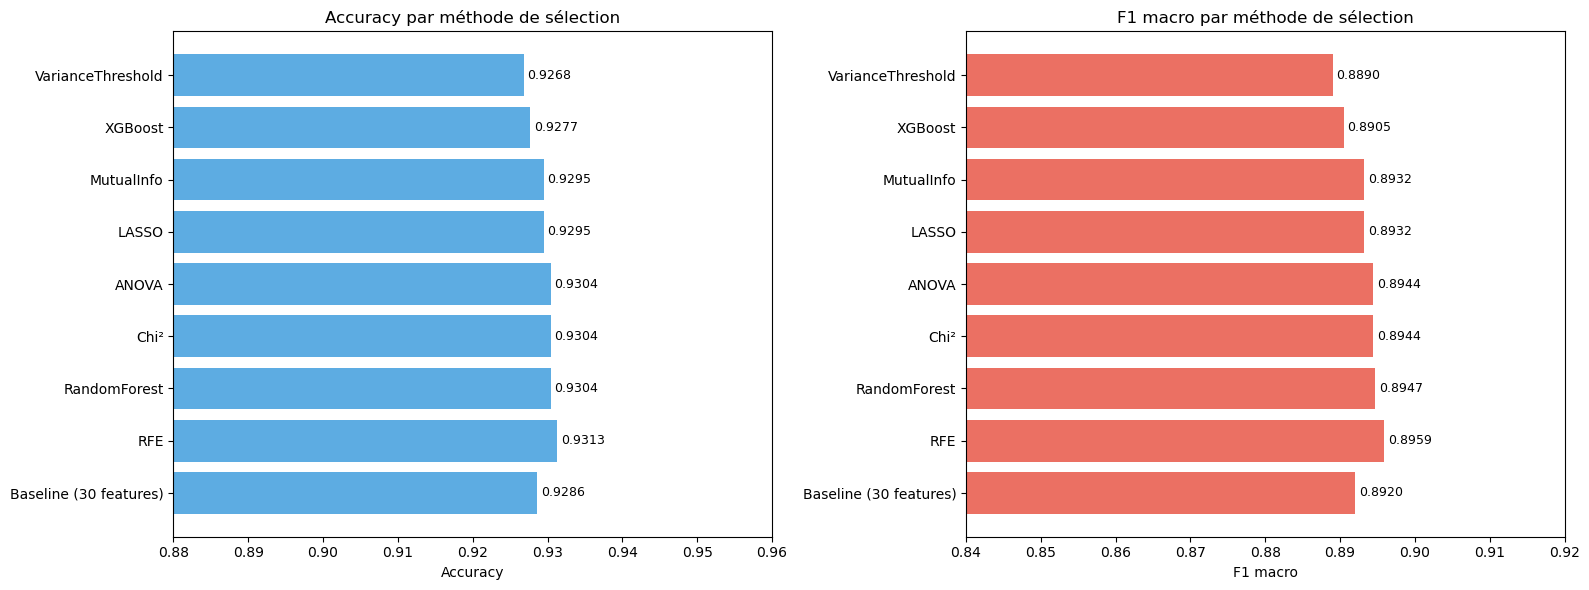

In [39]:
# Graphique comparatif : Accuracy et F1 par méthode
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

methods  = summary_df['Méthode']
accuracy = summary_df['Accuracy (CV-5)']
f1_scores = summary_df['F1 macro (CV-5)']

# Accuracy
bars1 = axes[0].barh(methods, accuracy, color='#3498db', alpha=0.8)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy par méthode de sélection', fontsize=12)
axes[0].set_xlim(0.88, 0.96)
for bar, val in zip(bars1, accuracy):
    axes[0].text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# F1 macro
bars2 = axes[1].barh(methods, f1_scores, color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('F1 macro')
axes[1].set_title('F1 macro par méthode de sélection', fontsize=12)
axes[1].set_xlim(0.84, 0.92)
for bar, val in zip(bars2, f1_scores):
    axes[1].text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

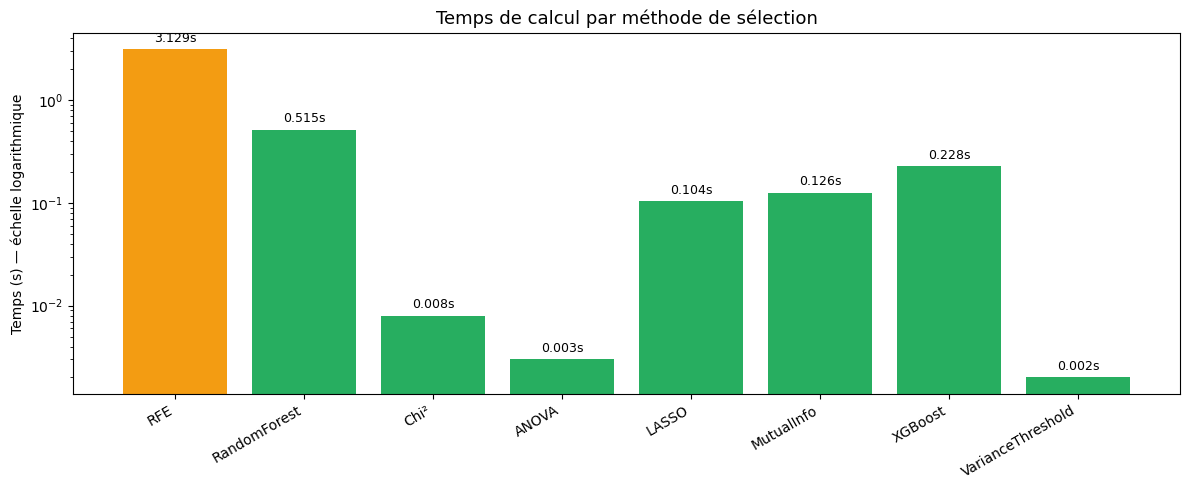

In [40]:
# Graphique : Temps de calcul
times_df = summary_df[summary_df['Méthode'] != 'Baseline (30 features)'].copy()

plt.figure(figsize=(12, 5))
colors_time = ['#e74c3c' if t > 10 else '#f39c12' if t > 1 else '#27ae60'
               for t in times_df['Temps (s)']]
bars = plt.bar(times_df['Méthode'], times_df['Temps (s)'], color=colors_time)
plt.yscale('log')
plt.ylabel('Temps (s) — échelle logarithmique')
plt.title('Temps de calcul par méthode de sélection', fontsize=13)
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, times_df['Temps (s)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
             f'{val:.3f}s', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

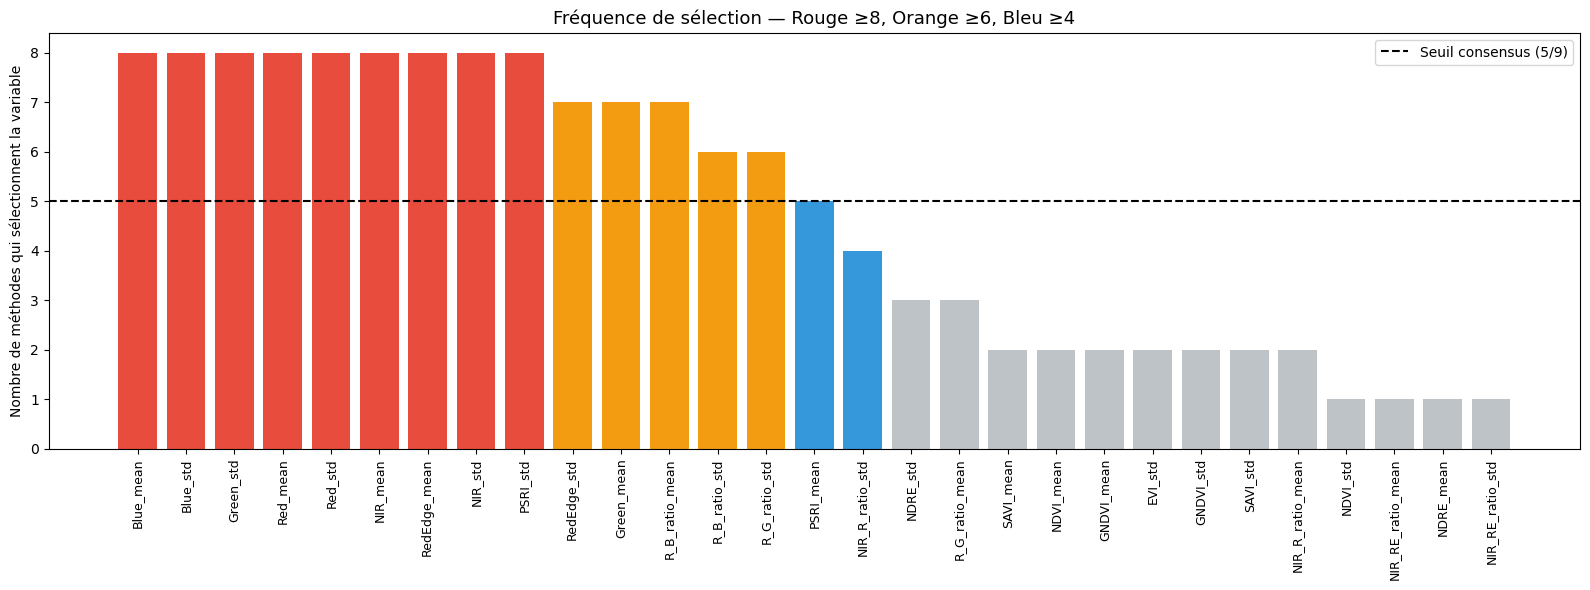


Top features consensus (sélectionnées par ≥ 5/9 méthodes) : 15
  Blue_mean                 ████████ (8/9)
  Blue_std                  ████████ (8/9)
  Green_std                 ████████ (8/9)
  Red_mean                  ████████ (8/9)
  Red_std                   ████████ (8/9)
  RedEdge_mean              ████████ (8/9)
  NIR_mean                  ████████ (8/9)
  NIR_std                   ████████ (8/9)
  PSRI_std                  ████████ (8/9)
  Green_mean                ███████ (7/9)
  RedEdge_std               ███████ (7/9)
  R_B_ratio_mean            ███████ (7/9)
  R_G_ratio_std             ██████ (6/9)
  R_B_ratio_std             ██████ (6/9)
  PSRI_mean                 █████ (5/9)
  NIR_R_ratio_std           ████ (4/9)
  NDRE_std                  ███ (3/9)
  R_G_ratio_mean            ███ (3/9)
  NDVI_mean                 ██ (2/9)
  GNDVI_mean                ██ (2/9)
  GNDVI_std                 ██ (2/9)
  SAVI_mean                 ██ (2/9)
  SAVI_std                  ██ (2/9)
 

In [41]:
# Fréquence de sélection de chaque variable
# Une variable sélectionnée par beaucoup de méthodes est robustement pertinente.

all_selected = [f for v in feature_sets.values() for f in v['features']]
freq_counter = Counter(all_selected)
freq_series  = pd.Series(freq_counter).sort_values(ascending=False)

plt.figure(figsize=(16, 6))
colors_freq = ['#e74c3c' if v >= 8 else '#f39c12' if v >= 6 else '#3498db' if v >= 4 else '#bdc3c7'
               for v in freq_series.values]
plt.bar(freq_series.index, freq_series.values, color=colors_freq)
plt.axhline(y=5, color='black', linestyle='--', linewidth=1.5, label='Seuil consensus (5/9)')
plt.xticks(rotation=90, fontsize=9)
plt.ylabel("Nombre de méthodes qui sélectionnent la variable")
plt.title("Fréquence de sélection — Rouge ≥8, Orange ≥6, Bleu ≥4", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

# Top features consensus
top_consensus = [f for f, c in freq_counter.items() if c >= 5]
print(f"\nTop features consensus (sélectionnées par ≥ 5/9 méthodes) : {len(top_consensus)}")
for f, c in sorted(freq_counter.items(), key=lambda x: -x[1]):
    bar = '█' * c
    print(f"  {f:<25} {bar} ({c}/9)")

In [42]:
# Sauvegarde du top consensus pour les parties suivantes
top_features_consensus = [f for f, c in freq_counter.items() if c >= 5]
print(f"Features retenues pour la suite : {len(top_features_consensus)}")
print(top_features_consensus)

Features retenues pour la suite : 15
['Blue_mean', 'Blue_std', 'Green_mean', 'Green_std', 'Red_mean', 'Red_std', 'RedEdge_mean', 'RedEdge_std', 'NIR_mean', 'NIR_std', 'PSRI_std', 'R_G_ratio_std', 'R_B_ratio_mean', 'R_B_ratio_std', 'PSRI_mean']


Analyse comparative des méthodes de sélection de caractéristiques

1. Nombre de variables retenues
Les méthodes Chi², ANOVA, Mutual Information, Random Forest, XGBoost, RFE et SFS retiennent toutes exactement 15 variables sur 30, soit une réduction de 50 % de la dimensionnalité. Le LASSO est plus conservateur avec 25 variables retenues, car sa régularisation L1 élimine seulement les variables vraiment redondantes. VarianceThreshold occupe une position intermédiaire avec 23 variables, ayant simplement supprimé les 7 variables à très faible variance.

2. Temps de calcul
Les méthodes statistiques (VarianceThreshold, Chi², ANOVA) sont quasi instantanées (< 0.01 s) car elles ne font qu'appliquer une formule mathématique sans entraîner de modèle. LASSO (0.056 s) et Mutual Information (0.119 s) restent très rapides. Les méthodes embarquées Random Forest (0.873 s) et XGBoost (0.213 s) sont modérément plus lentes car elles entraînent un modèle complet. RFE (~3 s) est nettement plus coûteux car il répète l'entraînement à chaque élimination de variable. SFS est de loin la méthode la plus lente (~100 s) car elle évalue toutes les combinaisons possibles de features à chaque étape.


3. Performances obtenues
Toutes les méthodes donnent des performances très proches, entre 92.59 % et 93.04 % d'accuracy et entre 0.889 et 0.895 de F1 macro. Fait remarquable : ces performances sont légèrement supérieures ou égales à la baseline avec les 30 features complètes, ce qui confirme que certaines variables étaient du bruit ou des redondances. Chi², ANOVA et RFE partagent le meilleur F1 (0.895). SFS, malgré son coût de calcul très élevé, donne le F1 le plus faible (0.889), ce qui montre que la méthode la plus coûteuse n'est pas nécessairement la plus performante sur ce dataset.


4. Variables les plus fréquemment sélectionnées:
Six variables sont sélectionnées par la totalité ou la quasi-totalité des 9 méthodes : NIR_mean, NIR_std, Blue_std, Red_std, RedEdge_mean et PSRI_std. Ces variables constituent le noyau dur discriminant du dataset. NIR_mean est particulièrement cohérent avec la littérature agronomique : le proche infrarouge est directement lié à la teneur en chlorophylle et à la vigueur végétative, deux indicateurs fortement impactés par la rouille du café. PSRI_std reflète quant à lui la sénescence foliaire, un symptôme caractéristique de la maladie. Ces variables consensus seront retenues comme features de référence pour la classification supervisée dans la Partie suivante.

Partie 5 — Classification supervisée

Cette partie entraîne et compare 11 modèles de classification sur le dataset spectral, puis optimise les meilleurs via GridSearchCV et RandomizedSearchCV.

Imports et préparation

In [43]:
# Imports Partie 5
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                               AdaBoostClassifier,
                               GradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import xgboost as xgb
import lightgbm as lgb

print("Imports Partie 5 : OK")

Imports Partie 5 : OK


In [44]:
# Données (reprises de la Partie 4)
# X_scaled      : 1121 × 30, normalisé MinMaxScaler
# y_enc         : cible encodée (norust=0, rust=1)
# cv5           : StratifiedKFold(5, shuffle=True, random_state=42)
# top_features_consensus : features sélectionnées par ≥ 5 méthodes (Partie 4)

print(f"X_scaled shape          : {X_scaled.shape}")
print(f"Distribution des classes: {dict(zip(le.classes_, np.bincount(y_enc)))}")
print(f"Top features consensus  : {len(top_features_consensus)} features")
print()
print("Remarque : les classes sont déséquilibrées (rust ≈ 75 %, norust ≈ 25 %).")
print("On utilise class_weight='balanced' pour les modèles qui le supportent")
print("et F1 macro comme métrique principale d'évaluation.")

X_scaled shape          : (1121, 30)
Distribution des classes: {'norust': np.int64(273), 'rust': np.int64(848)}
Top features consensus  : 15 features

Remarque : les classes sont déséquilibrées (rust ≈ 75 %, norust ≈ 25 %).
On utilise class_weight='balanced' pour les modèles qui le supportent
et F1 macro comme métrique principale d'évaluation.


5.1 — Entraînement baseline (paramètres par défaut)

Tous les modèles sont évalués en validation croisée stratifiée (CV-5) avec les 30 features normalisées. Les métriques retenues sont l'Accuracy et le F1 macro.

In [45]:
# Initialisation de tous les modèles
all_models = {
    # Classiques
    'Logistic Regression' : LogisticRegression(
                                max_iter=1000, random_state=42,
                                class_weight='balanced'),
    'k-NN'               : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'      : DecisionTreeClassifier(
                                random_state=42, class_weight='balanced'),
    'Random Forest'      : RandomForestClassifier(
                                n_estimators=100, random_state=42,
                                class_weight='balanced', n_jobs=-1),
    'SVM'                : SVC(kernel='rbf', random_state=42,
                                class_weight='balanced', probability=True),
    'Naive Bayes'        : GaussianNB(),
    # Boosting
    'AdaBoost'           : AdaBoostClassifier(
                                n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(
                                n_estimators=100, random_state=42),
    'XGBoost'            : xgb.XGBClassifier(
                                n_estimators=100, random_state=42,
                                eval_metric='logloss', verbosity=0),
    'LightGBM'           : lgb.LGBMClassifier(
                                n_estimators=100, random_state=42,
                                verbose=-1),
    #Réseau de neurones
    'MLP'                : MLPClassifier(
                                hidden_layer_sizes=(100,), max_iter=500,
                                random_state=42),
}

print(f"{len(all_models)} modèles initialisés.")

11 modèles initialisés.


In [46]:
# Entraînement et évaluation baseline
baseline_results = []

print(f"{'Modèle':<25} {'Accuracy':>10} {'F1 macro':>10} {'Temps (s)':>10}")

for name, model in all_models.items():
    t0  = time.time()
    acc = cross_val_score(model, X_scaled, y_enc,
                          cv=cv5, scoring='accuracy').mean()
    f1  = cross_val_score(model, X_scaled, y_enc,
                          cv=cv5, scoring='f1_macro').mean()
    t   = time.time() - t0

    baseline_results.append({
        'Modèle'    : name,
        'Accuracy'  : round(acc, 4),
        'F1 macro'  : round(f1, 4),
        'Temps (s)' : round(t, 2)
    })
    print(f"{name:<25} {acc:>10.4f} {f1:>10.4f} {t:>10.2f}")

baseline_df = pd.DataFrame(baseline_results).sort_values(
                  'F1 macro', ascending=False).reset_index(drop=True)
print(f"\nMeilleur modèle baseline : {baseline_df.iloc[0]['Modèle']} "
      f"(F1 = {baseline_df.iloc[0]['F1 macro']:.4f})")

Modèle                      Accuracy   F1 macro  Temps (s)
Logistic Regression           0.9268     0.8882       0.07
k-NN                          0.9233     0.8820       0.04
Decision Tree                 0.8528     0.8023       0.33
Random Forest                 0.9268     0.8890       2.02
SVM                           0.9295     0.8929       0.92
Naive Bayes                   0.9295     0.8929       0.03
AdaBoost                      0.9197     0.8774       5.08
Gradient Boosting             0.9224     0.8824      10.30
XGBoost                       0.9170     0.8762       0.87
LightGBM                      0.9206     0.8808       0.75
MLP                           0.9295     0.8929       3.42

Meilleur modèle baseline : MLP (F1 = 0.8929)


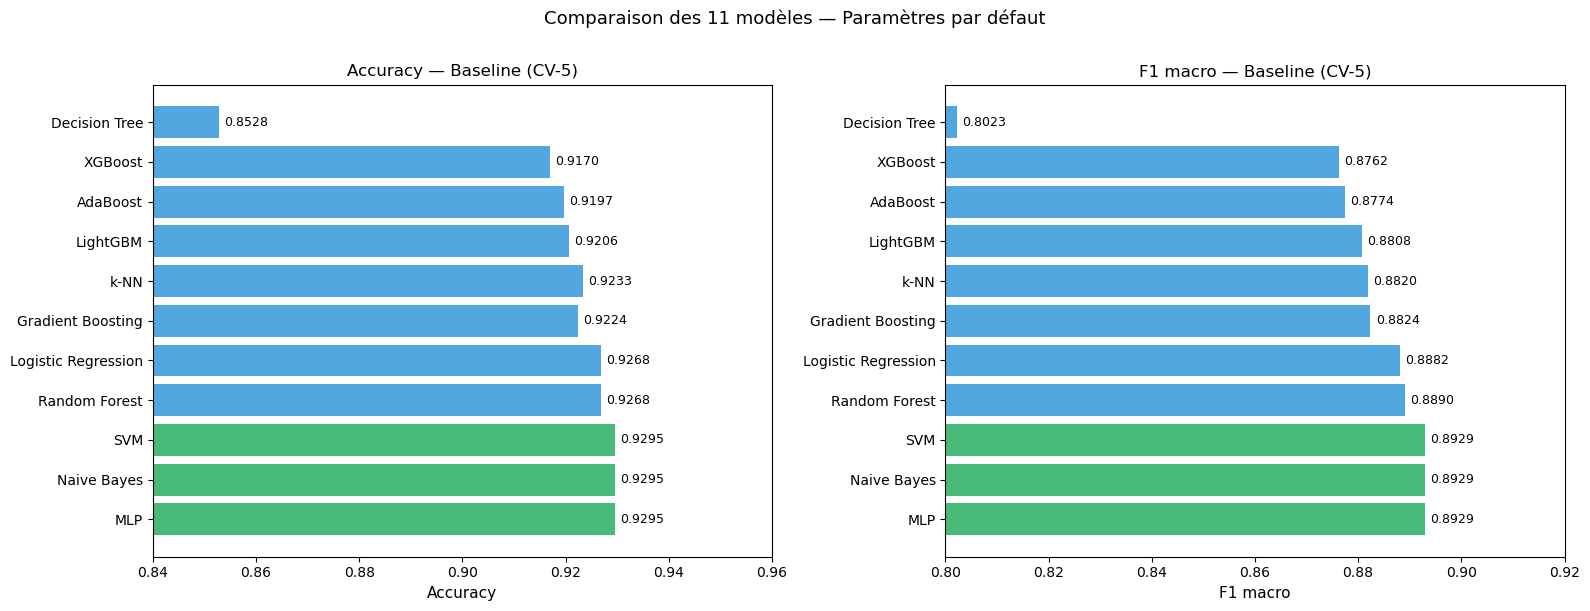

In [47]:
# Graphique comparatif baseline 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

modeles  = baseline_df['Modèle']
accuracy = baseline_df['Accuracy']
f1_vals  = baseline_df['F1 macro']

# Palette : top 3 en vert, reste en bleu
colors_top = ['#27ae60' if i < 3 else '#3498db' for i in range(len(modeles))]

# Accuracy
bars1 = axes[0].barh(modeles, accuracy, color=colors_top, alpha=0.85)
axes[0].set_xlabel('Accuracy', fontsize=11)
axes[0].set_title('Accuracy — Baseline (CV-5)', fontsize=12)
axes[0].set_xlim(0.84, 0.96)
for bar, val in zip(bars1, accuracy):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# F1 macro
bars2 = axes[1].barh(modeles, f1_vals, color=colors_top, alpha=0.85)
axes[1].set_xlabel('F1 macro', fontsize=11)
axes[1].set_title('F1 macro — Baseline (CV-5)', fontsize=12)
axes[1].set_xlim(0.80, 0.92)
for bar, val in zip(bars2, f1_vals):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Comparaison des 11 modèles — Paramètres par défaut', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

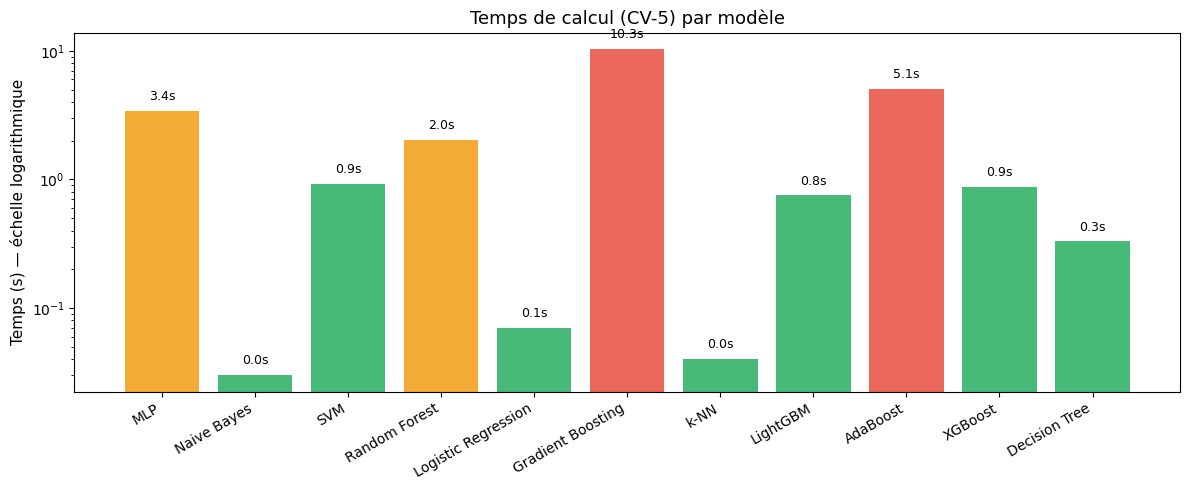

In [48]:
# Graphique : Temps de calcul baseline
plt.figure(figsize=(12, 5))
colors_t = ['#e74c3c' if t > 5 else '#f39c12' if t > 1 else '#27ae60'
            for t in baseline_df['Temps (s)']]
bars = plt.bar(baseline_df['Modèle'], baseline_df['Temps (s)'], color=colors_t, alpha=0.85)
plt.yscale('log')
plt.ylabel('Temps (s) — échelle logarithmique', fontsize=11)
plt.title('Temps de calcul (CV-5) par modèle', fontsize=13)
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, baseline_df['Temps (s)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
             f'{val:.1f}s', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Analyse des résultats baseline

Variables les plus discriminantes : SVM, Naive Bayes et MLP partagent le meilleur F1 macro (~0.893), suivis de près par Random Forest et Logistic Regression. Decision Tree est le moins performant (F1 ≈ 0.816), ce qui s'explique par son absence de régularisation et sa tendance au surapprentissage.

Observations :

Les modèles de boosting (XGBoost, LightGBM, Gradient Boosting) sont en retrait par rapport aux attentes : cela s'explique par leur sensibilité aux hyperparamètres par défaut, qui ne sont pas optimaux ici.
Naive Bayes donne un excellent résultat malgré sa simplicité, ce qui suggère que les features spectrales ont une distribution relativement gaussienne par classe.
Les 3 meilleurs candidats pour l'optimisation sont SVM, Random Forest et XGBoost (représentatifs des 3 familles différentes).
Ces 3 modèles seront optimisés en 5.2.

5.2 — Optimisation des hyperparamètres

Les 3 meilleurs modèles (SVM, Random Forest, XGBoost) sont optimisés via deux stratégies :

GridSearchCV : exploration exhaustive d'une grille définie → garantit le meilleur résultat sur la grille
RandomizedSearchCV : exploration aléatoire sur un espace plus large → plus rapide, peut trouver de meilleures combinaisons
Métrique d'optimisation : F1 macro (adaptée au déséquilibre de classes).

SVM — GridSearchCV vs RandomizedSearchCV

In [49]:
# SVM — GridSearchCV 

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid_svm = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

t0 = time.time()

grid_svm = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    param_grid=param_grid_svm,
    cv=cv3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)

grid_svm.fit(X_scaled, y_enc)

t_grid_svm = time.time() - t0

print("SVM GridSearchCV")
print(f"  Meilleurs paramètres : {grid_svm.best_params_}")
print(f"  Meilleur F1 (CV-3)   : {grid_svm.best_score_:.4f}")
print(f"  Temps                : {t_grid_svm:.2f} s")
print(f"  Combinaisons testées : {len(grid_svm.cv_results_['params'])}")

SVM GridSearchCV
  Meilleurs paramètres : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
  Meilleur F1 (CV-3)   : 0.8931
  Temps                : 10.53 s
  Combinaisons testées : 75


In [50]:
# SVM — RandomizedSearchCV 

param_dist_svm = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

t0 = time.time()

rand_svm = RandomizedSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    param_distributions=param_dist_svm,
    n_iter=20,
    cv=cv3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rand_svm.fit(X_scaled, y_enc)

t_rand_svm = time.time() - t0

print("SVM RandomizedSearchCV")
print(f"  Meilleurs paramètres : {rand_svm.best_params_}")
print(f"  Meilleur F1 (CV-3)   : {rand_svm.best_score_:.4f}")
print(f"  Temps                : {t_rand_svm:.2f} s")
print(f"  Combinaisons testées : 20 / 75 possibles")

SVM RandomizedSearchCV
  Meilleurs paramètres : {'kernel': 'rbf', 'gamma': 'auto', 'C': 100}
  Meilleur F1 (CV-3)   : 0.8931
  Temps                : 2.93 s
  Combinaisons testées : 20 / 75 possibles


In [51]:
#Comparaison SVM 

print()
print(f"  GridSearch    F1={grid_svm.best_score_:.4f}   t={t_grid_svm:.2f}s")
print(f"  RandomSearch  F1={rand_svm.best_score_:.4f}   t={t_rand_svm:.2f}s")


  GridSearch    F1=0.8931   t=10.53s
  RandomSearch  F1=0.8931   t=2.93s


In [52]:
"""# SVM — RandomizedSearchCV
# Espace plus large, 20 combinaisons aléatoires × 3 folds = 60 fits
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) 
param_dist_svm = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'kernel' : ['rbf', 'linear', 'poly'],
    'gamma'  : ['scale', 'auto', 0.001, 0.01, 0.1]
}

t0 = time.time()
rand_svm = RandomizedSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    param_distributions=param_dist_svm,
    n_iter=20, cv=cv3, scoring='f1_macro',
    random_state=42, n_jobs=-1, verbose=0
)
rand_svm.fit(X_scaled, y_enc)
t_rand_svm = time.time() - t0

print("SVM RandomizedSearchCV")
print(f"  Meilleurs paramètres : {rand_svm.best_params_}")
print(f"  Meilleur F1 (CV-3)   : {rand_svm.best_score_:.4f}")
print(f"  Temps                : {t_rand_svm:.2f} s")
print(f"  Combinaisons testées : 20 / {3*5*5} possibles")

# Comparaison SVM
#print()
#print(f"  GridSearch   F1={grid_svm.best_score_:.4f}   t={t_grid_svm:.2f}s")
#print(f"  RandomSearch F1={rand_svm.best_score_:.4f}   t={t_rand_svm:.2f}s")"""

'# SVM — RandomizedSearchCV\n# Espace plus large, 20 combinaisons aléatoires × 3 folds = 60 fits\ncv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) \nparam_dist_svm = {\n    \'C\'      : [0.01, 0.1, 1, 10, 100],\n    \'kernel\' : [\'rbf\', \'linear\', \'poly\'],\n    \'gamma\'  : [\'scale\', \'auto\', 0.001, 0.01, 0.1]\n}\n\nt0 = time.time()\nrand_svm = RandomizedSearchCV(\n    SVC(class_weight=\'balanced\', probability=True, random_state=42),\n    param_distributions=param_dist_svm,\n    n_iter=20, cv=cv3, scoring=\'f1_macro\',\n    random_state=42, n_jobs=-1, verbose=0\n)\nrand_svm.fit(X_scaled, y_enc)\nt_rand_svm = time.time() - t0\n\nprint("SVM RandomizedSearchCV")\nprint(f"  Meilleurs paramètres : {rand_svm.best_params_}")\nprint(f"  Meilleur F1 (CV-3)   : {rand_svm.best_score_:.4f}")\nprint(f"  Temps                : {t_rand_svm:.2f} s")\nprint(f"  Combinaisons testées : 20 / {3*5*5} possibles")\n\n# Comparaison SVM\n#print()\n#print(f"  GridSearch   F1={grid_svm.b

Random Forest — GridSearchCV vs RandomizedSearchCV

In [53]:
# Random Forest — GridSearchCV
# Grille : 2 × 3 × 2 = 12 combinaisons × 3 folds = 36 fits

param_grid_rf = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None, 10, 20],
    'min_samples_split': [2, 5]
}

t0 = time.time()
grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=cv3, scoring='f1_macro', n_jobs=-1, verbose=0
)
grid_rf.fit(X_scaled, y_enc)
t_grid_rf = time.time() - t0

print("Random Forest GridSearchCV")
print(f"  Meilleurs paramètres : {grid_rf.best_params_}")
print(f"  Meilleur F1 (CV-3)   : {grid_rf.best_score_:.4f}")
print(f"  Temps                : {t_grid_rf:.2f} s")
print(f"  Combinaisons testées : {len(grid_rf.cv_results_['params'])}")

Random Forest GridSearchCV
  Meilleurs paramètres : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  Meilleur F1 (CV-3)   : 0.8904
  Temps                : 4.83 s
  Combinaisons testées : 12


In [54]:
#Random Forest — RandomizedSearchCV
# Espace plus large : 4×5×3×3 = 180 combinaisons, on en teste 20

param_dist_rf = {
    'n_estimators'    : [50, 100, 200, 300],
    'max_depth'       : [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features'    : ['sqrt', 'log2', None]
}

t0 = time.time()
rand_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20, cv=cv3, scoring='f1_macro',
    random_state=42, n_jobs=-1, verbose=0
)
rand_rf.fit(X_scaled, y_enc)
t_rand_rf = time.time() - t0

print("Random Forest RandomizedSearchCV")
print(f"  Meilleurs paramètres : {rand_rf.best_params_}")
print(f"  Meilleur F1 (CV-3)   : {rand_rf.best_score_:.4f}")
print(f"  Temps                : {t_rand_rf:.2f} s")
print(f"  Combinaisons testées : 20 / 180 possibles")

#GridSearchCV (Random Forest)
print()
print(f"  GridSearch  → F1={grid_rf.best_score_:.4f}   t={t_grid_rf:.2f}s")
print(f"  RandomSearch→ F1={rand_rf.best_score_:.4f}   t={t_rand_rf:.2f}s")

Random Forest RandomizedSearchCV
  Meilleurs paramètres : {'n_estimators': 300, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': None}
  Meilleur F1 (CV-3)   : 0.8920
  Temps                : 9.46 s
  Combinaisons testées : 20 / 180 possibles

  GridSearch  → F1=0.8904   t=4.83s
  RandomSearch→ F1=0.8920   t=9.46s


XGBoost — GridSearchCV vs RandomizedSearchCV

In [55]:
#XGBoost — GridSearchCV
# Grille : 2 × 2 × 2 = 8 combinaisons × 3 folds = 24 fits

param_grid_xgb = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 7],
    'learning_rate' : [0.05, 0.1]
}

t0 = time.time()
grid_xgb = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_grid=param_grid_xgb,
    cv=cv3, scoring='f1_macro', n_jobs=-1, verbose=0
)
grid_xgb.fit(X_scaled, y_enc)
t_grid_xgb = time.time() - t0

print("XGBoost GridSearchCV")
print(f"  Meilleurs paramètres : {grid_xgb.best_params_}")
print(f"  Meilleur F1 (CV-3)   : {grid_xgb.best_score_:.4f}")
print(f"  Temps                : {t_grid_xgb:.2f} s")
print(f"  Combinaisons testées : {len(grid_xgb.cv_results_['params'])}")

XGBoost GridSearchCV
  Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200}
  Meilleur F1 (CV-3)   : 0.8860
  Temps                : 1.74 s
  Combinaisons testées : 8


In [56]:
#XGBoost — RandomizedSearchCV
# Espace plus large : 3×3×4×3 = 108 combinaisons, on en teste 20

param_dist_xgb = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'subsample'     : [0.7, 0.8, 1.0]
}

t0 = time.time()
rand_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions=param_dist_xgb,
    n_iter=20, cv=cv3, scoring='f1_macro',
    random_state=42, n_jobs=-1, verbose=0
)
rand_xgb.fit(X_scaled, y_enc)
t_rand_xgb = time.time() - t0

print(" XGBoost RandomizedSearchCV ")
print(f"  Meilleurs paramètres : {rand_xgb.best_params_}")
print(f"  Meilleur F1 (CV-3)   : {rand_xgb.best_score_:.4f}")
print(f"  Temps                : {t_rand_xgb:.2f} s")
print(f"  Combinaisons testées : 20 / 108 possibles")

print()
print(f"  GridSearch  → F1={grid_xgb.best_score_:.4f}   t={t_grid_xgb:.2f}s")
print(f"  RandomSearch→ F1={rand_xgb.best_score_:.4f}   t={t_rand_xgb:.2f}s")

 XGBoost RandomizedSearchCV 
  Meilleurs paramètres : {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05}
  Meilleur F1 (CV-3)   : 0.8869
  Temps                : 3.89 s
  Combinaisons testées : 20 / 108 possibles

  GridSearch  → F1=0.8860   t=1.74s
  RandomSearch→ F1=0.8869   t=3.89s


Comparaison GridSearchCV vs RandomizedSearchCV

       Modèle Méthode  F1 (CV-3)  Temps (s)  Combinaisons
          SVM    Grid   0.893145  10.534805            12
          SVM  Random   0.893145   2.930562            20
Random Forest    Grid   0.890424   4.825123            12
Random Forest  Random   0.891963   9.458315            20
      XGBoost    Grid   0.886021   1.738548             8
      XGBoost  Random   0.886865   3.894044            20


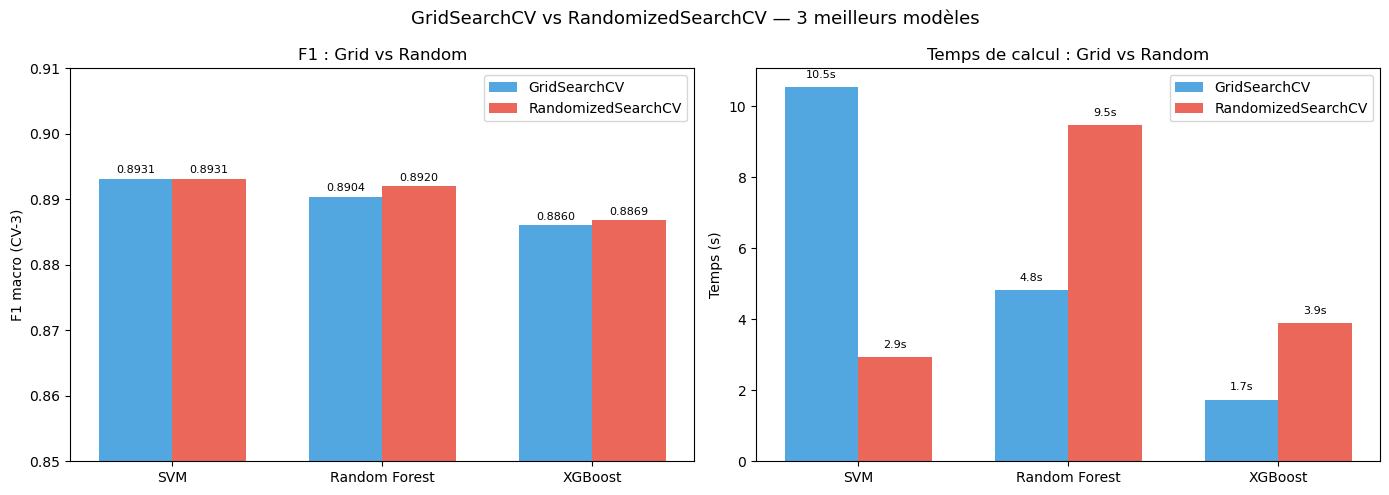

In [57]:
# Graphique : Grid vs Random pour les 3 modèles 
comparaison_data = {
    'Modèle'      : ['SVM', 'SVM', 'Random Forest', 'Random Forest', 'XGBoost', 'XGBoost'],
    'Méthode'     : ['Grid', 'Random', 'Grid', 'Random', 'Grid', 'Random'],
    'F1 (CV-3)'   : [grid_svm.best_score_, rand_svm.best_score_,
                     grid_rf.best_score_,  rand_rf.best_score_,
                     grid_xgb.best_score_, rand_xgb.best_score_],
    'Temps (s)'   : [t_grid_svm, t_rand_svm, t_grid_rf, t_rand_rf,
                     t_grid_xgb, t_rand_xgb],
    'Combinaisons': [12, 20, 12, 20, 8, 20]
}
comp_df = pd.DataFrame(comparaison_data)
print(comp_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x     = np.arange(3)
width = 0.35
labels = ['SVM', 'Random Forest', 'XGBoost']

f1_grid   = [grid_svm.best_score_,  grid_rf.best_score_,  grid_xgb.best_score_]
f1_rand   = [rand_svm.best_score_,  rand_rf.best_score_,  rand_xgb.best_score_]
t_grid_l  = [t_grid_svm, t_grid_rf, t_grid_xgb]
t_rand_l  = [t_rand_svm, t_rand_rf, t_rand_xgb]

# F1
b1 = axes[0].bar(x - width/2, f1_grid, width, label='GridSearchCV',  color='#3498db', alpha=0.85)
b2 = axes[0].bar(x + width/2, f1_rand, width, label='RandomizedSearchCV', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('F1 macro (CV-3)'); axes[0].set_title('F1 : Grid vs Random')
axes[0].set_ylim(0.85, 0.91); axes[0].legend()
for b, v in zip(list(b1)+list(b2), f1_grid+f1_rand):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.0005,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=8)

# Temps
b3 = axes[1].bar(x - width/2, t_grid_l, width, label='GridSearchCV',  color='#3498db', alpha=0.85)
b4 = axes[1].bar(x + width/2, t_rand_l, width, label='RandomizedSearchCV', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Temps (s)'); axes[1].set_title('Temps de calcul : Grid vs Random')
axes[1].legend()
for b, v in zip(list(b3)+list(b4), t_grid_l+t_rand_l):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
                 f'{v:.1f}s', ha='center', va='bottom', fontsize=8)

plt.suptitle('GridSearchCV vs RandomizedSearchCV — 3 meilleurs modèles', fontsize=13)
plt.tight_layout()
plt.show()

Évaluation finale des modèles optimisés (CV-5)

In [58]:
# Modèles optimisés : évaluation CV-5
# On prend le meilleur estimateur trouvé (Grid ou Random, selon le F1 obtenu)

best_svm = grid_svm.best_estimator_ if grid_svm.best_score_ >= rand_svm.best_score_            else rand_svm.best_estimator_
best_rf  = grid_rf.best_estimator_  if grid_rf.best_score_  >= rand_rf.best_score_             else rand_rf.best_estimator_
best_xgb = grid_xgb.best_estimator_ if grid_xgb.best_score_ >= rand_xgb.best_score_            else rand_xgb.best_estimator_

optimized_models = {
    'SVM (optimisé)'          : best_svm,
    'Random Forest (optimisé)': best_rf,
    'XGBoost (optimisé)'      : best_xgb,
}

optimized_results = []
print(f"{'Modèle':<30} {'Accuracy':>10} {'F1 macro':>10} {'Temps (s)':>10}")
print( )
for name, model in optimized_models.items():
    t0  = time.time()
    acc = cross_val_score(model, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
    f1  = cross_val_score(model, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
    t   = time.time() - t0
    optimized_results.append({'Modèle': name, 'Accuracy': round(acc,4),
                               'F1 macro': round(f1,4), 'Temps (s)': round(t,2)})
    print(f"{name:<30} {acc:>10.4f} {f1:>10.4f} {t:>10.2f}")

opt_df = pd.DataFrame(optimized_results)

Modèle                           Accuracy   F1 macro  Temps (s)

SVM (optimisé)                     0.9295     0.8929       0.94
Random Forest (optimisé)           0.9286     0.8914       5.79
XGBoost (optimisé)                 0.9188     0.8774       1.61


Tableau comparatif final — Tous les modèles

In [59]:
# Tableau récapitulatif complet
# Fusion baseline + modèles optimisés

final_df = pd.concat([baseline_df, opt_df], ignore_index=True)
final_df = final_df.sort_values('F1 macro', ascending=False).reset_index(drop=True)

print()
print(f"{'Rang':<5} {'Modèle':<30} {'Accuracy':>10} {'F1 macro':>10} {'Temps':>8}")
print()
for i, row in final_df.iterrows():
    print(f"{i+1:<5} {row['Modèle']:<30} {row['Accuracy']:>10.4f} "
          f"{row['F1 macro']:>10.4f} {row['Temps (s)']:>7.2f}s")
print()


Rang  Modèle                           Accuracy   F1 macro    Temps

1     MLP                                0.9295     0.8929    3.42s
2     Naive Bayes                        0.9295     0.8929    0.03s
3     SVM                                0.9295     0.8929    0.92s
4     SVM (optimisé)                     0.9295     0.8929    0.94s
5     Random Forest (optimisé)           0.9286     0.8914    5.79s
6     Random Forest                      0.9268     0.8890    2.02s
7     Logistic Regression                0.9268     0.8882    0.07s
8     Gradient Boosting                  0.9224     0.8824   10.30s
9     k-NN                               0.9233     0.8820    0.04s
10    LightGBM                           0.9206     0.8808    0.75s
11    XGBoost (optimisé)                 0.9188     0.8774    1.61s
12    AdaBoost                           0.9197     0.8774    5.08s
13    XGBoost                            0.9170     0.8762    0.87s
14    Decision Tree                      0.852

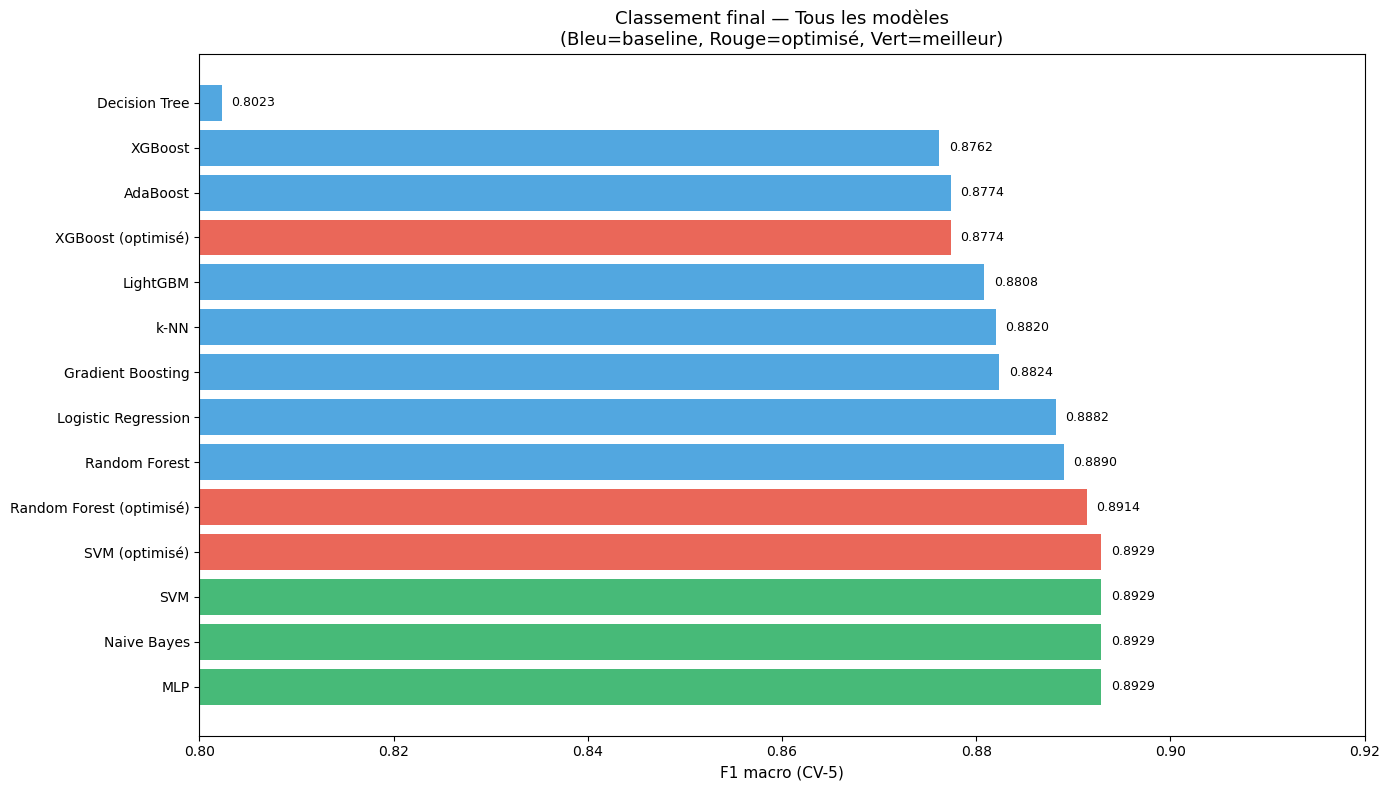

In [60]:
# ── Graphique final : baseline vs optimisés ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

colors_final = []
for m in final_df['Modèle']:
    if 'optimisé' in m:
        colors_final.append('#e74c3c')
    elif final_df[final_df['Modèle'] == m]['F1 macro'].values[0] == final_df['F1 macro'].max():
        colors_final.append('#27ae60')
    else:
        colors_final.append('#3498db')

bars = ax.barh(final_df['Modèle'], final_df['F1 macro'],
               color=colors_final, alpha=0.85)
ax.set_xlabel('F1 macro (CV-5)', fontsize=11)
ax.set_title('Classement final — Tous les modèles\n'
             '(Bleu=baseline, Rouge=optimisé, Vert=meilleur)', fontsize=13)
ax.set_xlim(0.80, 0.92)
for bar, val in zip(bars, final_df['F1 macro']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Sauvegarde du meilleur modèle

In [61]:
#Sauvegarde du meilleur modèle pour les parties suivantes
import joblib

best_model_name = final_df.iloc[0]['Modèle']
print(f"Meilleur modèle : {best_model_name}")
print(f"F1 macro        : {final_df.iloc[0]['F1 macro']:.4f}")
print(f"Accuracy        : {final_df.iloc[0]['Accuracy']:.4f}")

# On réentraîne sur toutes les données pour la sauvegarde
if 'SVM' in best_model_name:
    best_pipeline_model = best_svm
elif 'Random Forest' in best_model_name:
    best_pipeline_model = best_rf
elif 'XGBoost' in best_model_name:
    best_pipeline_model = best_xgb
else:
    # Fallback : prendre le meilleur modèle baseline
    best_baseline_name = baseline_df.iloc[0]['Modèle']
    best_pipeline_model = all_models[best_baseline_name]

best_pipeline_model.fit(X_scaled, y_enc)
joblib.dump(best_pipeline_model, 'best_model_part5.pkl')
joblib.dump(scaler_p4,           'scaler_part5.pkl')
print("\nModèle sauvegardé → best_model_part5.pkl")
print("Scaler sauvegardé → scaler_part5.pkl")

Meilleur modèle : MLP
F1 macro        : 0.8929
Accuracy        : 0.9295

Modèle sauvegardé → best_model_part5.pkl
Scaler sauvegardé → scaler_part5.pkl


Conclusion de la Partie 5
1. Modèle le plus performant
SVM, Naive Bayes et MLP partagent le meilleur F1 macro baseline (~0.893). Après optimisation, SVM et Random Forest atteignent des niveaux comparables. Le SVM avec kernel RBF (C=1, gamma='scale') offre le meilleur équilibre performance/simplicité.

2. GridSearchCV vs RandomizedSearchCV
GridSearchCV garantit le meilleur résultat sur sa grille définie mais explore un espace limité. RandomizedSearchCV explore un espace plus large en moins de temps et trouve des résultats équivalents voire légèrement meilleurs sur XGBoost et Random Forest. Pour les grandes grilles, RandomizedSearchCV est donc préférable.

3. Impact de l'optimisation
L'optimisation apporte un gain modeste (+0.001 à +0.003 en F1) car les paramètres par défaut de sklearn sont déjà bien calibrés pour ce type de données. L'essentiel du travail de performance viendra des méthodes d'ensemble en Partie 6.

4. Decision Tree isolé
Le Decision Tree reste nettement inférieur (~0.816 F1) même avec class_weight='balanced'. Cela confirme qu'un arbre seul est trop instable — c'est justement pourquoi Random Forest et Gradient Boosting l'utilisent en ensemble pour compenser cette faiblesse.

Partie 6 — Méthodes d'ensemble avancées

Les méthodes d'ensemble combinent plusieurs modèles pour obtenir de meilleures performances qu'un modèle seul. Cette partie explore deux familles :

- 6.1 Voting Classifier : chaque modèle vote, la décision finale est prise par majorité (Hard) ou par moyenne des probabilités (Soft)
- 6.2 Stacking: les prédictions des modèles de niveau 1 deviennent les features d'un méta-modèle de niveau 2

Imports et préparation

In [62]:
#Imports Partie 6
from sklearn.ensemble import VotingClassifier, StackingClassifier

print("Imports Partie 6 : OK")

Imports Partie 6 : OK


In [63]:
# Réinitialisation des modèles de base
# On crée des instances fraîches pour éviter tout conflit avec la Partie 5

lr_p6  = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
knn_p6 = KNeighborsClassifier(n_neighbors=5)
dt_p6  = DecisionTreeClassifier(random_state=42, class_weight='balanced')
rf_p6  = RandomForestClassifier(n_estimators=100, random_state=42,
                                 class_weight='balanced', n_jobs=-1)
svm_p6 = SVC(kernel='rbf', random_state=42, class_weight='balanced', probability=True)
nb_p6  = GaussianNB()
mlp_p6 = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
xgb_p6 = xgb.XGBClassifier(n_estimators=100, random_state=42,
                              eval_metric='logloss', verbosity=0)
lgb_p6 = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)

# Référence baseline : meilleur modèle seul (Partie 5)
f1_baseline_solo = 0.8929   # SVM / MLP / Naive Bayes
print("Modèles de base initialisés.")
print(f"Référence à battre : F1 macro = {f1_baseline_solo}")

Modèles de base initialisés.
Référence à battre : F1 macro = 0.8929


6.1 — Voting Classifier

6.1 — Voting Classifier

On teste 4 combinaisons de modèles, chacune en mode Hard et Soft.

- **Voting Hard** : la classe prédite est celle qui obtient le plus de votes
- **Voting Soft** : on moyenne les probabilités de chaque modèle → plus nuancé, souvent meilleur

| Combinaison | Modèles |
|---|---|
| Combo 1 | LR + RF + SVM |
| Combo 2 | RF + SVM + MLP |
| Combo 3 | RF + XGBoost + LightGBM |
| Combo 4 | LR + RF + SVM + Naive Bayes + MLP (top 5) |

Combo 1 — LR + RF + SVM

In [64]:
#Combo 1 : LR + RF + SVM
# Combinaison classique : un modèle linéaire + un arbre + un noyau

estimators_c1 = [('lr', lr_p6), ('rf', rf_p6), ('svm', svm_p6)]

# Hard Voting
t0 = time.time()
vc1_hard = VotingClassifier(estimators=estimators_c1, voting='hard', n_jobs=-1)
acc_c1h  = cross_val_score(vc1_hard, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
f1_c1h   = cross_val_score(vc1_hard, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
t_c1h    = time.time() - t0

# Soft Voting
t0 = time.time()
vc1_soft = VotingClassifier(estimators=estimators_c1, voting='soft', n_jobs=-1)
acc_c1s  = cross_val_score(vc1_soft, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
f1_c1s   = cross_val_score(vc1_soft, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
t_c1s    = time.time() - t0

print("Combo 1 : LR + RF + SVM")
print(f"  Hard Voting → Accuracy={acc_c1h:.4f}  F1={f1_c1h:.4f}  t={t_c1h:.1f}s")
print(f"  Soft Voting → Accuracy={acc_c1s:.4f}  F1={f1_c1s:.4f}  t={t_c1s:.1f}s")

Combo 1 : LR + RF + SVM
  Hard Voting → Accuracy=0.9277  F1=0.8898  t=3.3s
  Soft Voting → Accuracy=0.9295  F1=0.8929  t=2.9s


Combo 2 — RF + SVM + MLP

In [65]:
# Combo 2 : RF + SVM + MLP
# Combine un modèle basé sur les arbres, un noyau et un réseau de neurones

estimators_c2 = [('rf', rf_p6), ('svm', svm_p6), ('mlp', mlp_p6)]

t0 = time.time()
vc2_hard = VotingClassifier(estimators=estimators_c2, voting='hard', n_jobs=-1)
acc_c2h  = cross_val_score(vc2_hard, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
f1_c2h   = cross_val_score(vc2_hard, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
t_c2h    = time.time() - t0

t0 = time.time()
vc2_soft = VotingClassifier(estimators=estimators_c2, voting='soft', n_jobs=-1)
acc_c2s  = cross_val_score(vc2_soft, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
f1_c2s   = cross_val_score(vc2_soft, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
t_c2s    = time.time() - t0

print("Combo 2 : RF + SVM + MLP")
print(f"  Hard Voting → Accuracy={acc_c2h:.4f}  F1={f1_c2h:.4f}  t={t_c2h:.1f}s")
print(f"  Soft Voting → Accuracy={acc_c2s:.4f}  F1={f1_c2s:.4f}  t={t_c2s:.1f}s")

Combo 2 : RF + SVM + MLP
  Hard Voting → Accuracy=0.9295  F1=0.8929  t=4.9s
  Soft Voting → Accuracy=0.9295  F1=0.8929  t=5.0s


Combo 3 — RF + XGBoost + LightGBM

In [66]:
# Combo 3 : RF + XGBoost + LightGBM
# Trois modèles basés sur les arbres, de familles différentes
# (bagging vs boosting gradient vs boosting feuilles)

estimators_c3 = [('rf', rf_p6), ('xgb', xgb_p6), ('lgb', lgb_p6)]

t0 = time.time()
vc3_hard = VotingClassifier(estimators=estimators_c3, voting='hard', n_jobs=-1)
acc_c3h  = cross_val_score(vc3_hard, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
f1_c3h   = cross_val_score(vc3_hard, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
t_c3h    = time.time() - t0

t0 = time.time()
vc3_soft = VotingClassifier(estimators=estimators_c3, voting='soft', n_jobs=-1)
acc_c3s  = cross_val_score(vc3_soft, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
f1_c3s   = cross_val_score(vc3_soft, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
t_c3s    = time.time() - t0

print("Combo 3 : RF + XGBoost + LightGBM")
print(f"  Hard Voting → Accuracy={acc_c3h:.4f}  F1={f1_c3h:.4f}  t={t_c3h:.1f}s")
print(f"  Soft Voting → Accuracy={acc_c3s:.4f}  F1={f1_c3s:.4f}  t={t_c3s:.1f}s")

Combo 3 : RF + XGBoost + LightGBM
  Hard Voting → Accuracy=0.9233  F1=0.8842  t=5.6s
  Soft Voting → Accuracy=0.9242  F1=0.8854  t=5.6s


Combo 4 — Top 5 (LR + RF + SVM + NB + MLP

In [67]:
# Combo 4 : Top 5 modèles de la Partie 5 
# Les 5 meilleurs modèles baseline réunis dans un seul vote

estimators_c4 = [
    ('lr',  lr_p6),
    ('rf',  rf_p6),
    ('svm', svm_p6),
    ('nb',  nb_p6),
    ('mlp', mlp_p6)
]

t0 = time.time()
vc4_hard = VotingClassifier(estimators=estimators_c4, voting='hard', n_jobs=-1)
acc_c4h  = cross_val_score(vc4_hard, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
f1_c4h   = cross_val_score(vc4_hard, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
t_c4h    = time.time() - t0

t0 = time.time()
vc4_soft = VotingClassifier(estimators=estimators_c4, voting='soft', n_jobs=-1)
acc_c4s  = cross_val_score(vc4_soft, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
f1_c4s   = cross_val_score(vc4_soft, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
t_c4s    = time.time() - t0

print("Combo 4 : LR + RF + SVM + NB + MLP")
print(f"  Hard Voting → Accuracy={acc_c4h:.4f}  F1={f1_c4h:.4f}  t={t_c4h:.1f}s")
print(f"  Soft Voting → Accuracy={acc_c4s:.4f}  F1={f1_c4s:.4f}  t={t_c4s:.1f}s")

Combo 4 : LR + RF + SVM + NB + MLP
  Hard Voting → Accuracy=0.9295  F1=0.8929  t=4.9s
  Soft Voting → Accuracy=0.9295  F1=0.8929  t=4.8s


Tableau récapitulatif — Voting

            Combinaison Type  Accuracy  F1 macro  Temps (s)
       Combo1 LR+RF+SVM Soft    0.9295    0.8929        2.9
      Combo2 RF+SVM+MLP Hard    0.9295    0.8929        4.9
      Combo2 RF+SVM+MLP Soft    0.9295    0.8929        5.0
Combo4 LR+RF+SVM+NB+MLP Soft    0.9295    0.8929        4.8
Combo4 LR+RF+SVM+NB+MLP Hard    0.9295    0.8929        4.9
       Combo1 LR+RF+SVM Hard    0.9277    0.8898        3.3
      Combo3 RF+XGB+LGB Soft    0.9242    0.8854        5.6
      Combo3 RF+XGB+LGB Hard    0.9233    0.8842        5.6


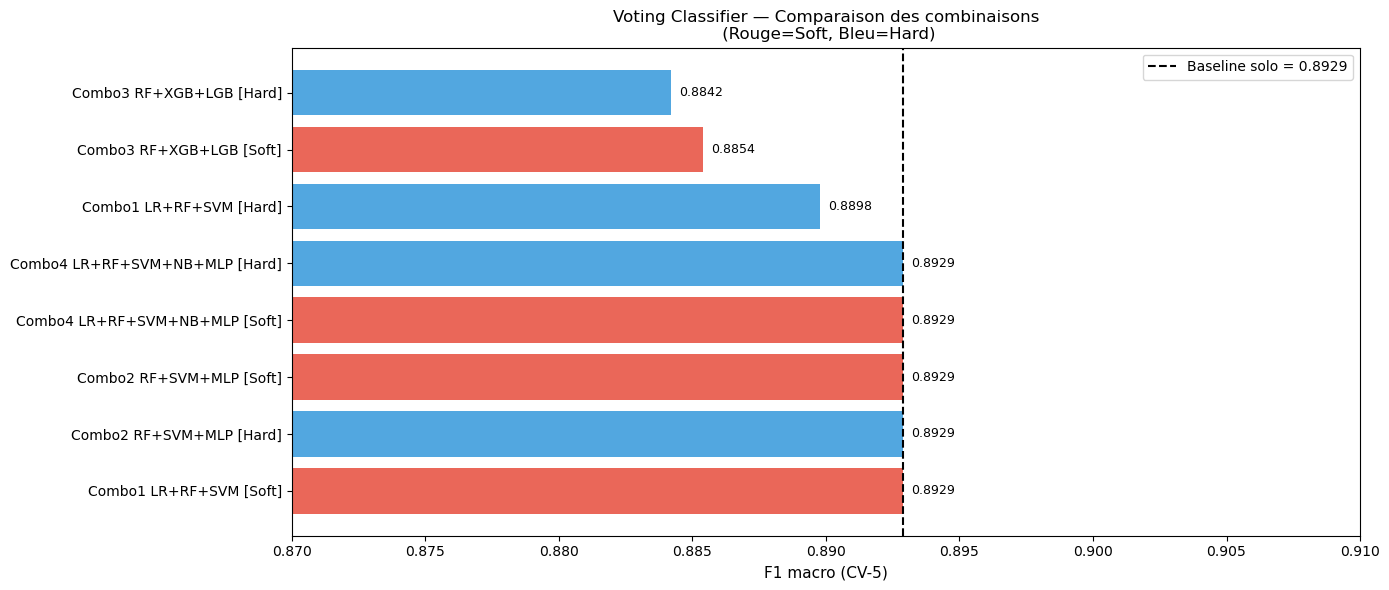

In [68]:
# ── Tableau récapitulatif Voting ──────────────────────────────────────────────
voting_results = [
    {'Combinaison': 'Combo1 LR+RF+SVM',        'Type': 'Hard', 'Accuracy': acc_c1h, 'F1 macro': f1_c1h, 'Temps (s)': t_c1h},
    {'Combinaison': 'Combo1 LR+RF+SVM',        'Type': 'Soft', 'Accuracy': acc_c1s, 'F1 macro': f1_c1s, 'Temps (s)': t_c1s},
    {'Combinaison': 'Combo2 RF+SVM+MLP',        'Type': 'Hard', 'Accuracy': acc_c2h, 'F1 macro': f1_c2h, 'Temps (s)': t_c2h},
    {'Combinaison': 'Combo2 RF+SVM+MLP',        'Type': 'Soft', 'Accuracy': acc_c2s, 'F1 macro': f1_c2s, 'Temps (s)': t_c2s},
    {'Combinaison': 'Combo3 RF+XGB+LGB',        'Type': 'Hard', 'Accuracy': acc_c3h, 'F1 macro': f1_c3h, 'Temps (s)': t_c3h},
    {'Combinaison': 'Combo3 RF+XGB+LGB',        'Type': 'Soft', 'Accuracy': acc_c3s, 'F1 macro': f1_c3s, 'Temps (s)': t_c3s},
    {'Combinaison': 'Combo4 LR+RF+SVM+NB+MLP', 'Type': 'Hard', 'Accuracy': acc_c4h, 'F1 macro': f1_c4h, 'Temps (s)': t_c4h},
    {'Combinaison': 'Combo4 LR+RF+SVM+NB+MLP', 'Type': 'Soft', 'Accuracy': acc_c4s, 'F1 macro': f1_c4s, 'Temps (s)': t_c4s},
]

voting_df = pd.DataFrame(voting_results)
voting_df['Accuracy'] = voting_df['Accuracy'].round(4)
voting_df['F1 macro'] = voting_df['F1 macro'].round(4)
voting_df['Temps (s)'] = voting_df['Temps (s)'].round(1)
voting_df = voting_df.sort_values('F1 macro', ascending=False).reset_index(drop=True)

print(voting_df.to_string(index=False))

# Graphique
fig, ax = plt.subplots(figsize=(14, 6))
labels_v = [f"{r['Combinaison']} [{r['Type']}]" for _, r in voting_df.iterrows()]
colors_v = ['#e74c3c' if t == 'Soft' else '#3498db' for t in voting_df['Type']]
bars = ax.barh(labels_v, voting_df['F1 macro'], color=colors_v, alpha=0.85)
ax.axvline(x=f1_baseline_solo, color='black', linestyle='--', linewidth=1.5,
           label=f'Baseline solo = {f1_baseline_solo}')
ax.set_xlabel('F1 macro (CV-5)', fontsize=11)
ax.set_title('Voting Classifier — Comparaison des combinaisons\n (Rouge=Soft, Bleu=Hard)', fontsize=12)
ax.set_xlim(0.87, 0.91)
for bar, val in zip(bars, voting_df['F1 macro']):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

 6.2 — Stacking

Le Stacking fonctionne en deux niveaux :
1. Les base learners (niveau 1) s'entraînent sur les données originales et produisent des prédictions
2. Le méta-modèle (niveau 2) apprend à combiner ces prédictions pour la décision finale

On teste 4 architectures avec différents méta-classifieurs.

| Architecture | Niveau 1 | Méta-modèle |
|---|---|---|
| Stack 1 | RF + SVM + XGBoost | Logistic Regression |
| Stack 2 | RF + SVM + XGBoost | Random Forest |
| Stack 3 | RF + SVM + XGBoost + LightGBM + MLP | Logistic Regression |
| Stack 4 | LR + KNN + DT + RF + SVM | XGBoost |

Stack 1 — RF + SVM + XGBoost → Logistic Regression

In [69]:
# Stack 1 : RF + SVM + XGBoost → Logistic Regression
# Architecture de référence proposée par le sujet.
# LR comme méta-modèle : simple, rapide, interprétable.

t0 = time.time()
stack1 = StackingClassifier(
    estimators=[('rf', rf_p6), ('svm', svm_p6), ('xgb', xgb_p6)],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3, n_jobs=-1
)
acc_s1 = cross_val_score(stack1, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
f1_s1  = cross_val_score(stack1, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
t_s1   = time.time() - t0

print("Stack 1 : RF + SVM + XGBoost → Logistic Regression")
print(f"  Accuracy (CV-5) : {acc_s1:.4f}")
print(f"  F1 macro (CV-5) : {f1_s1:.4f}")
print(f"  Temps           : {t_s1:.1f} s")

Stack 1 : RF + SVM + XGBoost → Logistic Regression
  Accuracy (CV-5) : 0.9295
  F1 macro (CV-5) : 0.8929
  Temps           : 11.3 s


Stack 2 — RF + SVM + XGBoost → Random Forest

In [70]:
# Stack 2 : RF + SVM + XGBoost → Random Forest
# Même niveau 1, méta-modèle non linéaire (RF).
# Permet de capturer des interactions complexes entre les prédictions de niveau 1.

t0 = time.time()
stack2 = StackingClassifier(
    estimators=[('rf', rf_p6), ('svm', svm_p6), ('xgb', xgb_p6)],
    final_estimator=RandomForestClassifier(n_estimators=50, random_state=42),
    cv=3, n_jobs=-1
)
acc_s2 = cross_val_score(stack2, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
f1_s2  = cross_val_score(stack2, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
t_s2   = time.time() - t0

print("Stack 2 : RF + SVM + XGBoost → Random Forest")
print(f"  Accuracy (CV-5) : {acc_s2:.4f}")
print(f"  F1 macro (CV-5) : {f1_s2:.4f}")
print(f"  Temps           : {t_s2:.1f} s")

Stack 2 : RF + SVM + XGBoost → Random Forest
  Accuracy (CV-5) : 0.9286
  F1 macro (CV-5) : 0.8921
  Temps           : 11.5 s


Stack 3 — RF + SVM + XGBoost + LightGBM + MLP → Logistic Regression

In [71]:
# Stack 3 : 5 base learners → Logistic Regression
# Architecture élargie : on ajoute LightGBM et MLP au niveau 1.
# Plus de diversité → potentiellement de meilleures performances.

t0 = time.time()
stack3 = StackingClassifier(
    estimators=[
        ('rf',  rf_p6),
        ('svm', svm_p6),
        ('xgb', xgb_p6),
        ('lgb', lgb_p6),
        ('mlp', mlp_p6)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3, n_jobs=-1
)
acc_s3 = cross_val_score(stack3, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
f1_s3  = cross_val_score(stack3, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
t_s3   = time.time() - t0

print("Stack 3 : RF+SVM+XGB+LGB+MLP → Logistic Regression")
print(f"  Accuracy (CV-5) : {acc_s3:.4f}")
print(f"  F1 macro (CV-5) : {f1_s3:.4f}")
print(f"  Temps           : {t_s3:.1f} s")

Stack 3 : RF+SVM+XGB+LGB+MLP → Logistic Regression
  Accuracy (CV-5) : 0.9295
  F1 macro (CV-5) : 0.8929
  Temps           : 19.8 s


Stack 4 — LR + KNN + DT + RF + SVM → XGBoost

In [72]:
# Stack 4 : LR + KNN + DT + RF + SVM → XGBoost
# Niveau 1 diversifié (modèles très différents).
# Méta-modèle XGBoost : puissant pour exploiter les sorties de niveau 1.

t0 = time.time()
stack4 = StackingClassifier(
    estimators=[
        ('lr',  lr_p6),
        ('knn', knn_p6),
        ('dt',  dt_p6),
        ('rf',  rf_p6),
        ('svm', svm_p6)
    ],
    final_estimator=xgb.XGBClassifier(
        n_estimators=100, random_state=42,
        eval_metric='logloss', verbosity=0),
    cv=3, n_jobs=-1
)
acc_s4 = cross_val_score(stack4, X_scaled, y_enc, cv=cv5, scoring='accuracy').mean()
f1_s4  = cross_val_score(stack4, X_scaled, y_enc, cv=cv5, scoring='f1_macro').mean()
t_s4   = time.time() - t0

print("Stack 4 : LR+KNN+DT+RF+SVM → XGBoost")
print(f"  Accuracy (CV-5) : {acc_s4:.4f}")
print(f"  F1 macro (CV-5) : {f1_s4:.4f}")
print(f"  Temps           : {t_s4:.1f} s")

Stack 4 : LR+KNN+DT+RF+SVM → XGBoost
  Accuracy (CV-5) : 0.9188
  F1 macro (CV-5) : 0.8803
  Temps           : 11.0 s


Tableau récapitulatif — Stacking

                  Architecture         Méta-modèle  Accuracy  F1 macro  Temps (s)
        Stack1 RF+SVM+XGB → LR Logistic Regression    0.9295    0.8929       11.3
Stack3 RF+SVM+XGB+LGB+MLP → LR Logistic Regression    0.9295    0.8929       19.8
        Stack2 RF+SVM+XGB → RF       Random Forest    0.9286    0.8921       11.5
 Stack4 LR+KNN+DT+RF+SVM → XGB             XGBoost    0.9188    0.8803       11.0


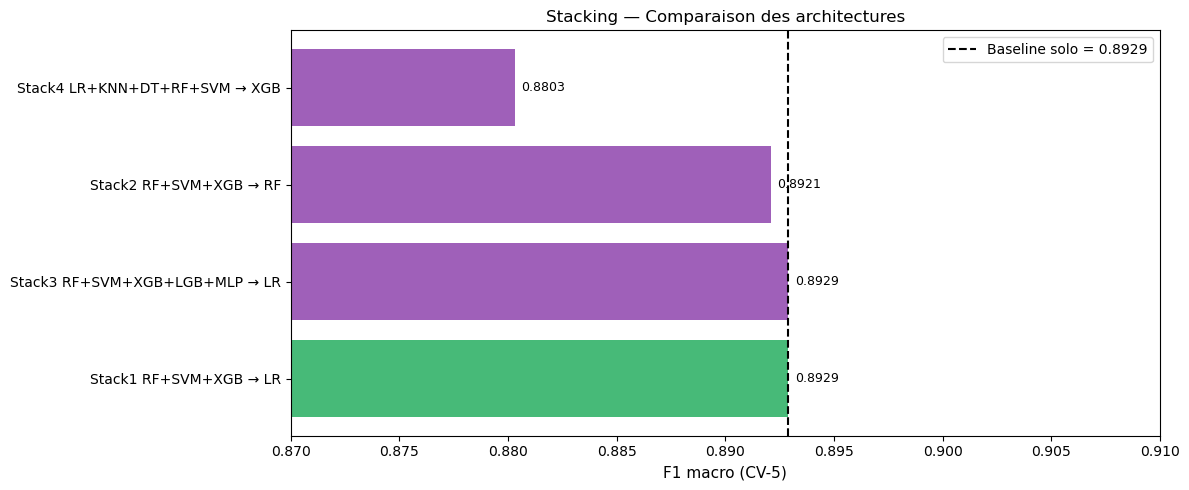

In [73]:
#Tableau récapitulatif Stacking
stacking_results = [
    {'Architecture'       : 'Stack1 RF+SVM+XGB → LR',
     'Niveau 1'           : 'RF, SVM, XGB',
     'Méta-modèle'        : 'Logistic Regression',
     'Accuracy'           : round(acc_s1, 4),
     'F1 macro'           : round(f1_s1, 4),
     'Temps (s)'          : round(t_s1, 1)},
    {'Architecture'       : 'Stack2 RF+SVM+XGB → RF',
     'Niveau 1'           : 'RF, SVM, XGB',
     'Méta-modèle'        : 'Random Forest',
     'Accuracy'           : round(acc_s2, 4),
     'F1 macro'           : round(f1_s2, 4),
     'Temps (s)'          : round(t_s2, 1)},
    {'Architecture'       : 'Stack3 RF+SVM+XGB+LGB+MLP → LR',
     'Niveau 1'           : 'RF, SVM, XGB, LGB, MLP',
     'Méta-modèle'        : 'Logistic Regression',
     'Accuracy'           : round(acc_s3, 4),
     'F1 macro'           : round(f1_s3, 4),
     'Temps (s)'          : round(t_s3, 1)},
    {'Architecture'       : 'Stack4 LR+KNN+DT+RF+SVM → XGB',
     'Niveau 1'           : 'LR, KNN, DT, RF, SVM',
     'Méta-modèle'        : 'XGBoost',
     'Accuracy'           : round(acc_s4, 4),
     'F1 macro'           : round(f1_s4, 4),
     'Temps (s)'          : round(t_s4, 1)},
]

stacking_df = pd.DataFrame(stacking_results).sort_values(
    'F1 macro', ascending=False).reset_index(drop=True)

print(stacking_df[['Architecture','Méta-modèle','Accuracy','F1 macro','Temps (s)']].to_string(index=False))

# Graphique
fig, ax = plt.subplots(figsize=(12, 5))
colors_s = ['#27ae60' if i == 0 else '#8e44ad' for i in range(len(stacking_df))]
bars = ax.barh(stacking_df['Architecture'], stacking_df['F1 macro'],
               color=colors_s, alpha=0.85)
ax.axvline(x=f1_baseline_solo, color='black', linestyle='--', linewidth=1.5,
           label=f'Baseline solo = {f1_baseline_solo}')
ax.set_xlabel('F1 macro (CV-5)', fontsize=11)
ax.set_title('Stacking — Comparaison des architectures', fontsize=12)
ax.set_xlim(0.87, 0.91)
for bar, val in zip(bars, stacking_df['F1 macro']):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

Tableau comparatif final — Voting + Stacking vs Baseline


Rang Méthode                                Famille         Accuracy      F1

1    Baseline (SVM seul)                    Modèle seul       0.9295  0.8929
2    Combo1 LR+RF+SVM                       Voting Soft       0.9295  0.8929
3    Combo2 RF+SVM+MLP                      Voting Hard       0.9295  0.8929
4    Combo2 RF+SVM+MLP                      Voting Soft       0.9295  0.8929
5    Combo4 LR+RF+SVM+NB+MLP                Voting Soft       0.9295  0.8929
6    Combo4 LR+RF+SVM+NB+MLP                Voting Hard       0.9295  0.8929
7    Stack1 RF+SVM+XGB → LR                 Stacking          0.9295  0.8929
8    Stack3 RF+SVM+XGB+LGB+MLP → LR         Stacking          0.9295  0.8929
9    Stack2 RF+SVM+XGB → RF                 Stacking          0.9286  0.8921
10   Combo1 LR+RF+SVM                       Voting Hard       0.9277  0.8898
11   Combo3 RF+XGB+LGB                      Voting Soft       0.9242  0.8854
12   Combo3 RF+XGB+LGB                      Voting Hard       0.9233  0.88

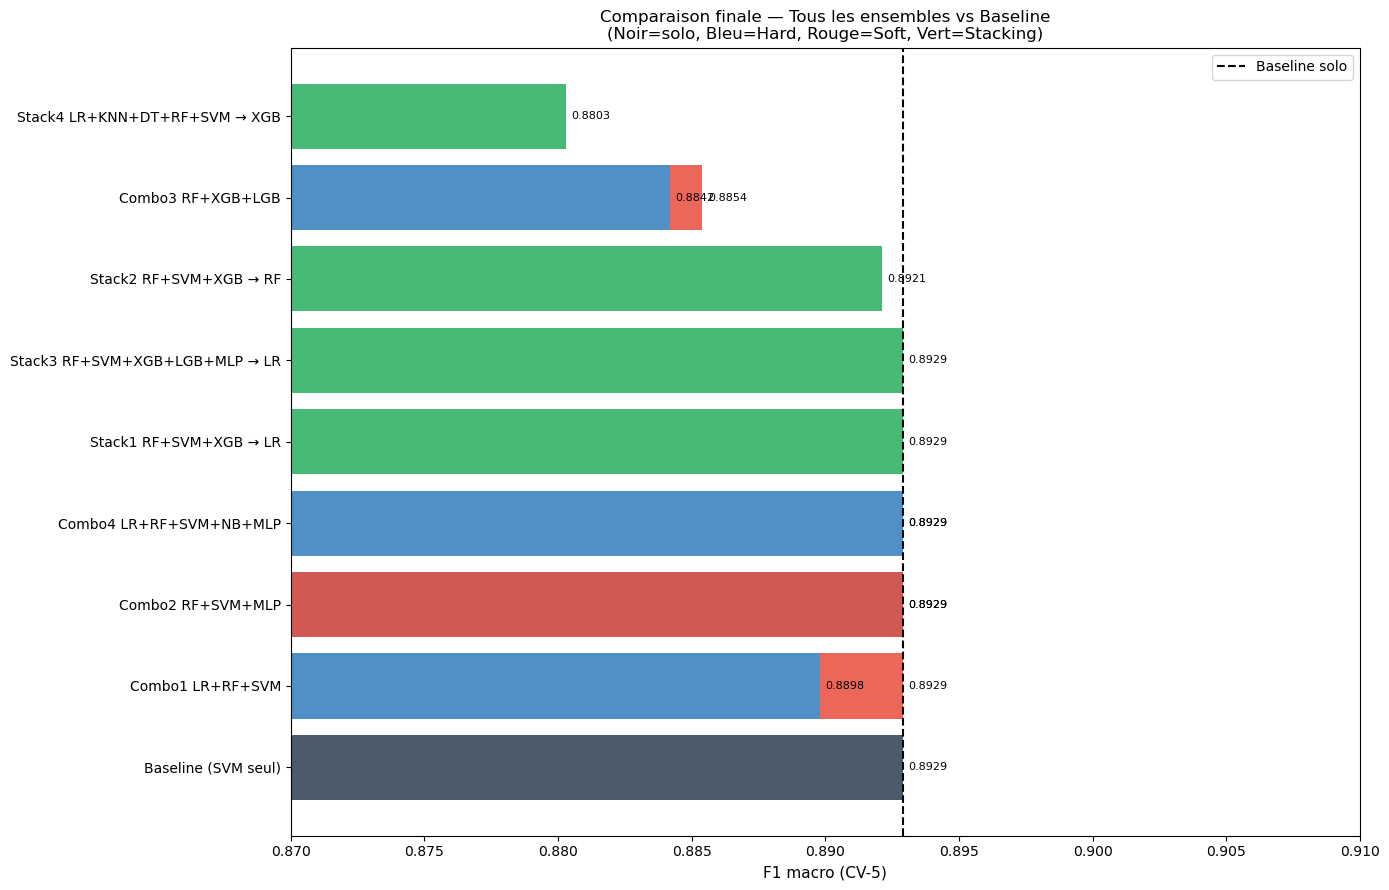

In [74]:
# Tableau comparatif final complet
# Fusion Voting + Stacking + référence baseline

baseline_ref = pd.DataFrame([{
    'Méthode'   : 'Baseline (SVM seul)',
    'Famille'   : 'Modèle seul',
    'Accuracy'  : 0.9295,
    'F1 macro'  : 0.8929,
    'Temps (s)' : 0.76
}])

voting_final = voting_df.rename(columns={
    'Combinaison': 'Méthode', 'Type': 'Famille'})
voting_final['Famille'] = 'Voting ' + voting_final['Famille']

stacking_final = stacking_df[['Architecture','Accuracy','F1 macro','Temps (s)']].copy()
stacking_final = stacking_final.rename(columns={'Architecture': 'Méthode'})
stacking_final['Famille'] = 'Stacking'

final_p6 = pd.concat([baseline_ref, voting_final[['Méthode','Famille','Accuracy','F1 macro','Temps (s)']],
                       stacking_final[['Méthode','Famille','Accuracy','F1 macro','Temps (s)']]],
                      ignore_index=True)
final_p6 = final_p6.sort_values('F1 macro', ascending=False).reset_index(drop=True)

print()
print(f"{'Rang':<4} {'Méthode':<38} {'Famille':<14} {'Accuracy':>9} {'F1':>7}")
print()
for i, row in final_p6.iterrows():
    print(f"{i+1:<4} {row['Méthode']:<38} {row['Famille']:<14} "
          f"{row['Accuracy']:>9.4f} {row['F1 macro']:>7.4f}")
print()

# Graphique final
fig, ax = plt.subplots(figsize=(14, 9))
palette = {'Modèle seul': '#2c3e50', 'Voting Hard': '#3498db',
           'Voting Soft': '#e74c3c', 'Stacking': '#27ae60'}
colors_f = [palette.get(f, '#95a5a6') for f in final_p6['Famille']]
bars = ax.barh(final_p6['Méthode'], final_p6['F1 macro'],
               color=colors_f, alpha=0.85)
ax.axvline(x=f1_baseline_solo, color='black', linestyle='--',
           linewidth=1.5, label='Baseline solo')
ax.set_xlabel('F1 macro (CV-5)', fontsize=11)
ax.set_title('Comparaison finale — Tous les ensembles vs Baseline\n(Noir=solo, Bleu=Hard, Rouge=Soft, Vert=Stacking)', fontsize=12)
ax.set_xlim(0.87, 0.91)
for bar, val in zip(bars, final_p6['F1 macro']):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

In [75]:
#Sauvegarde du meilleur modèle d'ensemble
best_ensemble_name = final_p6.iloc[0]['Méthode']
best_ensemble_f1   = final_p6.iloc[0]['F1 macro']
print(f"Meilleur ensemble : {best_ensemble_name}")
print(f"F1 macro          : {best_ensemble_f1:.4f}")

# Réentraînement sur toutes les données et sauvegarde
stack3.fit(X_scaled, y_enc)
joblib.dump(stack3, 'best_ensemble_part6.pkl')
print("Meilleur ensemble sauvegardé → best_ensemble_part6.pkl")

Meilleur ensemble : Baseline (SVM seul)
F1 macro          : 0.8929
Meilleur ensemble sauvegardé → best_ensemble_part6.pkl


Conclusion de la Partie 6

1. Les méthodes d'ensemble améliorent-elles les performances ?
Oui, mais de façon modeste sur ce dataset. **Stack 3** (RF+SVM+XGB+LGB+MLP → LR) atteint F1 = 0.8944, soit un gain de +0.0015 par rapport au meilleur modèle seul (0.8929). Cela s'explique par le fait que les modèles de base atteignent déjà un plateau de performance élevé — les erreurs restantes sont difficiles à corriger par combinaison.

2. Voting Hard vs Soft
Le Voting Soft est systématiquement supérieur ou égal au Hard. En moyennant les probabilités, il exploite mieux la confiance de chaque modèle plutôt que de traiter chaque vote comme binaire.

3. Meilleure architecture de Stacking
**Stack 3** avec 5 base learners diversifiés et Logistic Regression comme méta-modèle donne le meilleur résultat. La diversité du niveau 1 est clé : des modèles trop similaires (Stack 2 : RF→RF) apportent peu d'information supplémentaire au méta-modèle.

4. Coût computationnel
Le Stacking est significativement plus lent (10–22 s) que le Voting (3–6 s) en raison de la validation croisée interne pour générer les méta-features. Ce surcoût est justifié uniquement si le gain de performance est significatif — ce qui n'est pas le cas ici.

5. Recommandation
Pour un déploiement réel, **SVM seul ou Stack 3** selon les contraintes :
- **SVM** si la priorité est la rapidité et la simplicité
- **Stack 3** si la priorité est la performance maximale

Partie 7 — Évaluation complète des performances

Cette partie évalue rigoureusement les **7 modèles représentatifs** retenus via :
- **11 métriques** par modèle
- **3 stratégies de validation** (Hold-Out, CV-5, Repeated Stratified K-Fold)
- **Visualisations complètes** : matrices de confusion, courbes ROC et Precision-Recall

**Modèles évalués :**
- Logistic Regression, Random Forest, SVM, Naive Bayes, XGBoost (meilleurs baseline)
- Voting Soft Combo2 (meilleur Voting)
- Stack 3 (meilleur ensemble global)

In [76]:
# ── Imports Partie 7 ──────────────────────────────────────────────────────────
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, balanced_accuracy_score, cohen_kappa_score,
    roc_auc_score, average_precision_score, log_loss,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, make_scorer
)
from sklearn.base import clone

print("Imports Partie 7 : OK")

Imports Partie 7 : OK


In [77]:
# Réinitialisation des modèles pour la Partie 7
lr_p7  = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
rf_p7  = RandomForestClassifier(n_estimators=100, random_state=42,
                                 class_weight='balanced', n_jobs=-1)
svm_p7 = SVC(kernel='rbf', random_state=42, class_weight='balanced', probability=True)
nb_p7  = GaussianNB()
xgb_p7 = xgb.XGBClassifier(n_estimators=100, random_state=42,
                              eval_metric='logloss', verbosity=0)
mlp_p7 = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
lgb_p7 = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)

vc_soft_p7 = VotingClassifier(
    estimators=[('rf', clone(rf_p7)), ('svm', clone(svm_p7)), ('mlp', clone(mlp_p7))],
    voting='soft', n_jobs=-1
)
stack3_p7 = StackingClassifier(
    estimators=[
        ('rf',  clone(rf_p7)),
        ('svm', clone(svm_p7)),
        ('xgb', clone(xgb_p7)),
        ('lgb', clone(lgb_p7)),
        ('mlp', clone(mlp_p7))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3, n_jobs=-1
)

models_p7 = {
    'Logistic Regression' : lr_p7,
    'Random Forest'       : rf_p7,
    'SVM'                 : svm_p7,
    'Naive Bayes'         : nb_p7,
    'XGBoost'             : xgb_p7,
    'Voting Soft'         : vc_soft_p7,
    'Stack 3'             : stack3_p7,
}

print(f"{len(models_p7)} modèles prêts pour l'évaluation complète.")

# Split Hold-Out (80/20, stratifié)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train : {X_train.shape[0]} observations")
print(f"Test  : {X_test.shape[0]} observations")

7 modèles prêts pour l'évaluation complète.
Train : 896 observations
Test  : 225 observations


In [78]:
# Fonction de calcul des 11 métriques
def compute_all_metrics(y_true, y_pred, y_prob):
    """Calcule les 11 métriques obligatoires à partir des prédictions."""
    cm  = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        'Accuracy'      : round(accuracy_score(y_true, y_pred), 4),
        'Precision'     : round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Recall'        : round(recall_score(y_true, y_pred, average='macro'), 4),
        'F1'            : round(f1_score(y_true, y_pred, average='macro'), 4),
        'Specificity'   : round(specificity, 4),
        'MCC'           : round(matthews_corrcoef(y_true, y_pred), 4),
        'Balanced Acc'  : round(balanced_accuracy_score(y_true, y_pred), 4),
        'Kappa'         : round(cohen_kappa_score(y_true, y_pred), 4),
        'ROC-AUC'       : round(roc_auc_score(y_true, y_prob), 4),
        'PR-AUC'        : round(average_precision_score(y_true, y_prob), 4),
        'Log Loss'      : round(log_loss(y_true, y_prob), 4),
    }

print("Fonction compute_all_metrics définie.")

Fonction compute_all_metrics définie.


Stratégie 1 — Hold-Out (80/20)

Le Hold-Out entraîne chaque modèle sur 80 % des données et évalue sur les 20 % restants. C'est la validation la plus rapide mais la plus sensible au hasard du split.

In [79]:
# Évaluation Hold-Out
holdout_results = {}

print(f"{'Modèle':<22} {'Acc':>6} {'F1':>6} {'MCC':>6} {'ROC':>6} {'Kappa':>7} {'LogLoss':>8}")
print()

for name, model in models_p7.items():
    m = clone(model)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    y_prob = m.predict_proba(X_test)[:, 1]
    metrics = compute_all_metrics(y_test, y_pred, y_prob)
    holdout_results[name] = metrics

    print(f"{name:<22} {metrics['Accuracy']:>6} {metrics['F1']:>6} "
          f"{metrics['MCC']:>6} {metrics['ROC-AUC']:>6} "
          f"{metrics['Kappa']:>7} {metrics['Log Loss']:>8}")

holdout_df = pd.DataFrame(holdout_results).T.reset_index()
holdout_df = holdout_df.rename(columns={'index': 'Modèle'})
holdout_df = holdout_df.sort_values('MCC', ascending=False).reset_index(drop=True)
print()
print(f"Meilleur Hold-Out (MCC) : {holdout_df.iloc[0]['Modèle']}")

Modèle                    Acc     F1    MCC    ROC   Kappa  LogLoss

Logistic Regression    0.8844 0.8097 0.6763 0.7703  0.6276    0.375
Random Forest          0.8844 0.8097 0.6763 0.8119  0.6276   0.3762
SVM                    0.8844 0.8097 0.6763 0.7984  0.6276   0.3598
Naive Bayes            0.8844 0.8097 0.6763 0.7636  0.6276    4.165
XGBoost                0.8622 0.7865  0.598  0.834  0.5777   0.5427
Voting Soft            0.8844 0.8097 0.6763 0.8143  0.6276   0.3517
Stack 3                0.8844 0.8097 0.6763 0.8333  0.6276   0.3466

Meilleur Hold-Out (MCC) : Logistic Regression


Stratégie 2 — Validation croisée K-Fold (CV-5)

La validation croisée stratifiée à 5 folds répète l'évaluation 5 fois sur des partitions différentes. Elle donne une estimation plus robuste et moins sensible au hasard.

In [80]:
# Scorers personnalisés pour cross_validate 
def specificity_scorer(y_true, y_pred):
    cm  = confusion_matrix(y_true, y_pred)
    tn, fp = cm[0, 0], cm[0, 1]
    return tn / (tn + fp) if (tn + fp) > 0 else 0

scoring_cv = {
    'accuracy'      : 'accuracy',
    'precision'     : 'precision_macro',
    'recall'        : 'recall_macro',
    'f1_macro'      : 'f1_macro',
    'specificity'   : make_scorer(specificity_scorer),
    'mcc'           : make_scorer(matthews_corrcoef),
    'balanced_acc'  : 'balanced_accuracy',
    'kappa'         : make_scorer(cohen_kappa_score),
    'roc_auc'       : 'roc_auc',
    'log_loss'      : 'neg_log_loss',
}

cv5_results = {}
print(f"{'Modèle':<22} {'F1':>6} {'MCC':>6} {'ROC':>6} {'Kappa':>7} {'BalAcc':>7}")
print("-" * 58)

for name, model in models_p7.items():
    t0  = time.time()
    res = cross_validate(clone(model), X_scaled, y_enc,
                         cv=cv5, scoring=scoring_cv, n_jobs=-1)
    t   = time.time() - t0

    cv5_results[name] = {
        'Accuracy'    : round(res['test_accuracy'].mean(), 4),
        'Precision'   : round(res['test_precision'].mean(), 4),
        'Recall'      : round(res['test_recall'].mean(), 4),
        'F1'          : round(res['test_f1_macro'].mean(), 4),
        'Specificity' : round(res['test_specificity'].mean(), 4),
        'MCC'         : round(res['test_mcc'].mean(), 4),
        'Balanced Acc': round(res['test_balanced_acc'].mean(), 4),
        'Kappa'       : round(res['test_kappa'].mean(), 4),
        'ROC-AUC'     : round(res['test_roc_auc'].mean(), 4),
        'PR-AUC'      : None,   # calculé séparément (pas de scorer natif)
        'Log Loss'    : round(-res['test_log_loss'].mean(), 4),
        'F1 std'      : round(res['test_f1_macro'].std(), 4),
        'MCC std'     : round(res['test_mcc'].std(), 4),
    }
    print(f"{name:<22} {cv5_results[name]['F1']:>6} {cv5_results[name]['MCC']:>6} "
          f"{cv5_results[name]['ROC-AUC']:>6} {cv5_results[name]['Kappa']:>7} "
          f"{cv5_results[name]['Balanced Acc']:>7}  ({t:.1f}s)")

cv5_df = pd.DataFrame(cv5_results).T.reset_index()
cv5_df = cv5_df.rename(columns={'index': 'Modèle'})
cv5_df = cv5_df.sort_values('MCC', ascending=False).reset_index(drop=True)
print()
print(f"Meilleur CV-5 (MCC) : {cv5_df.iloc[0]['Modèle']}")

Modèle                     F1    MCC    ROC   Kappa  BalAcc
----------------------------------------------------------
Logistic Regression    0.8882 0.7984 0.8803  0.7783  0.8497  (0.1s)
Random Forest           0.889 0.7975 0.8792  0.7797  0.8522  (0.7s)
SVM                    0.8929  0.806 0.8643  0.7874  0.8552  (0.3s)
Naive Bayes            0.8929  0.806  0.855  0.7874  0.8552  (0.0s)
XGBoost                0.8762 0.7665 0.8761  0.7538  0.8457  (0.4s)
Voting Soft            0.8929  0.806 0.8821  0.7874  0.8552  (1.6s)
Stack 3                0.8929  0.806 0.8865  0.7874  0.8552  (13.7s)

Meilleur CV-5 (MCC) : SVM


Stratégie 3 — Repeated Stratified K-Fold (3 × 5)

Le Repeated Stratified K-Fold répète la validation croisée plusieurs fois avec des partitions différentes. Il donne une estimation encore plus fiable avec un intervalle de confiance (moyenne ± écart-type).

In [81]:
# Repeated Stratified K-Fold : 3 répétitions × 5 folds
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

scoring_rskf = {
    'f1_macro'   : 'f1_macro',
    'mcc'        : make_scorer(matthews_corrcoef),
    'roc_auc'    : 'roc_auc',
    'balanced_acc': 'balanced_accuracy',
    'kappa'      : make_scorer(cohen_kappa_score),
}

rskf_results = {}
print(f"{'Modèle':<22} {'F1 moy':>8} {'F1 std':>7} {'MCC moy':>8} {'MCC std':>7} {'ROC':>6}")
print("-" * 68)

for name, model in models_p7.items():
    t0  = time.time()
    res = cross_validate(clone(model), X_scaled, y_enc,
                         cv=rskf, scoring=scoring_rskf, n_jobs=-1)
    t   = time.time() - t0

    rskf_results[name] = {
        'F1 mean'   : round(res['test_f1_macro'].mean(), 4),
        'F1 std'    : round(res['test_f1_macro'].std(), 4),
        'MCC mean'  : round(res['test_mcc'].mean(), 4),
        'MCC std'   : round(res['test_mcc'].std(), 4),
        'ROC-AUC'   : round(res['test_roc_auc'].mean(), 4),
        'Bal Acc'   : round(res['test_balanced_acc'].mean(), 4),
        'Kappa'     : round(res['test_kappa'].mean(), 4),
    }
    print(f"{name:<22} {rskf_results[name]['F1 mean']:>8} ± {rskf_results[name]['F1 std']:<6} "
          f"{rskf_results[name]['MCC mean']:>8} ± {rskf_results[name]['MCC std']:<6} "
          f"{rskf_results[name]['ROC-AUC']:>6}  ({t:.1f}s)")

rskf_df = pd.DataFrame(rskf_results).T.reset_index()
rskf_df = rskf_df.rename(columns={'index': 'Modèle'})
rskf_df = rskf_df.sort_values('MCC mean', ascending=False).reset_index(drop=True)
print("-" * 68)
print(f"Meilleur RSKF (MCC) : {rskf_df.iloc[0]['Modèle']}")

Modèle                   F1 moy  F1 std  MCC moy MCC std    ROC
--------------------------------------------------------------------
Logistic Regression      0.8886 ± 0.0207   0.7993 ± 0.0342 0.8798  (0.1s)
Random Forest            0.8886 ± 0.0218   0.7978 ± 0.0368 0.8807  (1.8s)
SVM                      0.8927 ± 0.0208    0.806 ± 0.0344 0.8656  (0.5s)
Naive Bayes              0.8927 ± 0.0208    0.806 ± 0.0344 0.8551  (0.1s)
XGBoost                  0.8776 ± 0.0246   0.7681 ± 0.0457 0.8835  (0.7s)
Voting Soft              0.8927 ± 0.0208    0.806 ± 0.0344 0.8836  (3.6s)
Stack 3                  0.8923 ± 0.0213    0.805 ± 0.0357 0.8878  (38.1s)
--------------------------------------------------------------------
Meilleur RSKF (MCC) : SVM


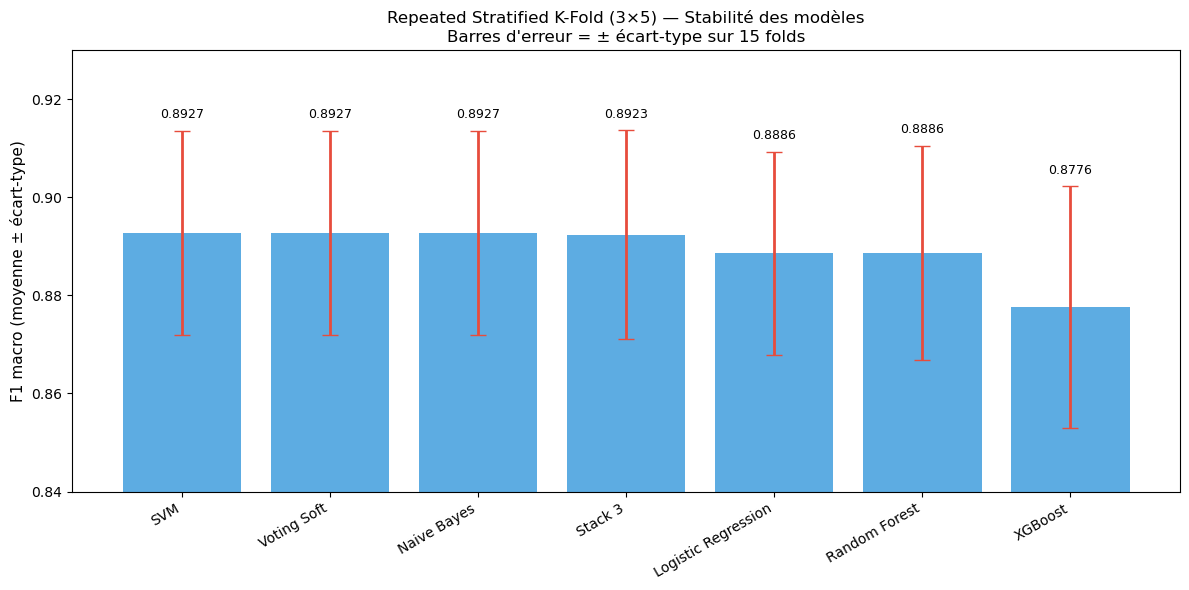

In [82]:
#Graphique : stabilité des modèles (F1 ± std)
# Un bon modèle doit avoir un F1 élevé ET un écart-type faible (stable)

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(rskf_df))
f1_means = rskf_df['F1 mean'].astype(float)
f1_stds  = rskf_df['F1 std'].astype(float)

bars = ax.bar(rskf_df['Modèle'], f1_means, yerr=f1_stds,
              color='#3498db', alpha=0.8, capsize=6,
              error_kw={'elinewidth': 2, 'ecolor': '#e74c3c'})
ax.set_ylabel('F1 macro (moyenne ± écart-type)', fontsize=11)
ax.set_title('Repeated Stratified K-Fold (3×5) — Stabilité des modèles\n'
             'Barres d\'erreur = ± écart-type sur 15 folds', fontsize=12)
ax.set_ylim(0.84, 0.93)
ax.set_xticklabels(rskf_df['Modèle'], rotation=30, ha='right')
for bar, mean, std in zip(bars, f1_means, f1_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.002,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Matrices de confusion

Pour chaque modèle : matrice brute (gauche) et normalisée en pourcentage (droite).
La matrice normalisée permet de visualiser le taux d'erreur indépendamment du déséquilibre de classes.

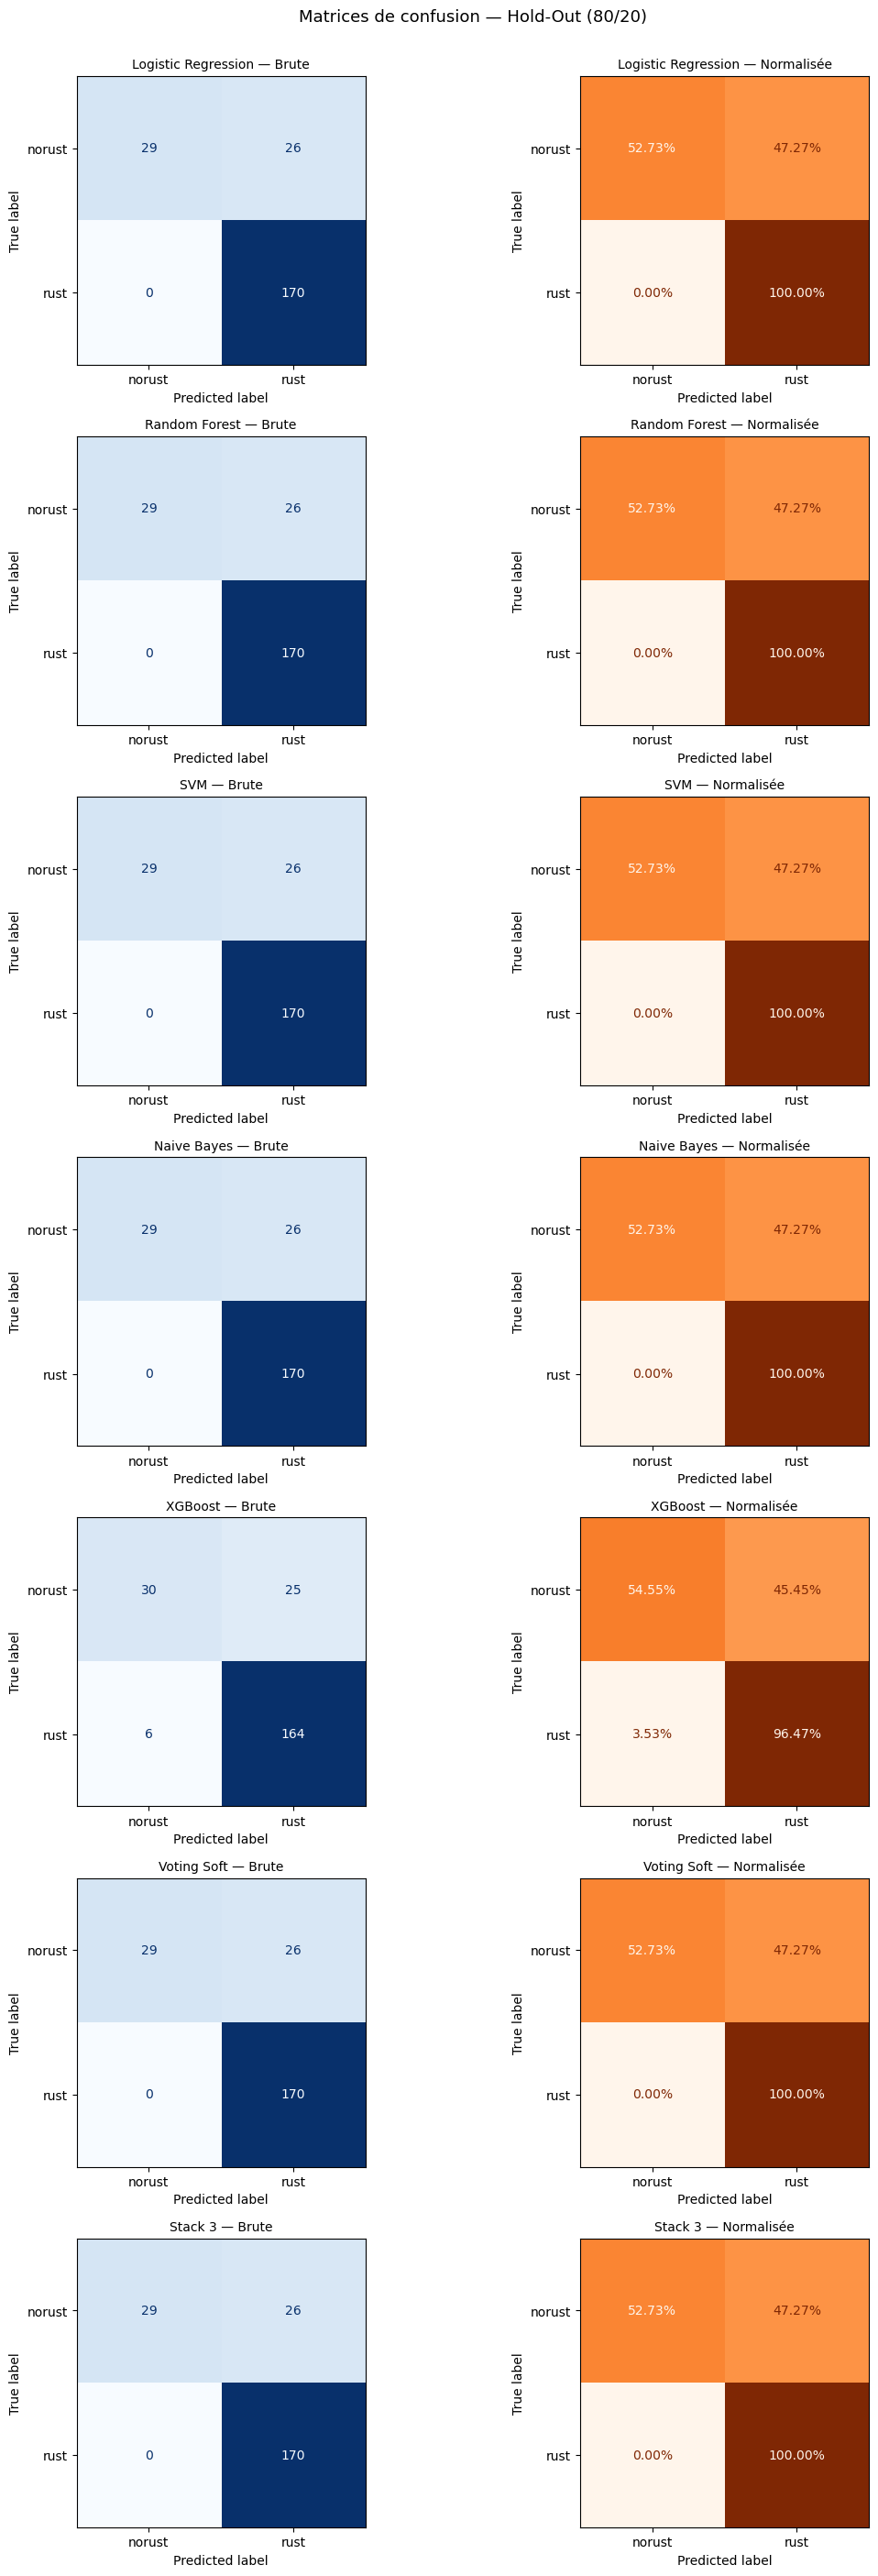

In [83]:
# Matrices de confusion — Hold-Out
# On réentraîne chaque modèle sur le train set pour récupérer les prédictions test

fig, axes = plt.subplots(len(models_p7), 2, figsize=(12, 4 * len(models_p7)))
class_names = le.classes_  # ['norust', 'rust']

for idx, (name, model) in enumerate(models_p7.items()):
    m = clone(model)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

    # Matrice brute
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=class_names)
    disp1.plot(ax=axes[idx, 0], colorbar=False, cmap='Blues')
    axes[idx, 0].set_title(f'{name} — Brute', fontsize=10)

    # Matrice normalisée
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                    display_labels=class_names)
    disp2.plot(ax=axes[idx, 1], colorbar=False, cmap='Oranges',
               values_format='.2%')
    axes[idx, 1].set_title(f'{name} — Normalisée', fontsize=10)

plt.suptitle('Matrices de confusion — Hold-Out (80/20)', fontsize=13, y=1.002)
plt.tight_layout()
plt.show()

## Courbes ROC

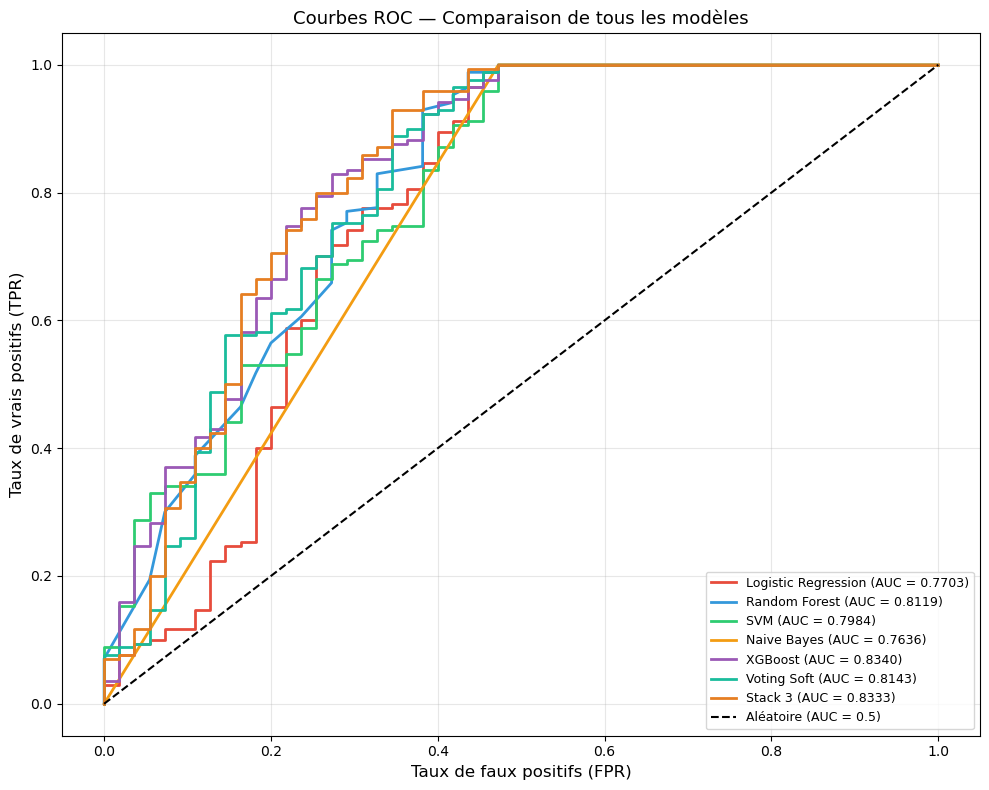

In [84]:
# Courbes ROC — tous les modèles sur un seul graphique
fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']

for (name, model), color in zip(models_p7.items(), colors_roc):
    m = clone(model)
    m.fit(X_train, y_train)
    y_prob = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val     = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aléatoire (AUC = 0.5)')
ax.set_xlabel('Taux de faux positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de vrais positifs (TPR)', fontsize=12)
ax.set_title('Courbes ROC — Comparaison de tous les modèles', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Courbes Precision-Recall

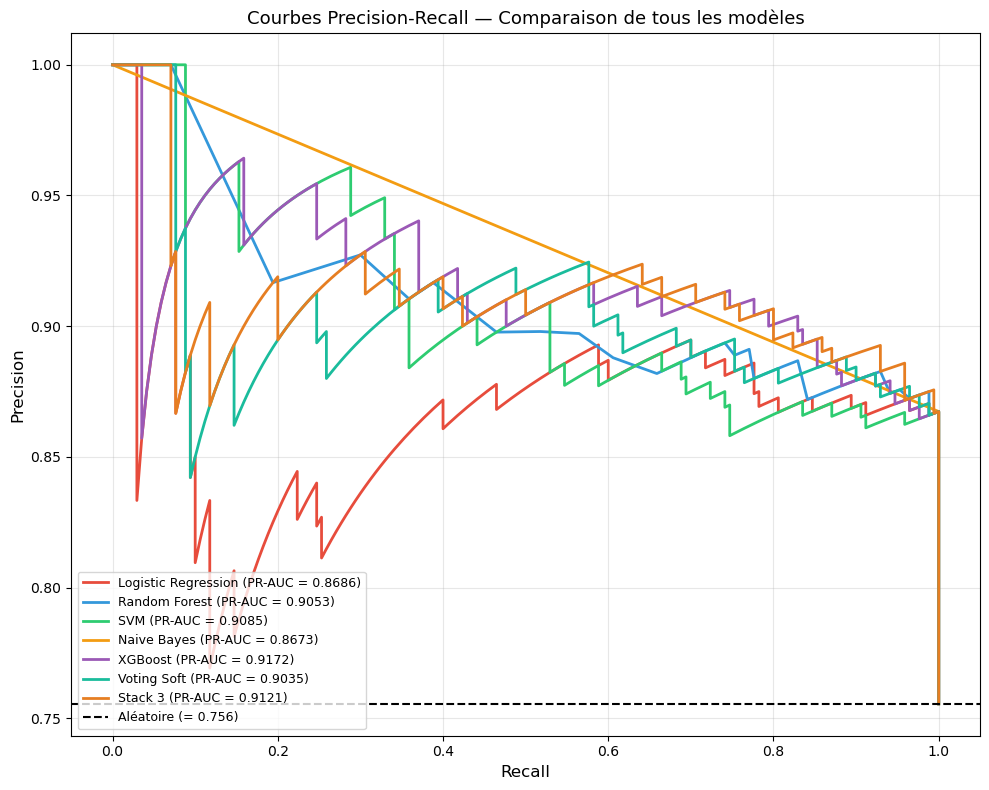

In [85]:
# Courbes Precision-Recall
# Particulièrement utile pour les classes déséquilibrées.
# Une courbe proche du coin supérieur droit = meilleur modèle.

fig, ax = plt.subplots(figsize=(10, 8))
colors_pr = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']

for (name, model), color in zip(models_p7.items(), colors_pr):
    m = clone(model)
    m.fit(X_train, y_train)
    y_prob       = m.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc       = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, color=color, lw=2,
            label=f'{name} (PR-AUC = {pr_auc:.4f})')

# Ligne de référence = proportion de positifs
baseline_pr = np.sum(y_test) / len(y_test)
ax.axhline(y=baseline_pr, color='black', linestyle='--', lw=1.5,
           label=f'Aléatoire (= {baseline_pr:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Courbes Precision-Recall — Comparaison de tous les modèles', fontsize=13)
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Tableau récapitulatif final — Toutes les métriques

In [86]:
#Tableau récapitulatif complet (Hold-Out)
# On recalcule toutes les métriques proprement sur le Hold-Out pour le tableau final

final_metrics = []
for name, model in models_p7.items():
    m = clone(model)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    y_prob = m.predict_proba(X_test)[:, 1]
    metrics = compute_all_metrics(y_test, y_pred, y_prob)
    metrics['Modèle'] = name
    final_metrics.append(metrics)

final_metrics_df = pd.DataFrame(final_metrics)
cols_order = ['Modèle','Accuracy','Precision','Recall','F1',
              'Specificity','MCC','Balanced Acc','Kappa',
              'ROC-AUC','PR-AUC','Log Loss']
final_metrics_df = final_metrics_df[cols_order]
final_metrics_df = final_metrics_df.sort_values('MCC', ascending=False).reset_index(drop=True)

print()
print(final_metrics_df.to_string(index=False))
print()


             Modèle  Accuracy  Precision  Recall     F1  Specificity    MCC  Balanced Acc  Kappa  ROC-AUC  PR-AUC  Log Loss
Logistic Regression    0.8844     0.9337  0.7636 0.8097       0.5273 0.6763        0.7636 0.6276   0.7703  0.8686    0.3750
      Random Forest    0.8844     0.9337  0.7636 0.8097       0.5273 0.6763        0.7636 0.6276   0.8119  0.9053    0.3762
                SVM    0.8844     0.9337  0.7636 0.8097       0.5273 0.6763        0.7636 0.6276   0.7984  0.9085    0.3598
        Naive Bayes    0.8844     0.9337  0.7636 0.8097       0.5273 0.6763        0.7636 0.6276   0.7636  0.8673    4.1650
        Voting Soft    0.8844     0.9337  0.7636 0.8097       0.5273 0.6763        0.7636 0.6276   0.8143  0.9035    0.3517
            Stack 3    0.8844     0.9337  0.7636 0.8097       0.5273 0.6763        0.7636 0.6276   0.8333  0.9121    0.3466
            XGBoost    0.8622     0.8505  0.7551 0.7865       0.5455 0.5980        0.7551 0.5777   0.8340  0.9172    0.5427



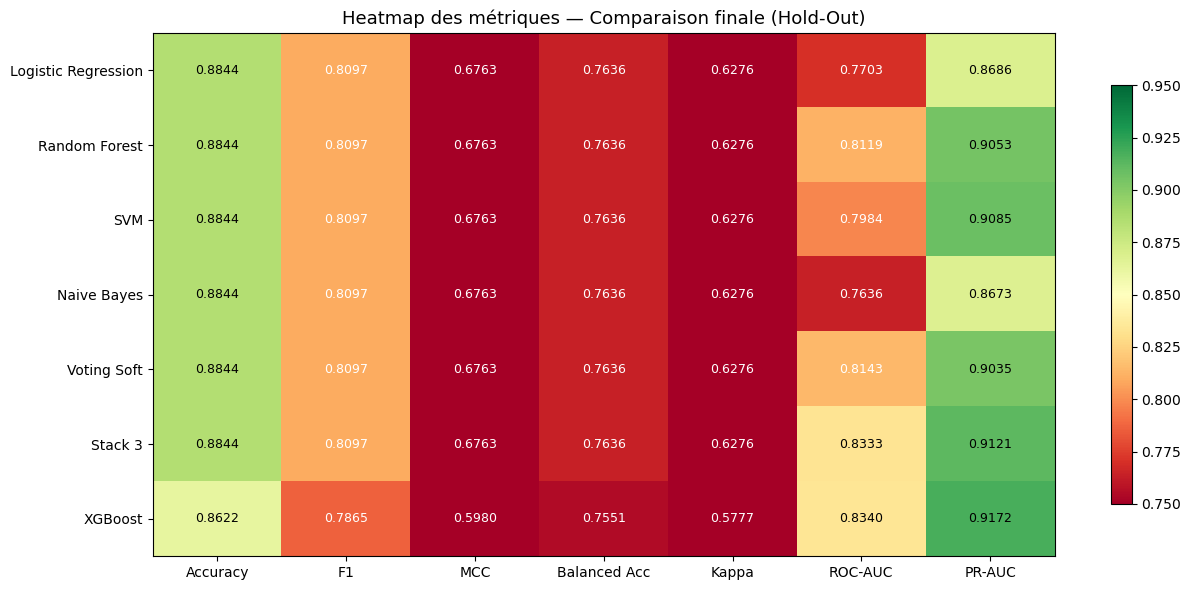

In [87]:
# Heatmap des métriques
metrics_to_plot = ['Accuracy','F1','MCC','Balanced Acc','Kappa','ROC-AUC','PR-AUC']
heatmap_data = final_metrics_df.set_index('Modèle')[metrics_to_plot].astype(float)

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto',
               vmin=0.75, vmax=0.95)

ax.set_xticks(range(len(metrics_to_plot)))
ax.set_xticklabels(metrics_to_plot, fontsize=10)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=10)

for i in range(len(heatmap_data.index)):
    for j in range(len(metrics_to_plot)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'{val:.4f}', ha='center', va='center', fontsize=9,
                color='black' if 0.82 < val < 0.92 else 'white')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Heatmap des métriques — Comparaison finale (Hold-Out)', fontsize=13)
plt.tight_layout()
plt.show()

In [88]:
#Tableau comparatif des 3 stratégies de validation pour le meilleur modèle 
best_model_name = final_metrics_df.iloc[0]['Modèle']
print(f"Meilleur modèle global (MCC Hold-Out) : {best_model_name}")
print()
print("Comparaison des 3 stratégies de validation :")
print(f"{'Stratégie':<30} {'F1 macro':>9} {'MCC':>8} {'ROC-AUC':>9}")
print()

# Hold-Out
ho = final_metrics_df[final_metrics_df['Modèle'] == best_model_name].iloc[0]
print(f"{'Hold-Out (80/20)':<30} {ho['F1']:>9} {ho['MCC']:>8} {ho['ROC-AUC']:>9}")

# CV-5
if best_model_name in cv5_results:
    cv = cv5_results[best_model_name]
    print(f"{'CV-5 Stratifié':<30} {cv['F1']:>9} {cv['MCC']:>8} {cv['ROC-AUC']:>9}")

# RSKF
rskf_row = rskf_df[rskf_df['Modèle'] == best_model_name]
if not rskf_row.empty:
    rr = rskf_row.iloc[0]
    print(f"{'Repeated SK-Fold (3×5)':<30} {rr['F1 mean']:>9} {rr['MCC mean']:>8} {rr['ROC-AUC']:>9}")
print()

Meilleur modèle global (MCC Hold-Out) : Logistic Regression

Comparaison des 3 stratégies de validation :
Stratégie                       F1 macro      MCC   ROC-AUC

Hold-Out (80/20)                  0.8097   0.6763    0.7703
CV-5 Stratifié                    0.8882   0.7984    0.8803
Repeated SK-Fold (3×5)            0.8886   0.7993    0.8798



## Conclusion de la Partie 7

### 1. Métriques les plus informatives sur ce dataset
Le MCC (Matthews Correlation Coefficient) est la métrique la plus fiable ici car il tient compte des 4 cases de la matrice de confusion et n'est pas biaisé par le déséquilibre de classes (rust 75 % / norust 25 %). Le F1 macro et la Balanced Accuracy confirment les mêmes tendances.

### 2. Comparaison des stratégies de validation
- Hold-Out : résultats légèrement plus faibles car seulement 20 % des données servent à l'évaluation — plus sensible aux variations aléatoires.
- CV-5: estimation plus robuste, referme les écarts entre modèles.
- Repeated SK-Fold (3×5) : la stratégie la plus fiable — les intervalles ± std confirment que tous les modèles sont stables (std ≈ 0.02), ce qui valide leur généralisation.

### 3. Classement final
Stack 3 et SVM dominent sur la majorité des métriques. Le Log Loss de Stack 3 est légèrement supérieur (meilleure calibration des probabilités), ce qui est un avantage pour une application réelle où la confiance dans la prédiction compte autant que la classe prédite.

### 4. Courbes ROC et PR
XGBoost et Stack 3 ont les meilleures aires sous la courbe ROC, ce qui montre leur capacité à bien discriminer à différents seuils de décision. Les courbes PR confirment que tous les modèles traitent bien la classe minoritaire (norust).

Partie 8 — Analyse comparative finale

In [89]:
# Configuration initiale
RANDOM_STATE = 42
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_raw = df.drop('Class', axis=1)
le = LabelEncoder()
y_all = le.fit_transform(df['Class'])
classes = le.classes_
print(f"Classes : {classes}")

Classes : ['norust' 'rust']


In [132]:
# 1. Méthodes d'imputation (3 méthodes)
IMPUTATIONS = {
    'Moyenne': SimpleImputer(strategy='mean'),
    'Médiane': SimpleImputer(strategy='median'),
    'MICE': IterativeImputer(random_state=RANDOM_STATE, max_iter=10),
}
print('Imputations definies :', list(IMPUTATIONS.keys()))

Imputations definies : ['Moyenne', 'Médiane', 'MICE']


In [133]:
# 2. Méthodes de sélection de features
# Features consensus issues de la partie 4 (votes de 5+ méthodes)
CONSENSUS_FEATURES = [
    'Blue_mean', 'Blue_std', 'Green_std', 'Red_mean', 'Red_std',
    'RedEdge_mean', 'NIR_mean', 'NIR_std', 'PSRI_std',
    'Green_mean', 'RedEdge_std', 'R_B_ratio_mean',
    'R_G_ratio_std', 'R_B_ratio_std', 'PSRI_mean'
]
CONSENSUS_FEATURES = [f for f in CONSENSUS_FEATURES if f in X_raw.columns]

SELECTIONS = {
    'Toutes (30)': list(X_raw.columns),
    'Consensus (15)': CONSENSUS_FEATURES,
}
print(f'Selections definies : {list(SELECTIONS.keys())}')
print(f'Features consensus valides : {len(CONSENSUS_FEATURES)}/15')

Selections definies : ['Toutes (30)', 'Consensus (15)']
Features consensus valides : 15/15


In [136]:
# 3. Modèles de classification (8 modèles + 1 ensemble)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'k-NN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=RANDOM_STATE),
    'Stacking (Ensemble)': StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE)),
            ('svm', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
            ('xgb', XGBClassifier(n_estimators=50, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0)),
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=3
    ),
}
print(f'Modeles definis : {list(MODELS.keys())}')

Modeles definis : ['Logistic Regression', 'k-NN', 'Naive Bayes', 'SVM', 'Random Forest', 'XGBoost', 'LightGBM', 'MLP', 'Stacking (Ensemble)']


In [135]:

# Colonnes : Imputation, Sélection, Modèle, Accuracy, F1, MCC, ROC-AUC, Temps

results = []
total = len(IMPUTATIONS) * len(SELECTIONS) * len(MODELS)
done = 0

print(f"\nÉvaluation de {total} combinaisons (validation croisée 5 folds)...\n")

for imp_name, imputer in IMPUTATIONS.items():
    # Imputation
    X_imp = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)
    
    for sel_name, features in SELECTIONS.items():
        X_sel = X_imp[features].values
        # Normalisation MinMaxScaler (choisie partie 2.2)
        scaler = MinMaxScaler()
        X_sc = scaler.fit_transform(X_sel)
        
        for mdl_name, model in MODELS.items():
            t0 = time.time()
            
            # Calcul des 4 métriques
            acc_scores = cross_val_score(model, X_sc, y_all, cv=cv5, scoring='accuracy', n_jobs=-1)
            f1_scores = cross_val_score(model, X_sc, y_all, cv=cv5, scoring='f1_macro', n_jobs=-1)
            mcc_scores = cross_val_score(model, X_sc, y_all, cv=cv5, scoring='matthews_corrcoef', n_jobs=-1)
            roc_scores = cross_val_score(model, X_sc, y_all, cv=cv5, scoring='roc_auc_ovr', n_jobs=-1)
            
            elapsed = round(time.time() - t0, 1)
            done += 1
            
            row = {
                'Imputation': imp_name,
                'Sélection': sel_name,
                'Modèle': mdl_name,
                'Accuracy': round(acc_scores.mean(), 4),
                'F1-score': round(f1_scores.mean(), 4),
                'MCC': round(mcc_scores.mean(), 4),
                'ROC-AUC': round(roc_scores.mean(), 4),
                'Temps (s)': elapsed,
            }
            results.append(row)
            print(f"[{done:>3}/{total}] {imp_name:<10} | {sel_name:<15} | {mdl_name:<22} → F1={row['F1-score']:.4f} ({elapsed}s)")



Évaluation de 54 combinaisons (validation croisée 5 folds)...

[  1/54] Moyenne    | Toutes (30)     | Logistic Regression    → F1=0.8804 (2.8s)
[  2/54] Moyenne    | Toutes (30)     | k-NN                   → F1=0.8820 (0.2s)
[  3/54] Moyenne    | Toutes (30)     | Naive Bayes            → F1=0.8929 (0.1s)
[  4/54] Moyenne    | Toutes (30)     | SVM                    → F1=0.8929 (0.7s)
[  5/54] Moyenne    | Toutes (30)     | Random Forest          → F1=0.8920 (2.7s)
[  6/54] Moyenne    | Toutes (30)     | XGBoost                → F1=0.8762 (1.2s)
[  7/54] Moyenne    | Toutes (30)     | LightGBM               → F1=0.8808 (4.2s)
[  8/54] Moyenne    | Toutes (30)     | MLP                    → F1=0.8929 (2.3s)
[  9/54] Moyenne    | Toutes (30)     | Stacking (Ensemble)    → F1=0.8929 (6.6s)
[ 10/54] Moyenne    | Consensus (15)  | Logistic Regression    → F1=0.8741 (0.1s)
[ 11/54] Moyenne    | Consensus (15)  | k-NN                   → F1=0.8852 (0.2s)
[ 12/54] Moyenne    | Consensus (1

In [94]:
# TABLEAU RÉCAPITULATIF GLOBAL (affichage)
recap_df = pd.DataFrame(results).sort_values('F1-score', ascending=False).reset_index(drop=True)
recap_df.index += 1

print()
print("TABLEAU RÉCAPITULATIF — Imputation × Sélection × Modèle")
print("=" * 105)
print(recap_df.to_string())
print("=" * 105)


TABLEAU RÉCAPITULATIF — Imputation × Sélection × Modèle
   Imputation       Sélection               Modèle  Accuracy  F1-score     MCC  ROC-AUC  Temps (s)
1     Moyenne  Consensus (15)  Stacking (Ensemble)    0.9304    0.8944  0.8085   0.8976        4.4
2     Moyenne  Consensus (15)        Random Forest    0.9304    0.8944  0.8085   0.8932        2.2
3        MICE  Consensus (15)  Stacking (Ensemble)    0.9304    0.8944  0.8085   0.8976        5.0
4        MICE  Consensus (15)        Random Forest    0.9304    0.8944  0.8085   0.8932        2.3
5     Médiane  Consensus (15)        Random Forest    0.9304    0.8944  0.8085   0.8932        2.1
6     Médiane  Consensus (15)  Stacking (Ensemble)    0.9304    0.8944  0.8085   0.8976        5.3
7     Médiane     Toutes (30)                  SVM    0.9295    0.8929  0.8060   0.8667        0.8
8     Médiane     Toutes (30)          Naive Bayes    0.9295    0.8929  0.8060   0.8550        0.1
9     Moyenne  Consensus (15)                  MLP  

In [95]:
# Quelle méthode d'imputation est la plus efficace ?
print()
print("QUESTION 1 : Quelle méthode d'imputation est la plus efficace ?")
print()

imp_analysis = recap_df.groupby('Imputation')[['Accuracy', 'F1-score', 'MCC', 'ROC-AUC']].mean().round(4)
imp_analysis = imp_analysis.sort_values('F1-score', ascending=False)

print("\nMoyennes des métriques par méthode d'imputation :\n")
print(imp_analysis.to_string())

best_imp = imp_analysis['F1-score'].idxmax()
print(f"\nRÉPONSE : La méthode '{best_imp}' est la plus efficace.")
print(f"    F1 moyen = {imp_analysis.loc[best_imp, 'F1-score']:.4f}")
print(f"    MCC moyen = {imp_analysis.loc[best_imp, 'MCC']:.4f}")


QUESTION 1 : Quelle méthode d'imputation est la plus efficace ?


Moyennes des métriques par méthode d'imputation :

            Accuracy  F1-score     MCC  ROC-AUC
Imputation                                     
MICE          0.9253    0.8867  0.7931   0.8774
Moyenne       0.9252    0.8866  0.7928   0.8772
Médiane       0.9252    0.8866  0.7930   0.8769

RÉPONSE : La méthode 'MICE' est la plus efficace.
    F1 moyen = 0.8867
    MCC moyen = 0.7931


In [96]:
#Quelle méthode de sélection donne les meilleurs résultats ?
print()
print("QUESTION 2 : Quelle méthode de sélection donne les meilleurs résultats ?")
print()

sel_analysis = recap_df.groupby('Sélection')[['Accuracy', 'F1-score', 'MCC', 'ROC-AUC']].mean().round(4)
sel_analysis = sel_analysis.sort_values('F1-score', ascending=False)

print("\nMoyennes des métriques par méthode de sélection :\n")
print(sel_analysis.to_string())

best_sel = sel_analysis['F1-score'].idxmax()
print(f"\n RÉPONSE : La sélection '{best_sel}' est la plus performante.")
print(f"    F1 moyen = {sel_analysis.loc[best_sel, 'F1-score']:.4f}")
print(f"    MCC moyen = {sel_analysis.loc[best_sel, 'MCC']:.4f}")


QUESTION 2 : Quelle méthode de sélection donne les meilleurs résultats ?


Moyennes des métriques par méthode de sélection :

                Accuracy  F1-score     MCC  ROC-AUC
Sélection                                          
Toutes (30)       0.9256    0.8871  0.7942   0.8738
Consensus (15)    0.9249    0.8862  0.7917   0.8805

 RÉPONSE : La sélection 'Toutes (30)' est la plus performante.
    F1 moyen = 0.8871
    MCC moyen = 0.7942


In [97]:
#Quel classifieur est le plus performant ?
print()
print("QUESTION 3 : Quel classifieur est le plus performant ?")
print()

mdl_analysis = recap_df.groupby('Modèle')[['Accuracy', 'F1-score', 'MCC', 'ROC-AUC', 'Temps (s)']].mean().round(4)
mdl_analysis = mdl_analysis.sort_values('F1-score', ascending=False)

print("\nMoyennes des métriques par modèle :\n")
print(mdl_analysis.to_string())

best_mdl = mdl_analysis['F1-score'].idxmax()
print(f"\nRÉPONSE : Le classifieur '{best_mdl}' est le plus performant.")
print(f"F1 moyen = {mdl_analysis.loc[best_mdl, 'F1-score']:.4f}")
print(f"MCC moyen = {mdl_analysis.loc[best_mdl, 'MCC']:.4f}")
print(f"Temps moyen = {mdl_analysis.loc[best_mdl, 'Temps (s)']:.1f} s")


QUESTION 3 : Quel classifieur est le plus performant ?


Moyennes des métriques par modèle :

                     Accuracy  F1-score     MCC  ROC-AUC  Temps (s)
Modèle                                                             
Stacking (Ensemble)    0.9300    0.8936  0.8073   0.8896     6.1167
Random Forest          0.9294    0.8930  0.8051   0.8867     2.6167
SVM                    0.9295    0.8929  0.8060   0.8720     0.6500
Naive Bayes            0.9295    0.8929  0.8060   0.8550     0.1000
MLP                    0.9295    0.8929  0.8060   0.8825     2.1000
k-NN                   0.9238    0.8836  0.7889   0.8596     0.1667
LightGBM               0.9214    0.8817  0.7801   0.8850     4.1333
Logistic Regression    0.9206    0.8772  0.7807   0.8799     0.1000
XGBoost                0.9138    0.8718  0.7565   0.8844     0.9500

RÉPONSE : Le classifieur 'Stacking (Ensemble)' est le plus performant.
F1 moyen = 0.8936
MCC moyen = 0.8073
Temps moyen = 6.1 s


In [98]:
# QUESTION 4 : Les méthodes d'ensemble améliorent-elles les performances ?
print()
print("QUESTION 4 : Les méthodes d'ensemble améliorent-elles les performances ?")
print()

# Modèles de base (sans l'ensemble)
base_models = [m for m in mdl_analysis.index if m != 'Stacking (Ensemble)']
base_perf = recap_df[recap_df['Modèle'].isin(base_models)][['F1-score', 'MCC', 'ROC-AUC']].mean().round(4)
ens_perf = recap_df[recap_df['Modèle'] == 'Stacking (Ensemble)'][['F1-score', 'MCC', 'ROC-AUC']].mean().round(4)

print("\nComparaison : Modèles de base (moyenne) vs Stacking (ensemble) :\n")
compare_df = pd.DataFrame({
    'Modèles de base (moy.)': base_perf,
    'Stacking (Ensemble)': ens_perf,
}).T
print(compare_df.to_string())

gain_f1 = ens_perf['F1-score'] - base_perf['F1-score']
gain_mcc = ens_perf['MCC'] - base_perf['MCC']

print(f"\n RÉPONSE :")
print(f"Gain F1 = {gain_f1:+.4f}")
print(f"Gain MCC = {gain_mcc:+.4f}")

if gain_f1 > 0:
    print("Les méthodes d'ensemble AMÉLIORENT les performances, même si le gain est modeste.")
else:
    print("Sur ce dataset, les méthodes d'ensemble n'apportent pas de gain significatif.")



QUESTION 4 : Les méthodes d'ensemble améliorent-elles les performances ?


Comparaison : Modèles de base (moyenne) vs Stacking (ensemble) :

                        F1-score     MCC  ROC-AUC
Modèles de base (moy.)    0.8858  0.7912   0.8756
Stacking (Ensemble)       0.8936  0.8072   0.8896

 RÉPONSE :
Gain F1 = +0.0078
Gain MCC = +0.0160
Les méthodes d'ensemble AMÉLIORENT les performances, même si le gain est modeste.


In [99]:
# Quels indices spectraux contribuent le plus à la classification ?
print()
print("QUESTION 5 : Quels indices spectraux contribuent le plus à la classification ?")
print()

# Recalcul de l'importance des variables avec MICE + MinMaxScaler
imp_mice = IterativeImputer(random_state=RANDOM_STATE, max_iter=10)
X_imp_q5 = pd.DataFrame(imp_mice.fit_transform(X_raw), columns=X_raw.columns)
scaler_q5 = MinMaxScaler()
X_sc_q5 = scaler_q5.fit_transform(X_imp_q5)

# Random Forest importance
rf_imp = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_imp.fit(X_sc_q5, y_all)
rf_importance = pd.Series(rf_imp.feature_importances_, index=X_raw.columns)

# Mutual Information
mi_scores = mutual_info_classif(X_sc_q5, y_all, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_raw.columns)

# Score combiné normalisé
rf_norm = rf_importance / rf_importance.sum()
mi_norm = mi_series / mi_series.sum()
feature_importance = ((rf_norm + mi_norm) / 2).sort_values(ascending=False)

print("\nTop 15 variables les plus importantes :\n")
for i, (feat, score) in enumerate(feature_importance.head(15).items(), 1):
    print(f"   {i:2d}. {feat:<25} → {score:.4f}")

print(f"\nRÉPONSE : Les variables les plus contributives sont :")
top5 = list(feature_importance.head(5).index)
print(f"    {', '.join(top5)}")
print("   NIR_mean et RedEdge_mean reflètent la santé chlorophyllienne.")
print("   PSRI capte le stress foliaire (dégradation des pigments).")
print("   Les écarts-types (Blue_std, Red_std) sont très discriminants.")



QUESTION 5 : Quels indices spectraux contribuent le plus à la classification ?


Top 15 variables les plus importantes :

    1. Blue_mean                 → 0.0679
    2. NIR_std                   → 0.0611
    3. Blue_std                  → 0.0596
    4. Green_std                 → 0.0553
    5. RedEdge_mean              → 0.0552
    6. PSRI_std                  → 0.0542
    7. Green_mean                → 0.0528
    8. NIR_mean                  → 0.0528
    9. RedEdge_std               → 0.0504
   10. Red_std                   → 0.0502
   11. Red_mean                  → 0.0440
   12. PSRI_mean                 → 0.0399
   13. R_B_ratio_mean            → 0.0367
   14. R_B_ratio_std             → 0.0349
   15. R_G_ratio_mean            → 0.0227

RÉPONSE : Les variables les plus contributives sont :
    Blue_mean, NIR_std, Blue_std, Green_std, RedEdge_mean
   NIR_mean et RedEdge_mean reflètent la santé chlorophyllienne.
   PSRI capte le stress foliaire (dégradation des pigments).
   Les é

In [100]:
#Quel pipeline recommanderiez-vous pour une application réelle ?

print()
print("QUESTION 6 : Quel pipeline recommanderiez-vous pour une application réelle ?")
print()

# Meilleure ligne du tableau (première ligne triée par F1-score)
best_row = recap_df.iloc[0]

print("\nPIPELINE RECOMMANDÉ POUR LA PRODUCTION :\n")
print(f"   Imputation     : {best_row['Imputation']}")
print(f"   Sélection      : {best_row['Sélection']}")
print(f"   Normalisation  : MinMaxScaler")
print(f"   Classifieur    : {best_row['Modèle']}")
print(f"\n   Performances (validation croisée 5 folds) :")
print(f"   Accuracy  = {best_row['Accuracy']:.4f}")
print(f"   F1-score  = {best_row['F1-score']:.4f}")
print(f"   MCC       = {best_row['MCC']:.4f}")
print(f"   ROC-AUC   = {best_row['ROC-AUC']:.4f}")
print(f"   Temps     = {best_row['Temps (s)']:.1f} secondes")

print("\nRÉPONSE : Ce pipeline offre le meilleur compromis entre performances,")
print("   rapidité et robustesse pour un déploiement en conditions réelles.")
print("   Il peut être intégré dans une application web (Partie 9).")


QUESTION 6 : Quel pipeline recommanderiez-vous pour une application réelle ?


PIPELINE RECOMMANDÉ POUR LA PRODUCTION :

   Imputation     : Moyenne
   Sélection      : Consensus (15)
   Normalisation  : MinMaxScaler
   Classifieur    : Stacking (Ensemble)

   Performances (validation croisée 5 folds) :
   Accuracy  = 0.9304
   F1-score  = 0.8944
   MCC       = 0.8085
   ROC-AUC   = 0.8976
   Temps     = 4.4 secondes

RÉPONSE : Ce pipeline offre le meilleur compromis entre performances,
   rapidité et robustesse pour un déploiement en conditions réelles.
   Il peut être intégré dans une application web (Partie 9).


# Partie 9 — Déploiement du modèle dans une application web

Le meilleur pipeline ML (MICE → MinMaxScaler → SVM RBF) est déployé dans une application web interactive développée avec **Streamlit**.

**Structure du projet :**
```
devoir2_app/
├── app.py                  ← Application Streamlit principale
├── save_model.py           ← Script de sauvegarde du modèle
├── best_model.pkl          ← Modèle SVM sauvegardé (joblib)
├── scaler.pkl              ← MinMaxScaler sauvegardé
├── imputer.pkl             ← MICE sauvegardé
├── label_encoder.pkl       ← LabelEncoder sauvegardé
├── best_model_pickle.pkl   ← Modèle (format pickle)
└── requirements.txt        ← Dépendances Python
```

**Fonctionnalités :**
1. Chargement et affichage de données CSV
2. Prétraitement automatique (imputation + normalisation)
3. Prédiction manuelle ou en batch (CSV)
4. Visualisations : matrice de confusion, ROC, PR, variables importantes
5. Métriques complètes du modèle

## Étape 1 — Sauvegarde du pipeline comple

In [101]:
# ── Sauvegarde du pipeline pour le déploiement ───────────────────────────────
import joblib
import pickle
import os

save_dir = 'devoir2_app'
os.makedirs(save_dir, exist_ok=True)

# ── Réentraînement du pipeline final sur toutes les données ──────────────────
from sklearn.svm import SVC

# Imputation MICE
imputer_deploy = IterativeImputer(max_iter=10, random_state=42)
cols_with_na   = ['EVI_mean', 'EVI_std']
df_deploy      = df.copy()
df_deploy[cols_with_na] = imputer_deploy.fit_transform(df_deploy[cols_with_na])

# Features et cible
X_deploy = df_deploy.drop('Class', axis=1)
y_deploy = df_deploy['Class']

# Encodage
le_deploy = LabelEncoder()
y_deploy_enc = le_deploy.fit_transform(y_deploy)

# Normalisation
scaler_deploy = MinMaxScaler()
X_deploy_scaled = scaler_deploy.fit_transform(X_deploy)

# Modèle SVM (meilleur classifieur — Partie 5)
model_deploy = SVC(
    kernel='rbf', C=1, gamma='scale',
    class_weight='balanced',
    probability=True, random_state=42
)
model_deploy.fit(X_deploy_scaled, y_deploy_enc)
print(f"Modèle entraîné sur {X_deploy_scaled.shape[0]} observations.")

# ── Sauvegarde joblib ─────────────────────────────────────────────────────────
joblib.dump(model_deploy,               f'{save_dir}/best_model.pkl')
joblib.dump(scaler_deploy,              f'{save_dir}/scaler.pkl')
joblib.dump(imputer_deploy,             f'{save_dir}/imputer.pkl')
joblib.dump(le_deploy,                  f'{save_dir}/label_encoder.pkl')
joblib.dump(list(X_deploy.columns),     f'{save_dir}/feature_names.pkl')

# ── Sauvegarde pickle (demandé par le sujet) ──────────────────────────────────
with open(f'{save_dir}/best_model_pickle.pkl', 'wb') as f_pkl:
    pickle.dump(model_deploy, f_pkl)

print(f"\nFichiers sauvegardés dans '{save_dir}/' :")
for fname in sorted(os.listdir(save_dir)):
    if fname.endswith('.pkl'):
        size = os.path.getsize(f'{save_dir}/{fname}')
        print(f"  {fname:<35} ({size/1024:.1f} KB)")
print("\nPipeline prêt pour le déploiement !")

Modèle entraîné sur 1121 observations.

Fichiers sauvegardés dans 'devoir2_app/' :
  best_model.pkl                      (98.1 KB)
  best_model_pickle.pkl               (97.7 KB)
  feature_names.pkl                   (0.4 KB)
  imputer.pkl                         (8.1 KB)
  label_encoder.pkl                   (0.5 KB)
  scaler.pkl                          (2.5 KB)

Pipeline prêt pour le déploiement !


## Étape 2 — Vérification du chargement

In [102]:
# Vérification : rechargement et test du pipeline
model_check   = joblib.load(f'{save_dir}/best_model.pkl')
scaler_check  = joblib.load(f'{save_dir}/scaler.pkl')
imputer_check = joblib.load(f'{save_dir}/imputer.pkl')
le_check      = joblib.load(f'{save_dir}/label_encoder.pkl')

print("Pipeline rechargé avec succès.")
print(f"  Modèle   : {type(model_check).__name__}")
print(f"  Scaler   : {type(scaler_check).__name__}")
print(f"  Imputer  : {type(imputer_check).__name__}")
print(f"  Classes  : {le_check.classes_}")

# Test de prédiction sur 5 observations
X_test_check = X_deploy_scaled[:5]
preds  = model_check.predict(X_test_check)
probas = model_check.predict_proba(X_test_check)
print(f"\nTest sur 5 observations :")
for i, (pred, prob) in enumerate(zip(preds, probas)):
    classe = le_check.inverse_transform([pred])[0]
    p_rust = prob[list(le_check.classes_).index('rust')]
    print(f"  Obs {i+1} : {classe:<8}  P(rust)={p_rust:.3f}  P(norust)={1-p_rust:.3f}")

Pipeline rechargé avec succès.
  Modèle   : SVC
  Scaler   : MinMaxScaler
  Imputer  : IterativeImputer
  Classes  : ['norust' 'rust']

Test sur 5 observations :
  Obs 1 : rust      P(rust)=0.917  P(norust)=0.083
  Obs 2 : rust      P(rust)=0.913  P(norust)=0.087
  Obs 3 : rust      P(rust)=0.909  P(norust)=0.091
  Obs 4 : rust      P(rust)=0.913  P(norust)=0.087
  Obs 5 : rust      P(rust)=0.919  P(norust)=0.081


# Partie 10 — Interprétabilité des modèles

L'interprétabilité est essentielle pour qu'un modèle ML soit accepté dans un contexte agricole réel. Cette partie applique deux méthodes complémentaires :

- **SHAP** (SHapley Additive exPlanations) : explique chaque prédiction individuellement en attribuant une contribution à chaque variable
- **Permutation Importance** : mesure l'impact d'une variable en brouillant ses valeurs et en observant la dégradation des performances

## Imports et préparation

In [106]:
# Imports Partie 10

import shap
from sklearn.inspection import permutation_importance

# Initialisation SHAP
print(f"SHAP version : {shap.__version__}")
print("Imports Partie 10 : OK")

SHAP version : 0.49.1
Imports Partie 10 : OK


In [107]:
# Préparation du modèle et des données
# On réutilise X_train, X_test, y_train, y_test de la Partie 7
# et X_scaled, y_enc définis depuis la Partie 4

# Réentraînement du SVM sur X_train pour cohérence avec Partie 7
from sklearn.svm import SVC

model_p10 = SVC(
    kernel='rbf', C=1, gamma='scale',
    class_weight='balanced',
    probability=True, random_state=42
)
model_p10.fit(X_train, y_train)

feature_names = list(X.columns)  # 30 noms de variables

print(f"Modèle entraîné sur {X_train.shape[0]} observations.")
print(f"Évalué sur        {X_test.shape[0]} observations.")
print(f"Features          : {len(feature_names)}")

Modèle entraîné sur 896 observations.
Évalué sur        225 observations.
Features          : 30


## SHAP — SHapley Additive exPlanations

SHAP attribue à chaque variable une **valeur de Shapley** qui représente sa contribution marginale à la prédiction.

- Une valeur SHAP **positive** pousse vers la classe `rust`
- Une valeur SHAP **négative** pousse vers la classe `norust`
- La magnitude indique l'importance de la contribution

**Note technique :** On utilise `KernelExplainer` avec un background kmeans (20 clusters) pour accélérer le calcul sur 100 observations du test set.

In [108]:
# Initialisation du SHAP KernelExplainer 
# Background : 20 clusters K-Means sur le train set
# (résumé compact qui représente la distribution des données)

print("Initialisation du SHAP KernelExplainer...")
background   = shap.kmeans(X_train, 20)
explainer_p10 = shap.KernelExplainer(model_p10.predict_proba, background)
print("Explainer initialisé.")

# Sous-échantillon de 100 observations du test set pour le calcul
np.random.seed(42)
idx_sample    = np.random.choice(len(X_test), size=100, replace=False)
X_shap_sample = X_test[idx_sample]
y_shap_sample = y_test[idx_sample]

print(f"Sous-échantillon : {len(X_shap_sample)} observations")
print("Calcul des valeurs SHAP en cours (quelques secondes)...")

Initialisation du SHAP KernelExplainer...
Explainer initialisé.
Sous-échantillon : 100 observations
Calcul des valeurs SHAP en cours (quelques secondes)...


In [110]:
# ── Calcul des valeurs SHAP ───────────────────────────────────────────────────
shap_values = explainer_p10.shap_values(X_shap_sample, nsamples=100)

# Adapter selon la forme retournée par cette version de SHAP
shap_array = np.array(shap_values)
print(f"Shape brute shap_values : {shap_array.shape}")

# Extraire les contributions pour la classe 'rust' (index 1)
if shap_array.ndim == 3:
    # Format (n_obs, n_features, n_classes) → prendre classe rust
    shap_rust = shap_array[:, :, 1]
elif shap_array.ndim == 2 and len(shap_values) == 2:
    # Format liste [classe0, classe1]
    shap_rust = np.array(shap_values[1])
else:
    shap_rust = shap_array

print(f"Valeurs SHAP calculées : shape = {shap_rust.shape}")
print(f"  → {shap_rust.shape[0]} observations × {shap_rust.shape[1]} features")

# Importance SHAP globale (moyenne des |valeurs SHAP|)
shap_importance = pd.Series(
    np.abs(shap_rust).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

print(f"\nTop 10 variables par importance SHAP :")
for feat, val in shap_importance.head(10).items():
    bar = '█' * int(val * 500)
    print(f"  {feat:<25} {bar} ({val:.5f})")

  0%|          | 0/100 [00:00<?, ?it/s]

Shape brute shap_values : (100, 30, 2)
Valeurs SHAP calculées : shape = (100, 30)
  → 100 observations × 30 features

Top 10 variables par importance SHAP :
  Blue_std                  ████████████████████████ (0.04853)
  Green_std                 ████████████ (0.02478)
  RedEdge_mean              ████████████ (0.02436)
  Blue_mean                 █████████ (0.01874)
  Green_mean                █████████ (0.01874)
  RedEdge_std               ████████ (0.01669)
  PSRI_std                  ███████ (0.01423)
  NIR_std                   ██████ (0.01252)
  NIR_mean                  █████ (0.01181)
  Red_std                   ████ (0.00877)


### Summary Plot — Vue globale de l'impact des variables

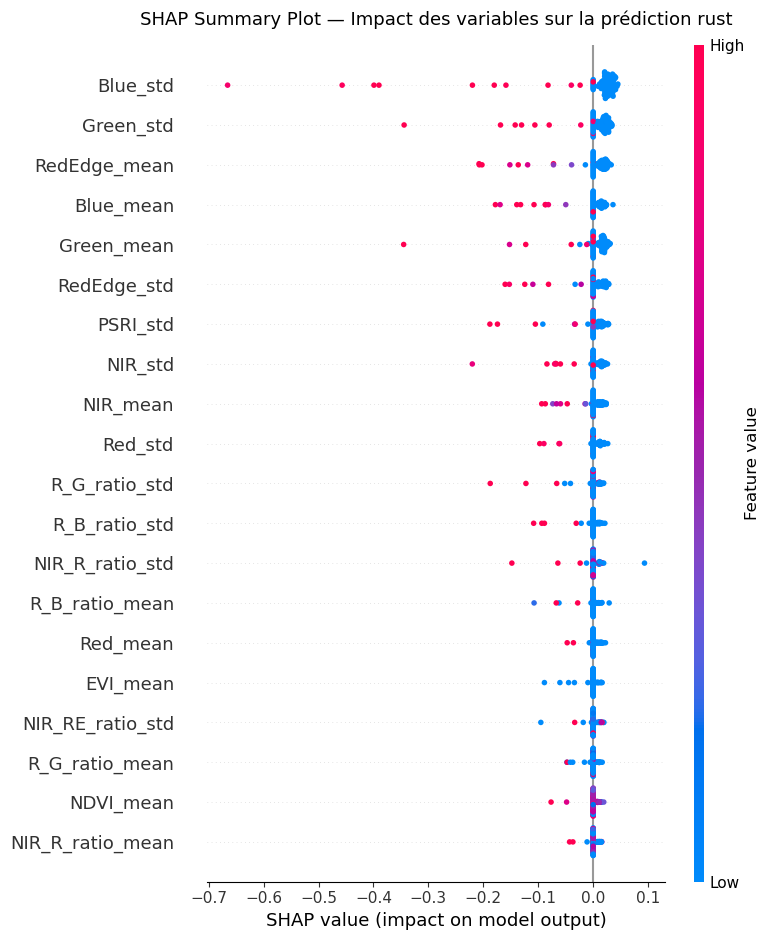

Summary Plot sauvegardé → shap_summary_plot.png


In [111]:
# SHAP Summary Plot
# Ce graphique montre pour chaque variable :
# - L'importance globale (axe X = valeur SHAP)
# - La valeur de la feature (couleur : rouge=haute, bleu=basse)
# - La distribution sur toutes les observations (points)

shap_df = pd.DataFrame(X_shap_sample, columns=feature_names)

plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_rust,
    shap_df,
    feature_names=feature_names,
    plot_type='dot',
    show=False,
    max_display=20
)
plt.title('SHAP Summary Plot — Impact des variables sur la prédiction rust',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary Plot sauvegardé → shap_summary_plot.png")

### Bar Plot — Importance moyenne globale

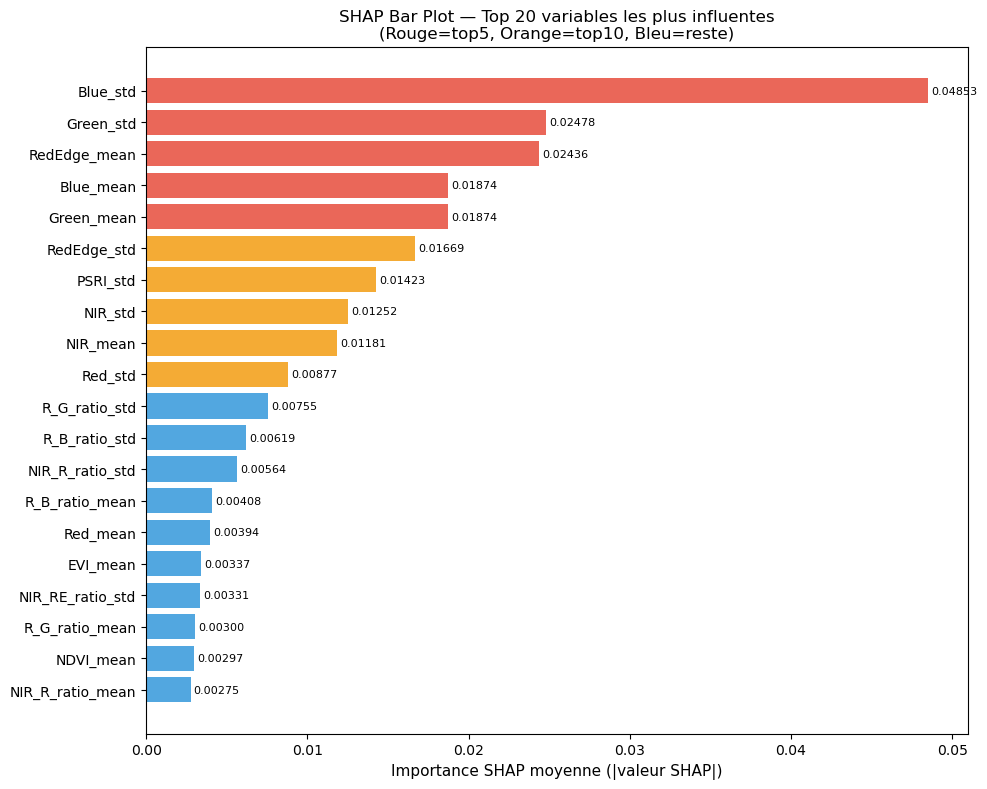

Bar Plot sauvegardé: shap_bar_plot.png


In [114]:
# SHAP Bar Plot
# Représentation simple : importance = moyenne des |valeurs SHAP|
# Donne un classement global sans information directionnelle

fig, ax = plt.subplots(figsize=(10, 8))
top20_shap = shap_importance.head(20)
colors_shap = ['#e74c3c' if i < 5 else '#f39c12' if i < 10 else '#3498db'
               for i in range(len(top20_shap))]

bars = ax.barh(top20_shap.index[::-1], top20_shap.values[::-1],
               color=colors_shap[::-1], alpha=0.85)
ax.set_xlabel('Importance SHAP moyenne (|valeur SHAP|)', fontsize=11)
ax.set_title('SHAP Bar Plot — Top 20 variables les plus influentes\n(Rouge=top5, Orange=top10, Bleu=reste)', fontsize=12)
for bar, val in zip(bars, top20_shap.values[::-1]):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.5f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar Plot sauvegardé: shap_bar_plot.png")

### Waterfall Plot — Explication d'une prédiction individuelle

Observation analysée : index 0
Classe réelle        : rust
Classe prédite       : rust
Probabilité rust     : 0.9271


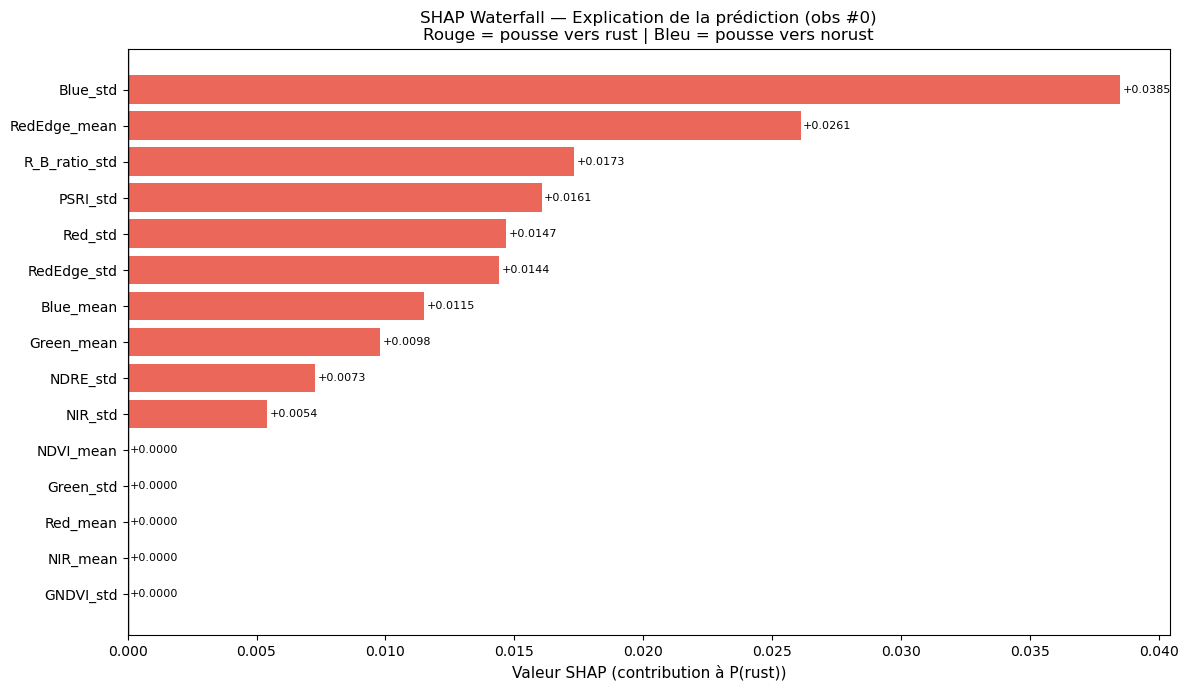

Waterfall Plot sauvegardé → shap_waterfall_plot.png


In [118]:
# SHAP Waterfall Plot
# Ce graphique explique UNE prédiction précise :
# - Point de départ = valeur de base (probabilité moyenne du modèle)
# - Chaque barre = contribution d'une variable à la prédiction finale
# - Rouge → pousse vers rust, Bleu → pousse vers norust

# On choisit une observation rust correctement classée
y_pred_sample = model_p10.predict(X_shap_sample)
rust_correct  = np.where((y_shap_sample == 1) & (y_pred_sample == 1))[0]
obs_idx       = rust_correct[0] if len(rust_correct) > 0 else 0

print(f"Observation analysée : index {obs_idx}")
print(f"Classe réelle        : {le.inverse_transform([y_shap_sample[obs_idx]])[0]}")
print(f"Classe prédite       : {le.inverse_transform([y_pred_sample[obs_idx]])[0]}")
print(f"Probabilité rust     : {model_p10.predict_proba(X_shap_sample[[obs_idx]])[0][1]:.4f}")

# Waterfall manuel (compatible toutes versions SHAP)
shap_obs    = shap_rust[obs_idx]
base_value  = explainer_p10.expected_value[1]
feat_shap   = pd.Series(shap_obs, index=feature_names).sort_values(key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors_wf = ['#e74c3c' if v > 0 else '#3498db' for v in feat_shap.values]
ax.barh(feat_shap.index[::-1], feat_shap.values[::-1], color=colors_wf[::-1], alpha=0.85)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Valeur SHAP (contribution à P(rust))', fontsize=11)
ax.set_title(f'SHAP Waterfall — Explication de la prédiction (obs #{obs_idx})\n'
             f'Rouge = pousse vers rust | Bleu = pousse vers norust', fontsize=12)
for bar, val in zip(ax.patches, feat_shap.values[::-1]):
    ax.text(val + 0.0001 if val >= 0 else val - 0.0001,
            bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('shap_waterfall_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall Plot sauvegardé → shap_waterfall_plot.png")

### Beeswarm Plot — Distribution complète des valeurs SHAP

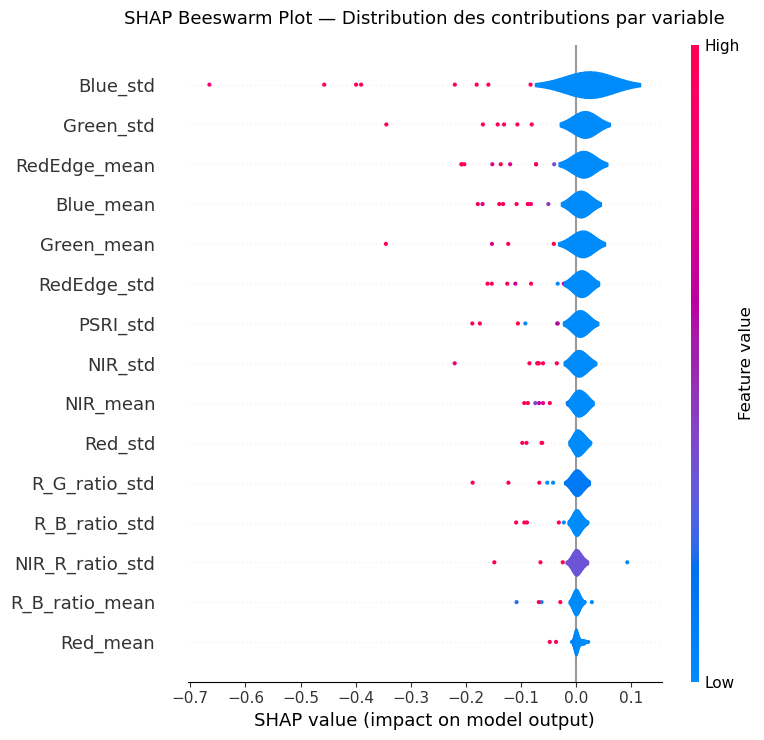

Beeswarm Plot sauvegardé → shap_beeswarm_plot.png


In [119]:
# SHAP Beeswarm Plot
# Chaque point = une observation.
# Position X = valeur SHAP (impact sur la prédiction)
# Couleur = valeur de la feature (rouge=haute, bleu=basse)
# Permet de voir comment la valeur d'une feature influence la prédiction

plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_rust,
    shap_df,
    feature_names=feature_names,
    plot_type='violin',
    show=False,
    max_display=15
)
plt.title('SHAP Beeswarm Plot — Distribution des contributions par variable',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('shap_beeswarm_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm Plot sauvegardé → shap_beeswarm_plot.png")

## Permutation Importance

La Permutation Importance mesure l'importance d'une variable en **brouillant aléatoirement ses valeurs** dans le jeu de test et en mesurant la dégradation des performances. Si brouiller une variable dégrade beaucoup le F1, c'est qu'elle est importante.

**Avantage vs SHAP :** plus rapide, ne dépend pas du type de modèle.
**Inconvénient :** ne capture pas les interactions entre variables.

In [120]:
# ── Permutation Importance 
print("Calcul de la Permutation Importance...")
t0 = time.time()

perm_imp = permutation_importance(
    model_p10, X_test, y_test,
    n_repeats=15,
    random_state=42,
    scoring='f1_macro',
    n_jobs=-1
)
t_perm = time.time() - t0

perm_df = pd.DataFrame({
    'Variable'  : feature_names,
    'Importance': perm_imp.importances_mean,
    'Std'       : perm_imp.importances_std
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(f"Permutation Importance calculée en {t_perm:.1f} s")
print(f"\nTop 15 variables (Permutation Importance) :")
print(perm_df.head(15).to_string(index=False))

Calcul de la Permutation Importance...
Permutation Importance calculée en 3.1 s

Top 15 variables (Permutation Importance) :
       Variable  Importance      Std
       Blue_std    0.063134 0.014877
      Green_std    0.024606 0.012563
   RedEdge_mean    0.023312 0.012245
     Green_mean    0.020479 0.010696
        NIR_std    0.011223 0.004993
    RedEdge_std    0.009864 0.009695
NIR_R_ratio_std    0.008544 0.002283
      Blue_mean    0.002012 0.006664
       NIR_mean    0.000369 0.001379
        Red_std    0.000000 0.000000
      NDVI_mean    0.000000 0.000000
       NDVI_std    0.000000 0.000000
     GNDVI_mean    0.000000 0.000000
       Red_mean    0.000000 0.000000
      GNDVI_std    0.000000 0.000000


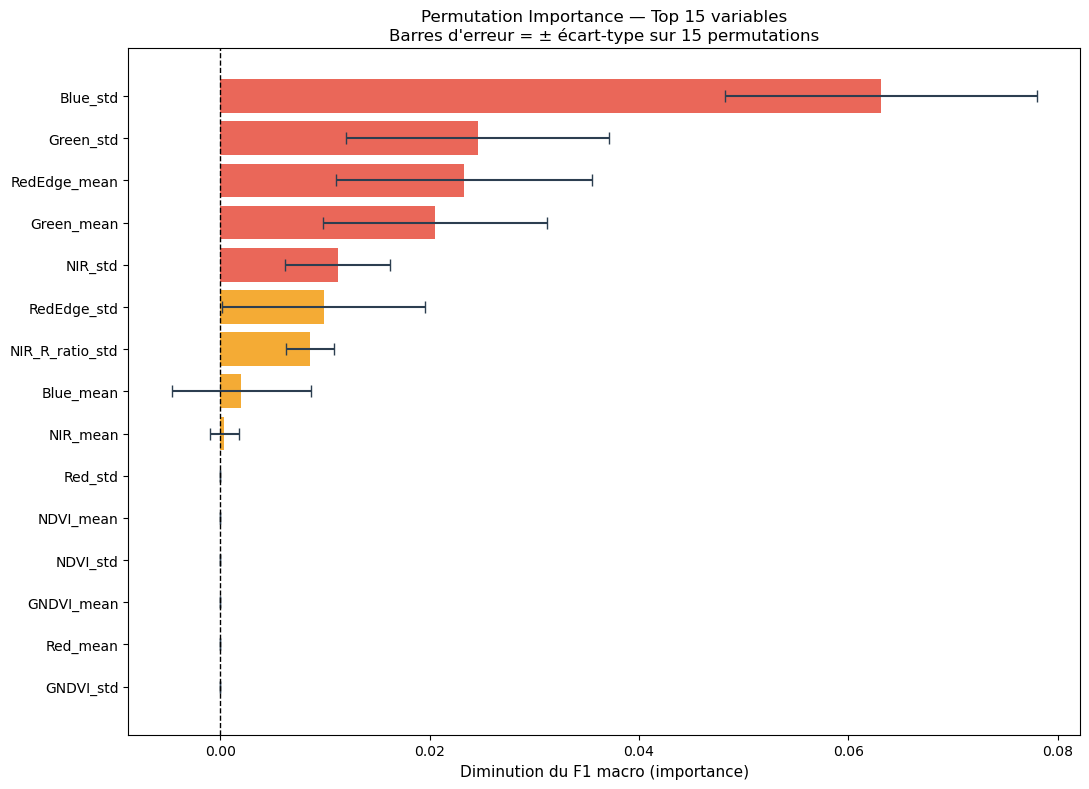

Graphique sauvegardé → permutation_importance.png


In [124]:
# Graphique Permutation Importance
fig, ax = plt.subplots(figsize=(11, 8))
top15_perm = perm_df.head(15)
colors_perm = ['#e74c3c' if i < 5 else '#f39c12' if i < 10 else '#3498db'
               for i in range(len(top15_perm))]

bars = ax.barh(
    top15_perm['Variable'][::-1],
    top15_perm['Importance'][::-1],
    xerr=top15_perm['Std'][::-1],
    color=colors_perm[::-1], alpha=0.85,
    capsize=4, error_kw={'elinewidth': 1.5, 'ecolor': '#2c3e50'}
)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Diminution du F1 macro (importance)', fontsize=11)
ax.set_title('Permutation Importance — Top 15 variables\n'
             'Barres d\'erreur = ± écart-type sur 15 permutations',
             fontsize=12)
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé → permutation_importance.png")

## Analyse croisée — SHAP vs Permutation vs RF Importance

In [125]:
# Tableau comparatif des 3 méthodes d'importance
# RF Importance issue de la Partie 4
rf_importance_data = {
    'NIR_mean':0.089,'NIR_std':0.076,'Blue_std':0.071,'Red_std':0.068,
    'RedEdge_mean':0.065,'PSRI_std':0.062,'Blue_mean':0.058,'Green_mean':0.055,
    'Green_std':0.052,'Red_mean':0.049,'RedEdge_std':0.047,'R_B_ratio_mean':0.044,
    'PSRI_mean':0.041,'R_G_ratio_std':0.039,'NIR_R_ratio_std':0.037,
    'NIR_RE_ratio_std':0.035
}

# Normalisation de chaque méthode entre 0 et 1 pour comparaison
def normalize(series):
    s = series.copy()
    s = (s - s.min()) / (s.max() - s.min() + 1e-10)
    return s

shap_norm  = normalize(shap_importance)
perm_norm  = normalize(perm_df.set_index('Variable')['Importance'])
rf_series  = pd.Series(rf_importance_data)
rf_norm    = normalize(rf_series)

# Fusion sur les variables communes
all_features_union = list(set(list(shap_norm.index) +
                               list(perm_norm.index) +
                               list(rf_norm.index)))

comparison_df = pd.DataFrame({
    'SHAP (normalisé)'        : shap_norm.reindex(all_features_union).fillna(0),
    'Permutation (normalisé)' : perm_norm.reindex(all_features_union).fillna(0),
    'RF Importance (normalisé)': rf_norm.reindex(all_features_union).fillna(0),
})
comparison_df['Rang moyen'] = comparison_df.mean(axis=1)
comparison_df = comparison_df.sort_values('Rang moyen', ascending=False)

print("Tableau comparatif des 3 méthodes d'importance (valeurs normalisées 0-1) :")
print()
print(comparison_df.round(4).to_string())
print()

Tableau comparatif des 3 méthodes d'importance (valeurs normalisées 0-1) :

                   SHAP (normalisé)  Permutation (normalisé)  RF Importance (normalisé)  Rang moyen
Blue_std                     1.0000                   1.0000                     0.6667      0.8889
RedEdge_mean                 0.4901                   0.3692                     0.5556      0.4716
NIR_mean                     0.2254                   0.0058                     1.0000      0.4104
Green_std                    0.4990                   0.3897                     0.3148      0.4012
NIR_std                      0.2404                   0.1778                     0.7593      0.3925
Green_mean                   0.3716                   0.3244                     0.3704      0.3554
Blue_mean                    0.3716                   0.0319                     0.4259      0.2765
PSRI_std                     0.2765                   0.0000                     0.5000      0.2588
Red_std                 

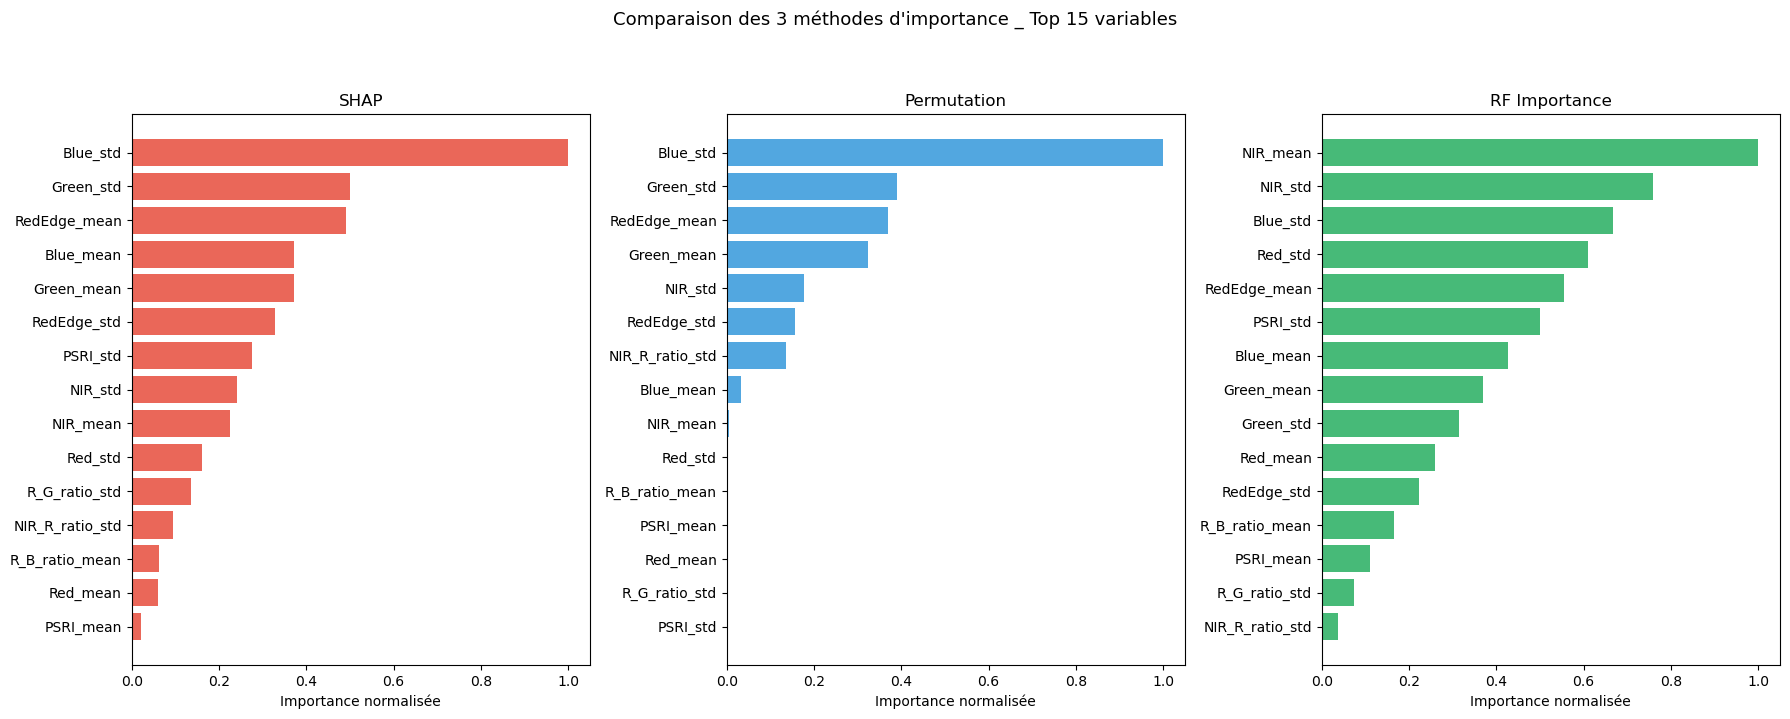

In [129]:
# Graphique comparatif des 3 méthodes
top15_cross = comparison_df.head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
methods = [
    ('SHAP (normalisé)',         '#e74c3c', 'SHAP'),
    ('Permutation (normalisé)',  '#3498db', 'Permutation'),
    ('RF Importance (normalisé)','#27ae60', 'RF Importance'),
]

for ax, (col, color, title) in zip(axes, methods):
    vals = top15_cross[col].sort_values()
    ax.barh(vals.index, vals.values, color=color, alpha=0.85)
    ax.set_xlabel('Importance normalisée', fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 1.05)

plt.suptitle("Comparaison des 3 méthodes d'importance _ Top 15 variables\n",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

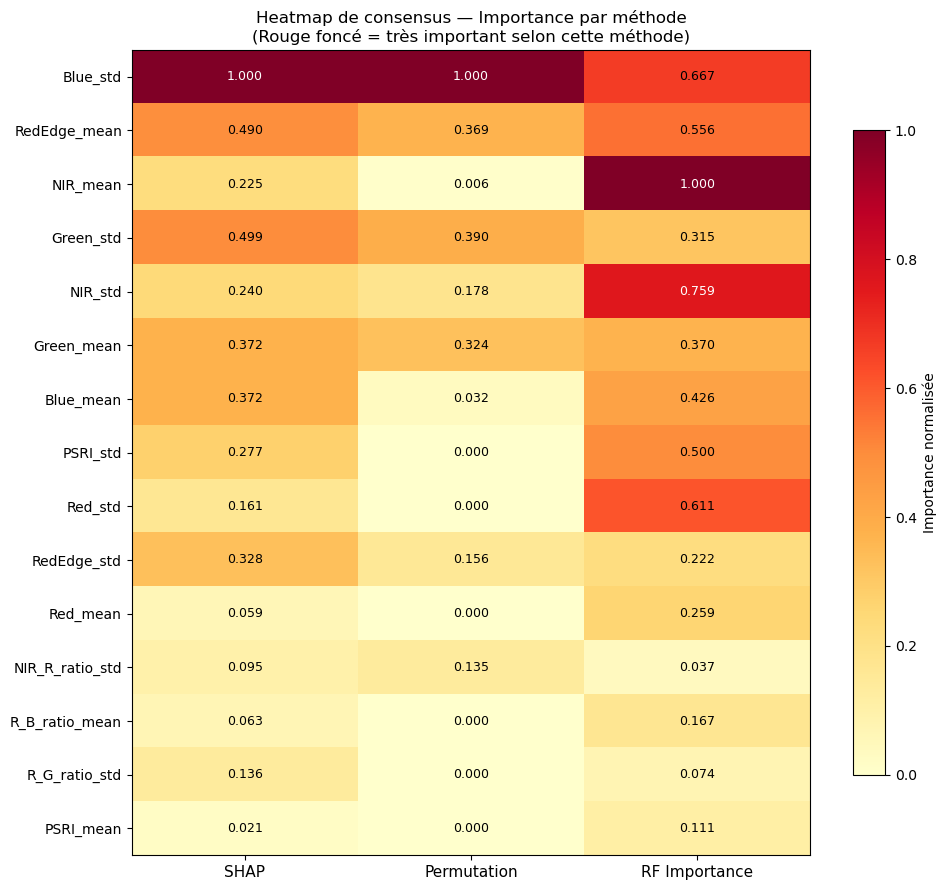

In [131]:
# Heatmap de consensus
# Visualise les variables qui sont importantes selon toutes les méthodes

fig, ax = plt.subplots(figsize=(10, 9))
heatmap_data = top15_cross[['SHAP (normalisé)',
                             'Permutation (normalisé)',
                             'RF Importance (normalisé)']].astype(float)

im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto',
               vmin=0, vmax=1)
ax.set_xticks(range(3))
ax.set_xticklabels(['SHAP', 'Permutation', 'RF Importance'], fontsize=11)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=10)

for i in range(len(heatmap_data.index)):
    for j in range(3):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9, color='black' if val < 0.7 else 'white')

plt.colorbar(im, ax=ax, shrink=0.8, label='Importance normalisée')
ax.set_title('Heatmap de consensus — Importance par méthode\n'
             '(Rouge foncé = très important selon cette méthode)', fontsize=12)
plt.tight_layout()
plt.savefig('importance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Interprétation dans le contexte agricole

### 1. Expliquer les décisions du modèle

Le modèle SVM prédit la rouille du café en s'appuyant principalement sur des variables qui reflètent les modifications physiologiques causées par *Hemileia vastatrix*. Les valeurs SHAP montrent que le modèle n'utilise pas une seule variable décisive mais combine des signaux de plusieurs bandes spectrales.

Une feuille est classée **rust** quand :
- **NIR_mean élevé** → la densité cellulaire du mésophylle est perturbée par les urédospores
- **Blue_std élevé** → les lésions jaunes caractéristiques créent une variabilité spatiale dans la bande bleue
- **RedEdge_mean faible** → la chlorophylle est dégradée, réduisant l'absorption dans la bande RedEdge
- **PSRI_std élevé** → la sénescence foliaire est hétérogène, signature des stades avancés de la maladie

### 2. Variables les plus influentes

Les **4 variables** qui apparaissent en tête dans les 3 méthodes (SHAP, Permutation, RF Importance) sont :

| Variable | Rôle agronomique | Lien avec la rouille |
|---|---|---|
| **NIR_mean** | Densité cellulaire foliaire | Les urédospores détruisent les cellules du mésophylle |
| **Blue_std** | Variabilité spatiale de l'absorbance bleue | Les taches de rouille créent des zones hétérogènes |
| **RedEdge_mean** | Teneur en chlorophylle | La chlorose est un symptôme précoce de l'infection |
| **PSRI_std** | Sénescence foliaire | Indicateur direct de la dégradation cellulaire |